# Tufa Labs ARC3 submission

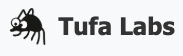

**Note**: this notebook is a more readable version of the notebook that scored our milestone-winning 1.21; unfortunately, we haven't had the same lucky result with this one. The original one is also shared here, but using it is not recommended: https://www.kaggle.com/code/jeroencottaar/taaf-duck-harness-kaggle

**Note**: if you make a copy of this notebook, you will have to manually select the proper GPU (RTX Pro 6000).

Link to writeup explaining what's going on here: https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3/discussion/717133

Link to Machine Learning Street Talk interview by Tim Scarfe about this duck harness: https://x.com/MLStreetTalk/status/2072326433922297975?s=20

This notebook executes the ARC-AGI-3 solver written by the Tufa Labs team; in alphabetical order: Harold Bessis, Jeroen Cottaar, Isaiah Pressman, Andries Smit, Michal Tesnar, and Stefano Viel.

You will only find infrastructure and diagnostics in this notebook; the actual solver code is in an attached dataset. See our writeup on the competition forum to learn more about that the solver actually does.

It installs the ARC runtime from the competition wheelhouse, makes the bundled source
snapshot importable, runs any solver setup commands, loads the pickled benchmark, plays the
competition games, and writes results to `/kaggle/working`. Diagnostics are minimised during
a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`) and kept full otherwise.

## 1. Environment and submission mode

Detect whether this is a real competition rerun (which minimises diagnostics), set the
framework's environment flags, and put the CUDA libraries on the linker path.

In [ ]:
import json
import os
import pickle
import subprocess
import sys
import sysconfig
import time
from datetime import datetime, timedelta
from pathlib import Path
from urllib.request import urlopen

# True only inside a real competition rerun; switches diagnostics + soft deadline.
TRUE_SUBMISSION = os.environ.get("KAGGLE_IS_COMPETITION_RERUN", "").strip().lower() in {"1", "true"}
NOTEBOOK_START_EPOCH = time.time()

# Non-interactive matplotlib backend: diagnostics render plots with no display attached.
os.environ["MPLBACKEND"] = "Agg"
# Marks the run as a (real or emulated) submission so the framework + solver can adjust.
os.environ["TAAF_RUN_AS_SUBMISSION"] = "1" if TRUE_SUBMISSION else "0"
# In submission, disable the periodic JSON/HTML diagnostics writes and per-frame logging.
os.environ["TAAF_MINIMAL_DIAGNOSTICS"] = "1" if TRUE_SUBMISSION else "0"
# Pin arc_agi's cached level_reset_only before its client is built (RESET keeps the level).
os.environ["ONLY_RESET_LEVELS"] = "true"

# Prepend the CUDA toolkit to the linker path (it is off it on Kaggle GPU images) so the
# solver's GPU libraries (e.g. vllm / torch) can link against libcuda.
cuda_library_path = "/usr/local/nvidia/lib64"
os.environ["LIBRARY_PATH"] = os.pathsep.join(
    entry for entry in [cuda_library_path, *os.environ.get("LIBRARY_PATH", "").split(os.pathsep)] if entry
)

# Everything the run produces is written here.
WORKING_DIR = Path("/kaggle/working")
WORKING_DIR.mkdir(parents=True, exist_ok=True)
print(f"taaf.kaggle: TRUE_SUBMISSION={TRUE_SUBMISSION}")

## 2. Install the ARC runtime

Install `arc-agi` from the offline competition wheelhouse (the Kaggle submission environment
has no internet).

In [ ]:
# Install the ARC runtime from the bundled competition wheels.
# Quiet: stdout is discarded; stderr (and a non-zero exit) still surface real failures.
subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-index",
        "--no-warn-conflicts",
        "--disable-pip-version-check",
        "--find-links",
        "/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels",
        "arc-agi",
    ],
    stdout=subprocess.DEVNULL,
)

## 3. Locate the source bundle

Find the uploaded TAAF source dataset by its marker file, and record where Kaggle mounted
every attached input so setup commands and the solver can find them.

In [ ]:
# Kaggle inputs attached to this notebook, plus bookkeeping paths used below.
DATASET_SOURCES = ["jeroencottaar/taaf-kaggle-source-share", "driessmit1/arc3-vllm-h100-wheelhouse-v3", "driessmit1/vrfai-qwen3-6-27b-fp8-hf-snapshot"]
KERNEL_SOURCES = []
DATASET_BUNDLE_MARKER = "taaf-kaggle-bundle.json"
SETUP_ENV_PATH = WORKING_DIR / "taaf_setup_env.json"


# Locate the source dataset by its marker file rather than a fixed mount path.
def _find_bundle_dir() -> Path:
    for marker in Path("/kaggle/input").rglob(DATASET_BUNDLE_MARKER):
        return marker.parent
    raise RuntimeError("TAAF source bundle not found under /kaggle/input.")


# Kaggle mounts a dataset at /kaggle/input/<slug> or /kaggle/input/datasets/<owner>/<slug>
# (depending on owner / slug collisions), so probe both and use whichever exists. Utility
# scripts mount under /kaggle/usr/lib/notebooks/<owner>/<slug>.
def _dataset_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/input") / slug, Path("/kaggle/input/datasets") / owner / slug]


def _kernel_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/usr/lib/notebooks") / owner / slug]


def _first_existing(candidates: list[Path]) -> Path | None:
    return next((c for c in candidates if c.exists()), None)


BUNDLE_DIR = _find_bundle_dir()
print(f"taaf.kaggle: source bundle = {BUNDLE_DIR}")

# Map each attached input to where Kaggle actually mounted it (the source bundle is index 0).
kaggle_input_paths: dict[str, str] = {}
for i, ref in enumerate(DATASET_SOURCES):
    candidates = _dataset_mount_candidates(ref)
    resolved = BUNDLE_DIR if i == 0 else _first_existing(candidates)
    kaggle_input_paths[ref] = str(resolved or candidates[0])
for ref in KERNEL_SOURCES:
    candidates = _kernel_mount_candidates(ref)
    kaggle_input_paths[ref] = str(_first_existing(candidates) or candidates[0])

# Published to setup commands and the solver via the environment:
setup_env = {
    # JSON {ref: mount_path} so they can locate every attached dataset / utility script.
    "TAAF_KAGGLE_INPUT_PATHS": json.dumps(kaggle_input_paths, sort_keys=True),
    # The attached dataset refs in order (index 0 is this source bundle).
    "TAAF_KAGGLE_DATASET_SOURCES": json.dumps(DATASET_SOURCES),
    # The attached utility-script / kernel refs.
    "TAAF_KAGGLE_KERNEL_SOURCES": json.dumps(KERNEL_SOURCES),
}
os.environ.update(setup_env)
SETUP_ENV_PATH.write_text(json.dumps(setup_env, indent=2, sort_keys=True) + "\n")
print(f"taaf.kaggle: input paths = {setup_env['TAAF_KAGGLE_INPUT_PATHS']}")

## 4. Import the bundled source and run solver setup

Put the snapshotted repositories on the path (this process and any child processes), then run
the solver's setup commands — installing wheels, fetching model weights, and so on.

In [ ]:
# ============================================================================
# ROUND 5 in-kernel MERGE: base + K3 RUN-8 checkpoint-8 -> /tmp/merged_sft
# (arc3-sft-k3-ckpts v2 upload; identity hard-asserted in the subprocess:
# trainer_state global_step 8 / max_steps 15 / step-8 loss + adapter bytes).
# Adapted from the PROVEN duck-sft v4 recipe (sub 55160933): the merge runs in
# an ISOLATED SUBPROCESS so the OS reclaims 100% of the GPU VRAM before vLLM
# initializes. Runs UNCONDITIONALLY: this commit kernel IS the experiment, and
# a missing merge must fail loudly (a builder is not a build).
# ============================================================================
import subprocess
_ab_merge_script = 'import glob, json, os, shutil, sys, time\n# OFFLINE env-prep (run-8 lineage): the kernel image\'s stock transformers\n# does not know model_type qwen3_5 (round-4 v4 abort: KeyError \'qwen3_5\' at\n# AutoConfig). The arc3-deps-prep kernel output bundles transformers-main\n# (5.14.0.dev0) + peft 0.19.1 with torch/nvidia/triton stripped, so the\n# image\'s Blackwell torch is kept — exactly the deps run-8 itself trained\n# with (its log: \'deps on path ... arc3-deps-prep/deps\', transformers\n# 5.14.0.dev0). Internet is off; this is the only offline route to a\n# new-enough transformers. Scoped to THIS subprocess: the notebook process\n# and vLLM (which runs from the wheelhouse\'s own site-packages) are untouched.\n_deps = sorted(p for p in glob.glob(\'/kaggle/input/**/deps\', recursive=True)\n               if \'deps-prep\' in p)\nassert _deps, \'arc3-deps-prep deps dir not found under /kaggle/input\'\nsys.path.insert(0, _deps[0])\nimport torch\nimport transformers\nprint(f\'[ab-merge-subprocess] deps on path: {_deps[0]} | \'\n      f\'transformers {transformers.__version__} | torch {torch.__version__}\', flush=True)\nassert tuple(int(x) for x in transformers.__version__.split(\'.\')[:2]) >= (5, 6), \\\n    f\'qwen3_5 needs transformers>=5.6.2, got {transformers.__version__}\'\n# --- path resolution: corpus, base model, and the RUN-8 CHECKPOINT-8 adapter --\n_corp = sorted(os.path.dirname(p)\n               for p in glob.glob(\'/kaggle/input/**/train.jsonl\', recursive=True)\n               if \'k3-corpus\' in p)\nassert len(_corp) == 1, f\'expected exactly one k3-corpus train.jsonl under /kaggle/input, got {_corp}\'\nCORPUS = _corp[0]\nMODEL = next(os.path.dirname(p) for p in glob.glob(\'/kaggle/input/**/config.json\', recursive=True)\n             if \'tokenizer_bundle\' not in p and json.load(open(p)).get(\'model_type\') == \'qwen3_5\')\n# Adapter identity chain (values recorded from the LIVE arc3-sft-k3-ckpts\n# listing + downloaded trainer_state, 2026-08-04). The dataset\'s current\n# version is the 2026-07-26 v2 upload = run 8, the FIRST VALID run (runs 1-5\n# trained on a corrupted base; no artifact of theirs exists in this version).\n# Kernels mount the LATEST dataset version, so these asserts turn any future\n# re-upload into a loud abort instead of a silent artifact swap.\n_ckpts = sorted(glob.glob(\'/kaggle/input/**/sft_out/checkpoint-8\', recursive=True))\nassert len(_ckpts) == 1, f\'expected exactly one sft_out/checkpoint-8 under /kaggle/input, got {_ckpts}\'\nCKPT = _ckpts[0]\nassert \'k3-ckpts\' in CKPT, f\'checkpoint-8 is not from the arc3-sft-k3-ckpts dataset: {CKPT}\'\n_ts = json.load(open(os.path.join(CKPT, \'trainer_state.json\')))\nassert _ts.get(\'global_step\') == 8 and _ts.get(\'max_steps\') == 15, (\n    f"not run-8 checkpoint-8: global_step={_ts.get(\'global_step\')} max_steps={_ts.get(\'max_steps\')}")\n_loss8 = next((h[\'loss\'] for h in _ts.get(\'log_history\', []) if h.get(\'step\') == 8), None)\nassert _loss8 is not None and abs(_loss8 - 0.7335078716278076) < 1e-9, (\n    f\'checkpoint-8 trainer_state does not match the verified run-8 record (step-8 loss {_loss8!r})\')\n_adapter_bytes = os.path.getsize(os.path.join(CKPT, \'adapter_model.safetensors\'))\nassert _adapter_bytes == 467062560, (\n    f\'adapter_model.safetensors is {_adapter_bytes} bytes, run-8 recorded 467062560\')\nsys.path.insert(0, CORPUS)\nfrom sft_common import dequantize_fp8_inplace, strip_quantization_runtime\nMERGED = \'/tmp/merged_sft\'\nprint(f\'[ab-merge-subprocess] base model: {MODEL} | adapter ckpt: {CKPT}\', flush=True)\n\nfrom transformers import AutoModelForImageTextToText, AutoProcessor\nfrom peft import PeftModel\nt0 = time.time()\nmodel = AutoModelForImageTextToText.from_pretrained(MODEL, torch_dtype=torch.bfloat16, device_map={\'\': 0})\nfor a in (\'quantization_config\', \'_pre_quantization_dtype\'):\n    if hasattr(model.config, a):\n        try: setattr(model.config, a, None)\n        except Exception: pass\nmodel.is_quantized = False\nif hasattr(model, \'hf_quantizer\'): model.hf_quantizer = None\ndequantize_fp8_inplace(model)\nstrip_quantization_runtime(model)\npmodel = PeftModel.from_pretrained(model, CKPT, is_trainable=False)\nmerged = pmodel.merge_and_unload()\nmerged.config.torch_dtype = torch.bfloat16\nmerged.config.use_cache = True\n# save_original_format defaults True in transformers 5.14.0.dev0 and runs\n# revert_weight_conversion(), where an op is None ->\n#   AttributeError: \'NoneType\' object has no attribute \'convert\'\n# (caught by serve-verify-k3 v6). vLLM reads HF format, so skip the revert.\nfor _a in (\'hf_quantizer\', \'_hf_peft_config_loaded\'):\n    if hasattr(merged, _a):\n        try: setattr(merged, _a, None)\n        except Exception: pass\nmerged.is_quantized = False\ntry:\n    merged.save_pretrained(MERGED, safe_serialization=True, max_shard_size=\'4GB\',\n                           save_original_format=False)\nexcept TypeError:\n    merged.save_pretrained(MERGED, safe_serialization=True, max_shard_size=\'4GB\')\ntry: proc = AutoProcessor.from_pretrained(MODEL)\nexcept Exception: proc = AutoProcessor.from_pretrained(os.path.join(CORPUS, \'tokenizer_bundle\'))\nproc.save_pretrained(MERGED)\nfor extra in (\'chat_template.jinja\', \'chat_template.json\'):\n    src = os.path.join(MODEL, extra)\n    if os.path.exists(src) and not os.path.exists(os.path.join(MERGED, extra)):\n        shutil.copy(src, MERGED)\ncfg = json.load(open(os.path.join(MERGED, \'config.json\')))\nfor k in (\'quantization_config\', \'_pre_quantization_dtype\', \'compression_config\'): cfg.pop(k, None)\njson.dump(cfg, open(os.path.join(MERGED, \'config.json\'), \'w\'), indent=2)\nprint(f\'[ab-merge-subprocess] successfully merged adapter to {MERGED} in {time.time()-t0:.0f}s\', flush=True)\n'
print('[ab-merge] running in-kernel merge (isolated subprocess)...', flush=True)
_ab_merge_res = subprocess.run([sys.executable, '-c', _ab_merge_script], capture_output=False)
print(f'[ab-merge] merge subprocess exited with code {_ab_merge_res.returncode}', flush=True)
if _ab_merge_res.returncode != 0:
    raise RuntimeError(f'[ab-merge] merge subprocess FAILED (rc={_ab_merge_res.returncode})')
_ab_need = ['config.json', 'model.safetensors.index.json']
_ab_missing = [f for f in _ab_need if not os.path.exists(os.path.join('/tmp/merged_sft', f))]
if _ab_missing:
    raise RuntimeError(f'[ab-merge] merged model incomplete, missing {_ab_missing}')
_ab_cfg = json.loads(Path('/tmp/merged_sft/config.json').read_text())
assert 'quantization_config' not in _ab_cfg, '[ab-merge] merged config still quantized'
print('[ab-merge] MERGE VERIFIED — /tmp/merged_sft complete and quantization-free', flush=True)


In [ ]:
MODEL_PATH_ANCHOR = 'MODEL_PATH = resolve_kaggle_dataset_path(MODEL_OWNER, MODEL_SLUG)'
MODEL_PATH_OVERRIDE = "MODEL_PATH = Path('/tmp/merged_sft') if Path('/tmp/merged_sft').exists() else resolve_kaggle_dataset_path(MODEL_OWNER, MODEL_SLUG)\nprint(f'[ab-merge] vLLM will serve: {MODEL_PATH}', flush=True)\nassert str(MODEL_PATH) == '/tmp/merged_sft', (\n    f'[ab-merge] REFUSING to serve {MODEL_PATH}: the merged adapter is not present, so wave 0 (arm M) would run base weights under a merged label')"
# Each bundled repo exposes its importable tree at <repo>/src or <repo>.
def _source_path_entries(bundle_dir: Path) -> list:
    entries = []
    for repo in sorted((bundle_dir / "src").iterdir(), reverse=True):
        for candidate in (repo / "src", repo):
            if candidate.is_dir():
                entries.append(candidate)
    return entries


# Environment handed to each setup command (paths + any keys it has persisted).
def _command_env() -> dict:
    env = os.environ.copy()
    # "$PYTHON" in a command resolves to this notebook's interpreter.
    env["PYTHON"] = sys.executable
    # Absolute path to the mounted source bundle.
    env["TAAF_KAGGLE_BUNDLE_DIR"] = str(BUNDLE_DIR)
    # The writable /kaggle/working directory.
    env["TAAF_KAGGLE_WORKING_DIR"] = str(WORKING_DIR)
    # A command writes a JSON object here to persist env keys to later commands + the run.
    env["TAAF_KAGGLE_SETUP_ENV"] = str(SETUP_ENV_PATH)
    env.update({str(k): str(v) for k, v in json.loads(SETUP_ENV_PATH.read_text()).items()})
    return env


# Make the bundled repos importable here (sys.path) and in child processes (.pth).
source_entries = _source_path_entries(BUNDLE_DIR)
for entry in source_entries:
    sys.path.insert(0, str(entry))
pth_path = Path(sysconfig.get_paths()["purelib"]) / "taaf_kaggle_sources.pth"
pth_path.write_text("".join(f"{entry}\n" for entry in source_entries))
print(f"taaf.kaggle: wrote {pth_path} ({len(source_entries)} source roots)")

# Solver setup commands (wheels, vLLM server startup, ...) run before the benchmark loads.
env = _command_env()
if True:  # ab-wmr: force the serve — a commit run must serve Qwen
    for command in json.loads((BUNDLE_DIR / "setup_commands.json").read_text()):
        print(f"taaf.kaggle: setup command: {command}", flush=True)
        if MODEL_PATH_ANCHOR not in command:
            raise RuntimeError('[ab-merge] MODEL_PATH anchor missing from setup command — upstream moved; refusing to serve an unswapped model')
        cmd_mod = command.replace(MODEL_PATH_ANCHOR, MODEL_PATH_OVERRIDE)
        subprocess.run(cmd_mod, shell=True, check=True, cwd=WORKING_DIR, env=env)
        env = _command_env()
        os.environ.update(env)
else:
    print("[duck] commit: skipping setup_commands (no GPU serve)", flush=True)

# Honour any PYTHONPATH a setup command exported.
for entry in reversed([e for e in os.environ.get("PYTHONPATH", "").split(os.pathsep) if e]):
    if entry not in sys.path:
        sys.path.insert(0, entry)

## 5. Load the benchmark

Unpickle the deployment target and the benchmark, stamping the real submission state onto the
target and pointing the benchmark's outputs at the Kaggle working directory.

In [ ]:
# Restore the deployment target and record the real submission state on it.
with open(BUNDLE_DIR / "deploy_target.pkl", "rb") as file:
    target = pickle.load(file)
target.actual_run_as_submission = TRUE_SUBMISSION
target.is_competition_rerun = TRUE_SUBMISSION

# Restore the benchmark and point its outputs at the Kaggle working dir.
with open(BUNDLE_DIR / "benchmark_initial.pkl", "rb") as file:
    bm = pickle.load(file)
bm.job_dir = WORKING_DIR

## 6. Customization hook

Optional: tweak `bm`, `bm.games`, or `bm.solver` here before the run starts — the safe place
for one-off experiments once the deployed bundle has loaded.

In [ ]:
# ============================================================================
# A/B patch layer. Inlined from submission/_duck_patched/duck_patches.py and
# submission/_rig/behav_probe.py by build_ab_wmr.py — edit those and rebuild.
# ============================================================================
"""In-memory patches applied to the read-only TAAF duck bundle before `bm.run()`.

The Kaggle dataset that carries the duck harness is read-only, so every fix here is a
monkey-patch installed at import time in the notebook. Each patch is independently
guarded: if the upstream shape it expects is missing, that patch reports FAIL and the
others still apply. Nothing here changes the model, sampling, concurrency or budgets.

PATCH 1 — ACTION7 round trip (BUG FIX).
    `inference.agent.action_names.ENGINE_TO_MODEL_ACTION` maps ACTION1..6 + RESET only.
    `to_model_action("ACTION7")` passes the name through to the model, but
    `to_engine_action("ACTION7")` returns None, so solver.py's action parser rejects it
    with "Unknown action at index N". The model is offered a legal action it can never
    execute. 6 of the 25 public games use ACTION7 (ar25, bp35, lf52, sb26, sk48, su15).

PATCH 2 — animation metadata.
    `taaf.game.GameState.animation_frames` already exposes the intermediate frames of a
    multi-frame action, but only the final frame ever reaches the model. This adds a few
    scalar fields per action describing what moved during the animation. No images, no
    raw frames — roughly 20-40 tokens per action of causal signal.

NOT PATCHED — RESET restriction.
    The public fork this work draws on restricts RESET to GAME_OVER. Our bundle already
    does the equivalent, more thoroughly: `solver._engine_action_names` strips RESET from
    the model's choices unconditionally (solver.py:116-117) and `_execute_auto_reset()`
    fires on GAME_OVER (solver.py:278-282). No change needed; verified by
    `verify_reset_already_handled()` below.
"""
from __future__ import annotations

from typing import Any

# Engine action ids that count as real actions (RESET is id 0 and is scored differently).
_ACTION7 = "ACTION7"


def _forward_patch_markers(wrapper: Any, original: Any) -> None:
    """Copy every ``*_patched`` marker from a wrapped callable onto its wrapper.

    The patches stack (7 -> 8 -> 10 -> 11 all wrap the same methods); each one's
    idempotency check and the A/B kernel's patch proof read the markers off the
    OUTERMOST callable, so a wrapper that hides its predecessors' markers makes
    a second ``apply_all()`` re-wrap them (double bookkeeping).
    """
    for attr, value in vars(original).items():
        if attr.endswith("_patched") and value:
            setattr(wrapper, attr, value)


def patch_action7() -> str:
    """Make ACTION7 survive the model<->engine name round trip. Returns a status line."""
    from inference.agent import action_names as an

    if _ACTION7 in an.ENGINE_TO_MODEL_ACTION:
        return "patch1 action7: SKIP (already mapped)"

    # ACTION7's meaning is not fixed across games, so it has no friendly label like
    # UP/DOWN/MOUSE. Map it to itself: the model sees "ACTION7" and the engine gets
    # "ACTION7" back.
    an.ENGINE_TO_MODEL_ACTION[_ACTION7] = _ACTION7
    an.MODEL_TO_ENGINE_ACTION.clear()
    an.MODEL_TO_ENGINE_ACTION.update(
        {value: key for key, value in an.ENGINE_TO_MODEL_ACTION.items()}
    )

    if an.to_engine_action(an.to_model_action(_ACTION7)) != _ACTION7:
        raise RuntimeError("patch1 action7: round trip still broken after patch")
    return "patch1 action7: OK"


def patch_animation_producer() -> str:
    """Attach the animation summary to the payload `_execute_action` returns.

    `_compact_action_result` (patch 2b) only forwards these keys; this is what creates
    them. Wrapping the method rather than reimplementing it keeps us insulated from
    upstream changes to the payload's other fields.
    """
    from inference.framework import solver

    session = getattr(solver, "_HarnessGameSession", None)
    if session is None or not hasattr(session, "_execute_action"):
        return "patch2a animation-producer: FAIL (_HarnessGameSession._execute_action not found)"
    if getattr(session._execute_action, "_animation_patched", False):
        return "patch2a animation-producer: SKIP (already applied)"

    original = session._execute_action

    def _execute_action(self: Any, *args: Any, **kwargs: Any) -> dict[str, Any]:
        payload = original(self, *args, **kwargs)
        if isinstance(payload, dict):
            try:
                payload.update(summarize_animation(self.game.current_state))
            except Exception:
                pass  # never let telemetry break an action
        return payload

    _execute_action._animation_patched = True  # type: ignore[attr-defined]
    session._execute_action = _execute_action
    return "patch2a animation-producer: OK"


def patch_animation_metadata() -> str:
    """Forward the animation summary through the compaction the model actually sees."""
    from inference.agent import tool_agent

    agent_cls = getattr(tool_agent, "ToolAgent", None)
    if agent_cls is None or not hasattr(agent_cls, "_compact_action_result"):
        return "patch2b animation-forward: FAIL (ToolAgent._compact_action_result not found)"
    if getattr(agent_cls._compact_action_result, "_animation_patched", False):
        return "patch2b animation-forward: SKIP (already applied)"

    original = agent_cls._compact_action_result

    def _compact_action_result(self: Any, payload: dict[str, Any]) -> dict[str, Any]:
        compact = original(self, payload)
        for key in _ANIMATION_KEYS:
            if key in payload:
                compact[key] = payload[key]
        return compact

    _compact_action_result._animation_patched = True  # type: ignore[attr-defined]
    agent_cls._compact_action_result = _compact_action_result
    return "patch2b animation-forward: OK"


_ANIMATION_KEYS = (
    "animation_frame_count",
    "animation_changed",
    "animation_only_changed",
    "animation_changed_cell_count",
    "animation_changed_bbox",
)


def summarize_animation(state: Any) -> dict[str, Any]:
    """Describe the animation of a just-executed action as a handful of scalars.

    `state` is a taaf GameState. Returns {} when the action produced no animation, so
    single-frame actions cost zero extra tokens.
    """
    try:
        animation = list(state.animation_frames)
    except Exception:
        return {}
    if not animation:
        return {}

    final = _frame_rows(state.frame)
    changed_cells: list[tuple[int, int]] = []
    only_in_animation = False
    # HUD cells (patch 8) tick during animations too; they are not motion signal.
    hud_cells = {(int(y), int(x)) for y, x in _hud_current_mask_cells()}

    for frame in animation:
        rows = _frame_rows(frame)
        for y, (arow, frow) in enumerate(zip(rows, final)):
            for x, (avalue, fvalue) in enumerate(zip(arow, frow)):
                if avalue != fvalue and (y, x) not in hud_cells:
                    changed_cells.append((x, y))
                    only_in_animation = True

    out: dict[str, Any] = {
        "animation_frame_count": len(animation),
        "animation_changed": bool(changed_cells),
        # True when the animation showed motion that is NOT visible in the final frame —
        # i.e. something moved and returned, or moved through. This is the signal the
        # model cannot otherwise recover.
        "animation_only_changed": only_in_animation,
        "animation_changed_cell_count": len(set(changed_cells)),
    }
    if changed_cells:
        xs = [x for x, _ in changed_cells]
        ys = [y for _, y in changed_cells]
        out["animation_changed_bbox"] = [min(xs), min(ys), max(xs), max(ys)]
    return out


def _frame_rows(frame: Any) -> list[list[int]]:
    data = getattr(frame, "data", frame)
    return [list(row) for row in data]


def verify_reset_already_handled() -> str:
    """Confirm our bundle already restricts RESET, so patch 3 is genuinely unnecessary."""
    import inspect

    from inference.framework import solver

    src = inspect.getsource(solver._engine_action_names)
    strips_reset = 'if name == "RESET"' in src and "continue" in src
    auto_resets = hasattr(solver._HarnessGameSession, "_execute_auto_reset")
    if strips_reset and auto_resets:
        return "patch3 reset: NOT NEEDED (RESET stripped from choices + auto-reset on GAME_OVER)"
    return (
        f"patch3 reset: REVIEW (strips_reset={strips_reset}, auto_resets={auto_resets}) "
        "— upstream changed, re-check whether RESET must be restricted"
    )


def _grid_burner_enabled() -> bool:
    """Opt-in only (TAAF_GRID_BURNER=1). Default OFF.

    The 2026-08-03 zero-submission diagnosis found the burner draws ~11px default-font
    labels and per-cell grid lines onto the images at the SCORED config's
    MULTIMODAL_UPSCALE=4 (4px cells) — substantial frame defacement. It was only ever
    validated at dev upscale 16 and has never been part of a scored config, so it must
    be explicitly opted into, never on by default.
    """
    import os

    return os.environ.get("TAAF_GRID_BURNER", "0").strip() in {"1", "true", "True"}


def patch_dynamic_grid_burner() -> str:
    """Burn coordinate grids into the images sent to the VLM (Spatial Overlay).

    Call-time gated on TAAF_GRID_BURNER (default OFF): the wrapper is always
    installed but delegates to the stock renderer unless explicitly enabled,
    matching the other patches' env-switch style.
    """
    from inference.agent import vision_context

    if getattr(vision_context.frame_to_png_data_url, "_grid_burner_patched", False):
        return "patch4 grid-burner: SKIP (already applied)"

    original_func = vision_context.frame_to_png_data_url

    def frame_to_png_data_url_patched(frame: Any, *, upscale: int | None = None) -> str:
        if not _grid_burner_enabled():
            return original_func(frame, upscale=upscale)
        import io, base64
        from PIL import Image, ImageDraw

        rows = len(frame.grid)
        cols = max((len(row) for row in frame.grid), default=0)
        if rows <= 0 or cols <= 0:
            raise ValueError("Cannot render an empty grid as an image.")

        scale = vision_context.current_grid_image_upscale() if upscale is None else max(1, int(upscale))
        image = Image.new("RGB", (cols, rows), vision_context.ARC_COLOR_MAP[0])
        pixels = image.load()
        for row_idx, row in enumerate(frame.grid):
            for col_idx in range(cols):
                value = row[col_idx] if col_idx < len(row) else 0
                pixels[col_idx, row_idx] = vision_context.ARC_COLOR_MAP.get(int(value), vision_context.ARC_COLOR_MAP[0])
        
        if scale > 1:
            image = image.resize((cols * scale, rows * scale), Image.Resampling.NEAREST)
            draw = ImageDraw.Draw(image)
            
            # Draw subtle grid lines
            grid_color = (128, 128, 128)
            for r in range(rows + 1):
                y = r * scale
                width = 2 if r % 5 == 0 else 1
                draw.line([(0, y), (cols * scale, y)], fill=grid_color, width=width)
            for c in range(cols + 1):
                x = c * scale
                width = 2 if c % 5 == 0 else 1
                draw.line([(x, 0), (x, rows * scale)], fill=grid_color, width=width)

            # Draw coordinate labels
            try:
                from PIL import ImageFont
                font = ImageFont.load_default()
                text_color = (200, 200, 200)
                # row labels (left edge)
                for r in range(rows):
                    if r % 5 == 0:
                        draw.text((2, r * scale + 2), str(r), fill=text_color, font=font)
                # col labels (top edge)
                for c in range(cols):
                    if c % 5 == 0 and c > 0:
                        draw.text((c * scale + 2, 2), str(c), fill=text_color, font=font)
            except Exception:
                pass

        buffer = io.BytesIO()
        image.save(buffer, format="PNG")
        encoded = base64.b64encode(buffer.getvalue()).decode("ascii")
        return f"data:image/png;base64,{encoded}"

    _forward_patch_markers(frame_to_png_data_url_patched, original_func)
    frame_to_png_data_url_patched._grid_burner_patched = True  # type: ignore[attr-defined]
    vision_context.frame_to_png_data_url = frame_to_png_data_url_patched
    if _grid_burner_enabled():
        return "patch4 grid-burner: OK (TAAF_GRID_BURNER=1)"
    return "patch4 grid-burner: OK (dormant — opt in with TAAF_GRID_BURNER=1)"


def patch_prompts() -> str:
    """Update system prompt to instruct the model to use the grid coordinates."""
    from inference.agent import prompts
    if "numeric coordinate labels" in prompts.MULTIMODAL_CONTEXT_ADDENDUM:
        return "patch5 prompts: SKIP (already applied)"
    prompts.MULTIMODAL_CONTEXT_ADDENDUM += "- The image contains numeric coordinate labels (0, 5, 10...) along the top and left edges. Use these to precisely identify row and column indices for spatial reasoning and action targeting.\n"
    return "patch5 prompts: OK"


def patch_tool_agent_analyze() -> str:
    """Intercept the Qwen-27B action generation pipeline to inject TransferExplorer and Retrospective summaries."""
    import importlib.util
    import sys
    from pathlib import Path

    # Ensure arcagi3 is in sys.path. NO bare __file__ here: this module is exec'd
    # straight into a notebook cell on Kaggle, where __file__ is undefined — the old
    # `Path(__file__)` fallback raised NameError while building the path list and
    # aborted the whole patch as FAIL before it had mutated anything.
    possible_paths = [
        Path("/kaggle/input/arcagi3-agent/lib"),
        Path("/kaggle/input/datasets/ahmedmobasher86/arcagi3-agent/lib"),
    ]
    module_file = globals().get("__file__")
    if module_file:  # imported as a real file (tests / dev): repo-root src fallback
        possible_paths.append(Path(module_file).resolve().parents[2] / "src")
    for p in possible_paths:
        if p.exists() and str(p) not in sys.path:
            sys.path.insert(0, str(p))

    # Presence-gate the resource instead of failing later per call: without the
    # arcagi3 package the TransferExplorer probe can never fire, so decline cleanly.
    try:
        arcagi3_present = importlib.util.find_spec("arcagi3.transfer_explorer") is not None
    except (ImportError, ModuleNotFoundError, ValueError):
        arcagi3_present = False
    if not arcagi3_present:
        return (
            "patch6 tool_agent_analyze: SKIP (arcagi3.transfer_explorer not importable — "
            f"searched {[str(p) for p in possible_paths]})"
        )

    from inference.agent import tool_agent
    agent_cls = getattr(tool_agent, "ToolAgent", None)
    if agent_cls is None or not hasattr(agent_cls, "analyze"):
        return "patch6 tool_agent_analyze: FAIL (ToolAgent.analyze not found)"
    if getattr(agent_cls.analyze, "_tool_agent_patched", False):
        return "patch6 tool_agent_analyze: SKIP (already applied)"

    original_analyze = agent_cls.analyze

    def analyze_patched(
        self,
        state_path: Path,
        action_num: int,
        valid_actions: list[str] | None = None,
        step_env = None,
        *args,
        **kwargs
    ):
        from inference.agent.runtime_state import load_runtime_state
        from inference.agent.tool_agent import AnalyzerTurnResult
        import arcengine
        
        # Phase 3: Inject Retrospective Summaries into system prompt
        original_system_prompt = getattr(self, "_original_system_prompt", None)
        if original_system_prompt is None:
            self._original_system_prompt = self._system_prompt
            original_system_prompt = self._system_prompt
            
        retrospectives = getattr(self, "_retrospective_summaries", [])
        if retrospectives:
            retro_text = "\n\nRetrospective Summaries from previous levels of this game:\n" + "\n".join(f"- {r}" for r in retrospectives)
            self._system_prompt = original_system_prompt + retro_text
        else:
            self._system_prompt = original_system_prompt

        # Phase 2: Heuristic Prober (TransferExplorer)
        if action_num < 200 and step_env is not None:
            try:
                from arcagi3.transfer_explorer import TransferExplorer
                if not hasattr(self, "_transfer_explorer_instance"):
                    self._transfer_explorer_instance = TransferExplorer()
                
                current_frame, _ = load_runtime_state(state_path)
                grid = current_frame.grid
                
                gstate_terminal = False
                gstate_notplayed = (action_num == 0)
                levels = current_frame.level
                
                # Format available actions as integers for TransferExplorer
                available_ids = []
                for name in (valid_actions or []):
                    try:
                        available_ids.append(arcengine.GameAction.from_name(name).value)
                    except Exception:
                        pass
                
                # numpy is required by arcagi3
                import numpy as np
                grid_np = np.array(grid, dtype=np.int32)
                
                action = self._transfer_explorer_instance.decide(
                    grid_np, gstate_terminal, gstate_notplayed, levels, available_ids
                )
                
                step_args = None
                if action and action[0] == "S":
                    action_name = arcengine.GameAction.from_id(action[1]).name
                    step_args = {"action": action_name}
                elif action and action[0] == "C":
                    step_args = {"action": "ACTION6", "col": action[1], "row": action[2]}
                elif action and action[0] == "reset":
                    step_args = {"action": "RESET"}
                    
                if step_args is not None:
                    # execute the symbolic transition
                    result = step_env(step_args)
                    # Note: we should still check if this action completed the level!
                    if self._last_action_result and self._last_action_result.get("level_completed"):
                        # Mark that we should do retrospective, but wait, the prober doesn't use the LLM, 
                        # so there are no LLM history messages for this level! We can just skip retro for heuristic clears.
                        pass
                    return AnalyzerTurnResult(
                        step_executed=True,
                        reasoning=f"TransferExplorer heuristic probe executed: {step_args}",
                        yielded_control=False,
                    )
            except Exception as exc:
                import logging
                logging.getLogger(__name__).warning("TransferExplorer failed, falling back to LLM: %s", exc)
                pass
                
        # Fallback to normal Qwen LLM analysis
        result = original_analyze(self, state_path, action_num, valid_actions, step_env, *args, **kwargs)
        
        # Phase 3: Retrospective generation on level complete
        if hasattr(self, "_last_action_result") and self._last_action_result and self._last_action_result.get("level_completed"):
            try:
                retro_messages = list(self._history_messages)
                retro_messages.append({
                    "role": "user", 
                    "content": "The level was just solved! Briefly summarize the core mechanic of this level and the strategy used to solve it. This summary will be provided to you in future levels of this game, so focus on transferable rules (e.g. 'green objects always move right until they hit a wall'). Keep it under 4 sentences."
                })
                # Call chat completion
                retro_result = self._chat_completion(retro_messages, tools=None)
                retro_content = retro_result.message.get("content", "")
                if retro_content:
                    if not hasattr(self, "_retrospective_summaries"):
                        self._retrospective_summaries = []
                    self._retrospective_summaries.append(retro_content)
            except Exception as exc:
                import logging
                logging.getLogger(__name__).warning("Retrospective generation failed: %s", exc)
                pass
                
        return result

    analyze_patched._tool_agent_patched = True  # type: ignore[attr-defined]
    agent_cls.analyze = analyze_patched
    return "patch6 tool_agent_analyze: OK"


# --- PATCH 8: HUD wavefront mask -------------------------------------------------
#
# 18-24 of the 25 public games paint a step-budget bar into the frame and tick it
# on (nearly) every action, so raw full-frame equality — which is exactly what the
# harness uses for `board_changed` (solver.py:703) and what the model's sandbox
# helpers `state_hash` / `diff_frames` hash — reports a board change for provable
# no-ops. Measured corpus no-op rate: 0.208 raw vs 0.455 masked; `board_changed`
# is wrong on 13/25 games (100% wrong on 6).
#
# The detector is the validated wavefront statistic (docs/test-artifacts-2026-08-02/
# RESULTS-determinism-hudmask.md, 24/25 games, 0 false-mask cells): a HUD bar is a
# collinear run of >=4 cells that each change EXACTLY ONCE, in monotone spatial
# order of change time (>=3 distinct times), all with the same color transition.
# The statistic only holds within RESET-free stretches (a RESET refills the bar),
# so the tracker accumulates per-segment change statistics and breaks the segment
# on RESET, on level transitions, and on GAME_OVER/WIN screens (all of which
# repaint or refill). Strips found in any segment are unioned into the game mask.
#
# VIRTUAL SEGMENT ROTATION (m0r0 lesson, 2026-08-03): cross-segment confirmation
# used to accrue segments ONLY at those natural boundaries, so a long boundary-free
# run could never reach MIN_SEGMENTS — m0r0's rows 0+63 budget bars (ticking every
# ~2-3 actions) were sighted but never confirmed across a 240-event episode with a
# single death. The tracker now also rotates to a fresh virtual segment after
# SEGMENT_ROTATE_STEPS accumulated steps (default 24, TAAF_HUD_ROTATE overrides,
# 0 disables), long enough that a slow-tick bar still yields >= MIN_LEN once-changed
# cells per window, so reset-free runs confirm within ~3 windows.
#
# UNMASK GUARD (protects the full-edge-strip games sp80/vc33/r11l/s5i5/tu93): if
# any masked cell changes twice within one segment, real content has entered the
# strip — the whole region is dropped from the mask permanently for that game.
#
# Consumers patched:
#   - `board_changed` in `_HarnessGameSession._execute_action` (and thereby every
#     downstream copy: step_env batch aggregation, `_compact_action_result`,
#     outcome summaries, viewer events);
#   - `summarize_animation` (patch 2) ignores masked cells;
#   - the python-tool sandbox's `state_hash` and `diff_frames` (patch 9), which
#     receive the live mask through the runtime-state payload.
#
# TAAF_HUD_MASK=0 disables masking at call time (the tracker still observes).


class HudMaskTracker:
    """Incremental wavefront/HUD-strip detector over reset-free segments.

    Per-segment statistics (change count, first-change time, first transition)
    are updated per frame in O(cells); strips are re-detected from the statistics
    (never from stored frames), so memory stays O(1) in episode length.

    Two precision rules beyond the validated wavefront statistic — needed because
    real play traces (unlike the scripted no-op probes) contain monotone content
    fills that satisfy the statistic per-line (measured on stored vc33 episodes:
    a painted block reads as a stack of parallel "strips"):

      * CROSS-SEGMENT CONFIRMATION — a line is masked only after it produced a
        wavefront strip (same orientation, line and color transition, overlapping
        span) in >= MIN_SEGMENTS distinct reset-free segments. A budget bar ticks
        in every segment; a content fill rarely repeats on the same line with the
        same transition. MIN_SEGMENTS=3 measured 0 masked cells outside the
        validated HUD regions across all 43 stored episodes (vs 77 at 2), while
        keeping 119 HUD-only no-op detections.
      * STACK RULE — >= MAX_STACK adjacent parallel confirmed lines with
        overlapping spans are a 2D block, not a bar, and are all rejected
        (2 adjacent lines stay allowed: the ls20 bar is two rows tall).

    Segment supply (the m0r0 lesson): natural boundaries (RESET / level change /
    GAME_OVER / WIN) are too rare in some real runs to ever reach MIN_SEGMENTS —
    a slow-tick bar in a boundary-free run was sighted forever but never
    confirmed. SEGMENT_ROTATE_STEPS therefore banks the live window and starts a
    fresh virtual segment every N accumulated steps; a budget bar re-satisfies
    the wavefront statistic in every window, while one-shot content fills do not.
    24 steps holds >= MIN_LEN once-changed cells for bars ticking as slowly as
    every ~5-6 actions (a 64-cell bar over a <= ~380-action budget).
    """

    MIN_LEN = 4
    MIN_DISTINCT_TIMES = 3
    MIN_SEGMENT_STEPS = 10
    MIN_SEGMENTS = 3
    MAX_STACK = 2
    SEGMENT_ROTATE_STEPS = 24  # 0 disables virtual rotation (pre-fix behavior)

    def __init__(self, min_segments: int | None = None) -> None:
        import numpy as np
        import os

        self._np = np
        self._prev = None
        self._levels: int | None = None
        self._steps = 0
        self._segment_id = 0
        # (orient, line, from_color, to_color) -> {segment_id: (span_start, span_end)}
        self._sightings: dict[tuple, dict[int, tuple[int, int]]] = {}
        self._dead_lines: set[tuple] = set()  # unmask-guard casualties, permanent
        self._tainted_lines: set[tuple] = set()  # (orient, line) seen in a 2D stack
        self._mask = None  # bool array, True = HUD cell
        self._dropped = None  # bool array, True = never mask again (guard fired)
        self._nchg = None
        self._tchg = None
        self._tfrom = None
        self._tto = None
        if min_segments is not None:
            self.MIN_SEGMENTS = int(min_segments)
        try:
            rotate = int(os.environ.get("TAAF_HUD_ROTATE", "").strip() or self.SEGMENT_ROTATE_STEPS)
        except ValueError:
            rotate = self.SEGMENT_ROTATE_STEPS
        # A rotation window shorter than the detection minimum could never bank
        # a strip; clamp instead of silently detecting nothing.
        self.SEGMENT_ROTATE_STEPS = 0 if rotate <= 0 else max(rotate, self.MIN_SEGMENT_STEPS)

    # -- lifecycle -----------------------------------------------------------

    def seed(self, grid: Any) -> None:
        """Record the pre-action board so the first transition is counted."""
        if self._prev is None:
            g = self._np.asarray(grid, dtype=self._np.int16)
            self._init_arrays(g.shape)
            self._prev = g

    def _init_arrays(self, shape: tuple[int, int]) -> None:
        np = self._np
        self._mask = np.zeros(shape, dtype=bool)
        self._dropped = np.zeros(shape, dtype=bool)
        self._reset_segment_stats(shape)

    def _reset_segment_stats(self, shape: tuple[int, int] | None = None) -> None:
        np = self._np
        if shape is None:
            shape = self._nchg.shape
        self._nchg = np.zeros(shape, dtype=np.int32)
        self._tchg = np.full(shape, -1, dtype=np.int32)
        self._tfrom = np.full(shape, -1, dtype=np.int16)
        self._tto = np.full(shape, -1, dtype=np.int16)
        self._steps = 0

    # -- main entry ----------------------------------------------------------

    def observe(
        self,
        grid: Any,
        *,
        is_reset: bool = False,
        levels_completed: int | None = None,
        state_name: str | None = None,
    ) -> dict[str, bool]:
        """Feed the post-action board; returns raw/masked change verdicts."""
        np = self._np
        g = np.asarray(grid, dtype=np.int16)
        if self._prev is None or g.shape != self._prev.shape:
            self._init_arrays(g.shape)
            self._prev = g
            if levels_completed is not None:
                self._levels = int(levels_completed)
            return {"raw_changed": False, "masked_changed": False}

        diff = self._prev != g
        raw_changed = bool(diff.any())
        masked_changed = bool((diff & ~self._mask).any())

        boundary = bool(is_reset)
        if levels_completed is not None:
            if self._levels is not None and int(levels_completed) != self._levels:
                boundary = True
            self._levels = int(levels_completed)
        if state_name in ("GAME_OVER", "WIN"):
            boundary = True

        if boundary:
            # The bar refills / the scene repaints: this transition must not
            # enter the statistic. Bank what the closing segment proved first.
            self._record_sightings()
            self._segment_id += 1
            self._reset_segment_stats()
            self._refresh_mask()
        else:
            if raw_changed:
                newly = diff & (self._nchg == 0)
                self._tchg[newly] = self._steps
                self._tfrom[newly] = self._prev[newly]
                self._tto[newly] = g[newly]
                self._nchg[diff] += 1
                repeat = (self._nchg >= 2) & self._mask
                if repeat.any():
                    self._drop_regions(repeat)
            self._steps += 1
            if self._steps >= self.MIN_SEGMENT_STEPS:
                self._record_sightings()
                self._refresh_mask()
            if self.SEGMENT_ROTATE_STEPS and self._steps >= self.SEGMENT_ROTATE_STEPS:
                # Virtual segment boundary: the window above was just banked into
                # `_sightings` under the current id; open a fresh window so long
                # boundary-free runs still accrue MIN_SEGMENTS independent
                # confirmations (m0r0-class slow-tick bars).
                self._segment_id += 1
                self._reset_segment_stats()

        self._prev = g
        return {"raw_changed": raw_changed, "masked_changed": masked_changed}

    # -- detection -----------------------------------------------------------

    def _detect_segment_strips(self) -> dict[tuple, tuple]:
        if self._steps < self.MIN_SEGMENT_STEPS:
            return {}
        np = self._np
        once = self._nchg == 1
        height, width = once.shape
        strips: dict[tuple, tuple] = {}

        def consider(run: list[tuple[int, int]], orient: str) -> None:
            if len(run) < self.MIN_LEN:
                return
            times = [int(self._tchg[y, x]) for y, x in run]
            deltas = np.diff(times)
            if not (bool((deltas >= 0).all()) or bool((deltas <= 0).all())):
                return
            if len(set(times)) < self.MIN_DISTINCT_TIMES:
                return
            transitions = {(int(self._tfrom[y, x]), int(self._tto[y, x])) for y, x in run}
            if len(transitions) != 1:
                return
            (from_color, to_color) = next(iter(transitions))
            if orient == "H":
                key = ("H", run[0][0], from_color, to_color, run[0][1], run[-1][1])
            else:
                key = ("V", run[0][1], from_color, to_color, run[0][0], run[-1][0])
            strips[key] = tuple(run)

        for y in range(height):
            run: list[tuple[int, int]] = []
            for x in range(width + 1):
                if x < width and once[y, x]:
                    run.append((y, x))
                else:
                    consider(run, "H")
                    run = []
        for x in range(width):
            run = []
            for y in range(height + 1):
                if y < height and once[y, x]:
                    run.append((y, x))
                else:
                    consider(run, "V")
                    run = []
        return strips

    def _record_sightings(self) -> None:
        """Fold the live segment's strips into the cross-segment evidence.

        Lines that show up as part of a stack of > MAX_STACK adjacent parallel
        strips within a SINGLE segment are tainted permanently: that shape is a
        2D content fill (e.g. vc33's paint blocks read as 8+ parallel "strips"),
        and per-line cross-segment confirmation cannot be trusted for it.
        """
        strips = self._detect_segment_strips()
        for orient in ("H", "V"):
            lines: dict[int, list[tuple[int, int]]] = {}
            for key in strips:
                if key[0] == orient:
                    lines.setdefault(key[1], []).append((key[4], key[5]))
            indices = sorted(lines)
            stack: list[int] = []

            def taint(stack_lines: list[int], orient: str = orient) -> None:
                if len(stack_lines) > self.MAX_STACK:
                    for member in stack_lines:
                        self._tainted_lines.add((orient, member))

            for line in indices:
                touches = bool(stack) and line == stack[-1] + 1 and any(
                    prev_span[0] <= cur_span[1] and cur_span[0] <= prev_span[1]
                    for prev_span in lines[stack[-1]]
                    for cur_span in lines[line]
                )
                if touches:
                    stack.append(line)
                else:
                    taint(stack)
                    stack = [line]
            taint(stack)

        for key in strips:
            orient, line, from_color, to_color, start, end = key
            if (orient, line) in self._tainted_lines:
                continue
            line_key = (orient, line, from_color, to_color)
            per_segment = self._sightings.setdefault(line_key, {})
            old = per_segment.get(self._segment_id)
            if old is None:
                per_segment[self._segment_id] = (start, end)
            else:
                per_segment[self._segment_id] = (min(old[0], start), max(old[1], end))

    def _confirmed_lines(self) -> dict[tuple, tuple[int, int]]:
        """Line keys sighted in >= MIN_SEGMENTS distinct segments, with the
        union span, provided spans from different segments overlap OR touch.

        Overlap covers natural segments (a boundary refills the bar, so each
        segment re-drains the same span). Touching (gap <= 1) covers virtual
        rotation windows, which tile a still-draining bar into adjacent disjoint
        spans — the wavefront continuing across windows IS the bar signature.
        Spans on the same line in unrelated places stay unconfirmed."""
        confirmed: dict[tuple, tuple[int, int]] = {}
        for line_key, per_segment in self._sightings.items():
            if line_key in self._dead_lines or len(per_segment) < self.MIN_SEGMENTS:
                continue
            if (line_key[0], line_key[1]) in self._tainted_lines:
                continue
            spans = sorted(per_segment.values())
            overlapping = any(
                a_start <= b_end + 1 and b_start <= a_end + 1
                for (a_start, a_end), (b_start, b_end) in zip(spans, spans[1:])
            ) or len(spans) == 1
            if not overlapping:
                continue
            confirmed[line_key] = (
                min(s for s, _ in spans),
                max(e for _, e in spans),
            )
        return confirmed

    def _apply_stack_rule(
        self, confirmed: dict[tuple, tuple[int, int]]
    ) -> dict[tuple, tuple[int, int]]:
        """Reject stacks of > MAX_STACK adjacent parallel lines (2D blocks)."""
        by_orient: dict[str, dict[int, list[tuple]]] = {"H": {}, "V": {}}
        for line_key, span in confirmed.items():
            by_orient[line_key[0]].setdefault(line_key[1], []).append((line_key, span))
        rejected: set[tuple] = set()
        for lines in by_orient.values():
            indices = sorted(lines)
            stack: list[int] = []

            def flush(stack_lines: list[int], lines: dict = lines) -> None:
                if len(stack_lines) > self.MAX_STACK:
                    for member in stack_lines:
                        for line_key, _ in lines[member]:
                            rejected.add(line_key)

            for line in indices:
                touches = bool(stack) and line == stack[-1] + 1 and any(
                    prev_span[0] <= cur_span[1] and cur_span[0] <= prev_span[1]
                    for _, prev_span in lines[stack[-1]]
                    for _, cur_span in lines[line]
                )
                if touches:
                    stack.append(line)
                else:
                    flush(stack)
                    stack = [line]
            flush(stack)
        return {k: v for k, v in confirmed.items() if k not in rejected}

    def _refresh_mask(self) -> None:
        """Rasterize confirmed lines, extended to the FULL line.

        A draining bar's newest tick always lands just beyond the last banked
        span (measured on m0r0: the frontier stays one rotation window ahead of
        a span-only mask for the entire first drain, so `board_changed` kept
        flipping every ~2-3 actions). Every validated HUD region is a full row
        or column, and the unmask guard drops the whole line the moment real
        content changes twice on it, so full-line masking is the accurate shape.
        """
        mask = self._np.zeros(self._mask.shape, dtype=bool)
        for line_key in self._apply_stack_rule(self._confirmed_lines()):
            orient, line = line_key[0], line_key[1]
            if orient == "H":
                mask[line, :] = True
            else:
                mask[:, line] = True
        mask &= ~self._dropped
        self._mask = mask

    def _drop_regions(self, repeat_mask: Any) -> None:
        """Unmask guard: a masked cell changed twice inside one segment — real
        content entered the strip. Drop the whole (full) line, permanently:
        the mask is rasterized full-line, so the guard must cover the same area."""
        dropped_any = False
        for line_key in list(self._confirmed_lines()):
            orient, line = line_key[0], line_key[1]
            if orient == "H":
                hit = bool(repeat_mask[line, :].any())
            else:
                hit = bool(repeat_mask[:, line].any())
            if hit:
                self._dead_lines.add(line_key)
                if orient == "H":
                    self._dropped[line, :] = True
                else:
                    self._dropped[:, line] = True
                dropped_any = True
        # Any repeat cell inside the mask is unmaskable from now on, even if no
        # confirmed line claimed it (belt and suspenders).
        self._dropped |= repeat_mask
        if dropped_any or bool(repeat_mask.any()):
            self._refresh_mask()

    # -- accessors -----------------------------------------------------------

    def mask_cells(self) -> list[list[int]]:
        """JSON-able [row, col] list of currently masked cells."""
        if self._mask is None:
            return []
        return [[int(y), int(x)] for y, x in self._np.argwhere(self._mask)]

    def mask_array(self) -> Any:
        return None if self._mask is None else self._mask.copy()

    def masked_equal(self, grid_a: Any, grid_b: Any) -> bool:
        np = self._np
        a = np.asarray(grid_a, dtype=np.int16)
        b = np.asarray(grid_b, dtype=np.int16)
        if a.shape != b.shape:
            return False
        diff = a != b
        if self._mask is not None and self._mask.shape == diff.shape:
            diff = diff & ~self._mask
        return not bool(diff.any())


import threading as _threading  # noqa: E402 - module-level TLS for the mask channel

_HUD_TLS = _threading.local()


def _hud_mask_enabled() -> bool:
    import os

    return os.environ.get("TAAF_HUD_MASK", "1").strip() not in {"0", "false", "False"}


def _hud_current_mask_cells() -> list[list[int]]:
    if not _hud_mask_enabled():
        return []
    cells = getattr(_HUD_TLS, "mask_cells", None)
    return list(cells) if cells else []


def patch_hud_board_identity() -> str:
    """Mask HUD strips out of `board_changed` and track the per-game mask."""
    from inference.framework import solver

    session_cls = getattr(solver, "_HarnessGameSession", None)
    if session_cls is None or not hasattr(session_cls, "_execute_action"):
        return "patch8 hud-mask: FAIL (_HarnessGameSession._execute_action not found)"
    if getattr(session_cls._execute_action, "_hud_patched", False):
        return "patch8 hud-mask: SKIP (already applied)"

    original = session_cls._execute_action

    def _execute_action(self: Any, action: Any, *args: Any, **kwargs: Any) -> dict[str, Any]:
        tracker = getattr(self, "_hud_tracker", None)
        try:
            if tracker is None:
                tracker = HudMaskTracker()
                self._hud_tracker = tracker
                tracker.seed(solver._grid_from_state(self.game.current_state))
            # Publish before the action so nested consumers (animation summary,
            # sandbox calls) see this game's mask, not a stale thread value.
            _HUD_TLS.mask_cells = tracker.mask_cells()
        except Exception:
            tracker = None

        payload = original(self, action, *args, **kwargs)

        if tracker is not None:
            try:
                state = self.game.current_state
                is_reset = getattr(getattr(action, "id", None), "name", "") == "RESET"
                info = tracker.observe(
                    solver._grid_from_state(state),
                    is_reset=is_reset,
                    levels_completed=int(state.levels_completed),
                    state_name=getattr(state.raw.state, "name", None),
                )
                if (
                    isinstance(payload, dict)
                    and payload.get("executed")
                    and not is_reset
                    and _hud_mask_enabled()
                    and payload.get("board_changed")
                    and not info["masked_changed"]
                ):
                    payload["board_changed"] = False
                    payload["board_changed_hud_only"] = True
                _HUD_TLS.mask_cells = tracker.mask_cells()
            except Exception:
                pass  # masking must never break an action
        return payload

    _forward_patch_markers(_execute_action, original)
    _execute_action._hud_patched = True  # type: ignore[attr-defined]
    session_cls._execute_action = _execute_action
    return "patch8 hud-mask: OK"


_HUD_SANDBOX_HELPERS = '''

HUD_MASK_CELLS = []


def _hud_apply_mask(grid):
    if not HUD_MASK_CELLS:
        return grid
    try:
        rows = [list(row) for row in grid]
        for cell in HUD_MASK_CELLS:
            y = int(cell[0])
            x = int(cell[1])
            if 0 <= y < len(rows) and 0 <= x < len(rows[y]):
                rows[y][x] = 0
        return rows
    except Exception:
        return grid


def _hud_frame_grid(frame):
    for attr in ("_grid", "grid"):
        grid = getattr(frame, attr, None)
        if grid:
            return grid
    if isinstance(frame, (list, tuple)):
        return frame
    return None


_hud_raw_state_hash = state_hash


def state_hash(frame):
    if HUD_MASK_CELLS:
        try:
            grid = _hud_frame_grid(frame)
            if grid is not None:
                return _hud_raw_state_hash(_hud_apply_mask(grid))
        except Exception:
            pass
    return _hud_raw_state_hash(frame)


state_hash.__doc__ = _hud_raw_state_hash.__doc__

_hud_raw_diff_frames = diff_frames


def diff_frames(a, b):
    if HUD_MASK_CELLS:
        try:
            grid_a = _hud_frame_grid(a)
            grid_b = _hud_frame_grid(b)
            if grid_a is not None and grid_b is not None:
                return _hud_raw_diff_frames(
                    _hud_apply_mask(grid_a), _hud_apply_mask(grid_b)
                )
        except Exception:
            pass
    return _hud_raw_diff_frames(a, b)


diff_frames.__doc__ = _hud_raw_diff_frames.__doc__

'''

_HUD_REFRESH_ANCHOR = '        runtime_globals["last_action_result"] = action_result\n'
_HUD_MAIN_ANCHOR = "\ndef main():\n"


def patch_hud_sandbox() -> str:
    """Make the python-tool sandbox's state_hash / diff_frames HUD-aware."""
    from inference.agent import python_tool_sandbox as sandbox_mod
    from inference.agent import tool_agent

    bootstrap = getattr(sandbox_mod, "_SANDBOX_BOOTSTRAP", None)
    if not isinstance(bootstrap, str):
        return "patch9 hud-sandbox: FAIL (_SANDBOX_BOOTSTRAP not found)"
    if "def state_hash" not in bootstrap or "def diff_frames" not in bootstrap:
        # The scored bundle's bootstrap ships neither helper (only the drifted
        # _adopt tree has them); injecting the aliases there raises NameError in
        # every sandbox process and the duck executes zero actions.
        return "patch9 hud-sandbox: SKIP (bundle sandbox lacks state_hash/diff_frames)"
    if "HUD_MASK_CELLS" not in bootstrap:
        if _HUD_REFRESH_ANCHOR not in bootstrap or _HUD_MAIN_ANCHOR not in bootstrap:
            return "patch9 hud-sandbox: FAIL (bootstrap anchors moved upstream)"
        bootstrap = bootstrap.replace(
            _HUD_REFRESH_ANCHOR,
            _HUD_REFRESH_ANCHOR
            + '        HUD_MASK_CELLS[:] = list(state_payload.get("hud_mask") or [])\n',
        )
        bootstrap = bootstrap.replace(
            _HUD_MAIN_ANCHOR, _HUD_SANDBOX_HELPERS + _HUD_MAIN_ANCHOR
        )
        sandbox_mod._SANDBOX_BOOTSTRAP = bootstrap

    if getattr(sandbox_mod.run_sandboxed_python, "_hud_patched", False):
        return "patch9 hud-sandbox: SKIP (already applied)"

    original_run = sandbox_mod.run_sandboxed_python

    def run_sandboxed_python(
        *,
        code: str,
        timeout_seconds: int,
        initial_state: dict[str, Any],
        action_handler: Any,
    ) -> dict[str, Any]:
        state = dict(initial_state or {})
        if "hud_mask" not in state:
            state["hud_mask"] = _hud_current_mask_cells()

        def handler(actions: Any) -> dict[str, Any]:
            out = action_handler(actions)
            try:
                refreshed = out.get("state") if isinstance(out, dict) else None
                if isinstance(refreshed, dict) and "hud_mask" not in refreshed:
                    refreshed["hud_mask"] = _hud_current_mask_cells()
            except Exception:
                pass
            return out

        return original_run(
            code=code,
            timeout_seconds=timeout_seconds,
            initial_state=state,
            action_handler=handler,
        )

    run_sandboxed_python._hud_patched = True  # type: ignore[attr-defined]
    sandbox_mod.run_sandboxed_python = run_sandboxed_python
    # tool_agent imported the function by name; rebind its reference too.
    if getattr(tool_agent, "run_sandboxed_python", None) is not None:
        tool_agent.run_sandboxed_python = run_sandboxed_python
    return "patch9 hud-sandbox: OK"


# --- PATCH 7: run watchdog -------------------------------------------------------
#
# Detects stalled games in the harness loop and stops them so one wedged game
# cannot silently eat the submission's wall-clock budget (the host reported ~1/3
# of failed submissions "stuck silently"). Three mechanisms, all cooperative:
#
#   1. STALL DETECTION — progress is (scored action count, levels completed). If
#      neither moves for TAAF_WATCHDOG_STALL_S seconds (default 900) the game is
#      stalled: the analyzer is wedged in a retry/parse loop, the endpoint died,
#      or the model deliberates forever without acting.
#   2. RESET-AND-CONTINUE — the first TAAF_WATCHDOG_MAX_RESETS stalls (default 1)
#      are answered with one engine RESET (level reset under ONLY_RESET_LEVELS;
#      costs 1 scored action) and a fresh timer, which un-wedges games stuck in a
#      degenerate board state. The RESET is only issued from the session's own
#      worker thread — `should_stop` is also polled by analyzer-side threads, and
#      those must never touch the engine.
#   3. KILL + WALL CAP — further stalls stop the game cleanly (`should_stop`
#      returns True, the play loop exits, `finish_game` banks whatever levels are
#      already completed — nothing earned is lost). Independently, a per-game
#      wall-clock cap (TAAF_WATCHDOG_WALL_CAP_S, default 7200; 0 disables) stops
#      any game the solver did not already bound via `max_runtime_s_per_game`.
#
# TAAF_WATCHDOG=0 disables the whole patch at call time.


def _watchdog_env_float(name: str, default: float) -> float:
    import os

    try:
        return float(os.environ.get(name, "") or default)
    except (TypeError, ValueError):
        return default


def _watchdog_enabled() -> bool:
    import os

    return os.environ.get("TAAF_WATCHDOG", "1").strip() not in {"0", "false", "False"}


def _watchdog_state(session: Any) -> dict[str, Any]:
    import time

    wd = getattr(session, "_watchdog_state", None)
    if wd is None:
        wd = {
            "stall_s": max(1.0, _watchdog_env_float("TAAF_WATCHDOG_STALL_S", 900.0)),
            "wall_cap_s": _watchdog_env_float("TAAF_WATCHDOG_WALL_CAP_S", 7200.0),
            "max_resets": int(_watchdog_env_float("TAAF_WATCHDOG_MAX_RESETS", 1.0)),
            "progress": None,
            "t_progress": time.monotonic(),
            "resets_done": 0,
            "in_reset": False,
            "killed": None,  # None | "stall" | "wall_cap"
            "thread_id": None,
        }
        session._watchdog_state = wd
    return wd


def patch_watchdog() -> str:
    """Install the stall watchdog on the harness game session."""
    import threading
    import time

    from inference.framework import solver

    session_cls = getattr(solver, "_HarnessGameSession", None)
    if session_cls is None or not hasattr(session_cls, "should_stop"):
        return "patch7 watchdog: FAIL (_HarnessGameSession.should_stop not found)"
    if getattr(session_cls.should_stop, "_watchdog_patched", False):
        return "patch7 watchdog: SKIP (already applied)"

    original_should_stop = session_cls.should_stop
    original_play = session_cls.play

    def _log(session: Any, message: str) -> None:
        run = getattr(session.game, "game_run", None)
        game_id = getattr(run, "game_id", "?") if run is not None else "?"
        print(f"[watchdog] {game_id}: {message}", flush=True)

    def play(self: Any) -> None:
        wd = _watchdog_state(self)
        wd["thread_id"] = threading.get_ident()
        wd["t_progress"] = time.monotonic()
        return original_play(self)

    def should_stop(self: Any) -> bool:
        if original_should_stop(self):
            return True
        if not _watchdog_enabled():
            return False
        try:
            wd = _watchdog_state(self)
            now = time.monotonic()

            run = self.game.game_run
            levels = int(run.levels_completed) if run is not None else 0
            progress = (self.action_count, levels)
            if progress != wd["progress"]:
                wd["progress"] = progress
                wd["t_progress"] = now

            # Per-game wall cap, only where the solver has no cap of its own
            # (`runtime_limit_reached` already fires inside original_should_stop
            # when max_runtime_s_per_game is set).
            if (
                self.solver.max_runtime_s_per_game is None
                and wd["wall_cap_s"] > 0
                and (now - self.started_at) >= wd["wall_cap_s"]
            ):
                if wd["killed"] is None:
                    wd["killed"] = "wall_cap"
                    _log(
                        self,
                        f"wall cap {wd['wall_cap_s']:.0f}s reached at "
                        f"{self.action_count} actions, {levels} levels — stopping game",
                    )
                return True

            stalled_for = now - wd["t_progress"]
            if stalled_for < wd["stall_s"]:
                return False

            if wd["resets_done"] < wd["max_resets"]:
                # Recovery: one RESET, only ever from the session's own thread.
                if threading.get_ident() == wd["thread_id"] and not wd["in_reset"]:
                    wd["in_reset"] = True
                    try:
                        _log(
                            self,
                            f"no progress for {stalled_for:.0f}s — issuing recovery RESET "
                            f"({wd['resets_done'] + 1}/{wd['max_resets']})",
                        )
                        self._execute_auto_reset()
                        wd["resets_done"] += 1
                        wd["t_progress"] = time.monotonic()
                        wd["progress"] = None
                    except Exception as exc:  # noqa: BLE001 - failed recovery -> kill path
                        _log(self, f"recovery RESET failed ({exc!r}) — will stop instead")
                        wd["resets_done"] = wd["max_resets"]
                    finally:
                        wd["in_reset"] = False
                    return original_should_stop(self)
                # Wrong thread: wait for the session thread, but never forever.
                if stalled_for >= 2 * wd["stall_s"]:
                    if wd["killed"] is None:
                        wd["killed"] = "stall"
                        _log(self, f"stalled {stalled_for:.0f}s (recovery unavailable) — stopping game")
                    return True
                return False

            if wd["killed"] is None:
                wd["killed"] = "stall"
                _log(
                    self,
                    f"stalled {stalled_for:.0f}s after {wd['resets_done']} recovery reset(s) "
                    f"— stopping game at {self.action_count} actions, {levels} levels",
                )
            return True
        except Exception:  # noqa: BLE001 - the watchdog must never wedge the loop itself
            return False

    _forward_patch_markers(should_stop, original_should_stop)
    _forward_patch_markers(play, original_play)
    should_stop._watchdog_patched = True  # type: ignore[attr-defined]
    play._watchdog_play_patched = True  # type: ignore[attr-defined]
    session_cls.should_stop = should_stop
    session_cls.play = play
    return "patch7 watchdog: OK"


# --- PATCH 10: replay-at-WIN harvest ---------------------------------------------
#
# Per-game score is the MAX over plays, and a RESET sent while state==WIN is
# code-exempted from ONLY_RESET_LEVELS and triggers a full reset that opens a
# fresh play at actions=0 (verified end-to-end against both the local
# competition-mode REST server and the hosted production API —
# docs/test-artifacts-2026-08-02/RESULTS.md, 14/14 + 15/15 assertions).
#
# So: when a game is fully WON, do not stop. Record the full action trace during
# play (with per-level boundaries), then send ONE RESET and mechanically replay a
# compressed clean trace with ZERO LLM calls. The clean play can only raise the
# game's score (max-over-plays); the score is capped at 100/game, so this pays
# exactly on games won at worse-than-cap efficiency and is harmless otherwise.
#
# Compression (mechanically safe):
#   * segment-drop — under ONLY_RESET_LEVELS a RESET restarts the current level,
#     so every buffered action of the current level before a RESET (deaths,
#     abandoned attempts) provably contributed nothing: dropped;
#   * no-op-drop — executed actions with no (HUD-masked) board change, no level
#     change and no state change are dropped. Hidden-state risk is covered by
#     the runtime guards below.
#
# Guards (all verified necessary):
#   * replay only if the game is fully WON (levels_completed == level_count);
#   * never more than once per game (flag set before the RESET is sent);
#   * abort if levels_completed regresses vs the recorded boundary expectations
#     or if the replay would exceed the original trace length — an aborted
#     replay simply scores lower and is dropped by max-over-plays;
#   * skip when the run is being cancelled or soft wall-clock is nearly gone.
#
# Transport: the replay reuses `game.env` — arc_agi's wrapper holds a
# `requests.Session` with a shared cookie jar, which the hosted deployment's
# sticky-session ALB requires (verified: without cookie replay the hosted API
# loses the scorecard). Locally the cookies are harmless.
#
# TAAF_WIN_REPLAY=0 disables at call time.


def build_win_replay_plan(
    trace: list[dict[str, Any]], drop_noops: bool = True
) -> tuple[list[dict[str, Any]], list[tuple[int, int]]]:
    """Compress a recorded trace into a clean replay plan.

    Returns ``(clean_actions, boundaries)`` where ``boundaries`` is a list of
    ``(actions_executed_so_far, expected_levels_completed)`` checkpoints.
    """
    clean: list[dict[str, Any]] = []
    boundaries: list[tuple[int, int]] = []
    buffered: list[dict[str, Any]] = []
    level = 0
    for record in trace:
        if not record.get("executed", True):
            continue
        if record.get("name") == "RESET":
            # ONLY_RESET_LEVELS: the current level restarted; everything
            # buffered for it was provably undone.
            buffered = []
            continue
        levels_after = int(record.get("levels_after", level))
        if (
            drop_noops
            and not record.get("changed", True)
            and levels_after == int(record.get("levels_before", level))
            and record.get("state") == "NOT_FINISHED"
        ):
            continue
        buffered.append(record)
        if levels_after > level:
            clean.extend(buffered)
            buffered = []
            level = levels_after
            boundaries.append((len(clean), level))
    return clean, boundaries


def _win_replay_enabled() -> bool:
    import os

    return os.environ.get("TAAF_WIN_REPLAY", "1").strip() not in {"0", "false", "False"}


def _maybe_replay_at_win(session: Any) -> dict[str, Any]:
    """Post-WIN clean replay. Returns a status dict; never raises upstream."""
    import arcengine

    from inference.framework import solver

    result: dict[str, Any] = {"status": "skipped", "reason": "unknown"}
    if not _win_replay_enabled():
        return {"status": "disabled"}
    game = session.game
    env = getattr(game, "env", None)
    run = getattr(game, "game_run", None)
    if env is None or run is None:
        return {"status": "skipped", "reason": "no env/run"}
    if getattr(game, "_win_replay_done", False):
        return {"status": "skipped", "reason": "already replayed"}
    if not solver._is_run_complete(game):
        return {"status": "skipped", "reason": "not WON"}
    total_levels = int(game.number_of_levels or 0)
    if total_levels <= 0 or int(run.levels_completed) < total_levels:
        return {"status": "skipped", "reason": "not fully won"}
    if session.stop_event.is_set():
        return {"status": "skipped", "reason": "cancelling"}
    soft_remaining = session.solver.soft_time_remaining_seconds()
    if soft_remaining is not None and soft_remaining < 60.0:
        return {"status": "skipped", "reason": "soft time exhausted"}
    trace = list(getattr(session, "_replay_trace", None) or [])
    if not trace:
        return {"status": "skipped", "reason": "no recorded trace"}

    clean, boundaries = build_win_replay_plan(trace)
    if not clean or not boundaries or boundaries[-1][1] != total_levels:
        return {"status": "skipped", "reason": "trace does not cover the win"}
    original_len = sum(
        1 for r in trace if r.get("executed", True) and r.get("name") != "RESET"
    )
    if len(clean) > original_len:
        return {"status": "skipped", "reason": "plan longer than original"}

    # Point of no return: whatever happens next, never replay this game again.
    game._win_replay_done = True
    game_id = getattr(run, "game_id", "?")
    print(
        f"[win-replay] {game_id}: WON at {original_len} actions; replaying "
        f"{len(clean)} clean actions on a fresh play (RESET at WIN)",
        flush=True,
    )

    obs = env.reset()  # RESET while state==WIN -> full reset, play 2 at actions=0
    if obs is None or int(getattr(obs, "levels_completed", -1) or 0) != 0:
        result = {"status": "aborted", "reason": "reset did not open a fresh play"}
        print(f"[win-replay] {game_id}: {result['reason']}", flush=True)
        return result

    steps = 0
    max_levels = 0
    boundary_index = 0
    abort_reason = None
    for index, record in enumerate(clean):
        if steps >= original_len:
            abort_reason = "replay exceeded original trace length"
            break
        try:
            if record["name"] == "ACTION6":
                data = record.get("data") or {}
                obs = env.step(
                    arcengine.GameAction.ACTION6,
                    data={"x": int(data.get("x", 0)), "y": int(data.get("y", 0))},
                )
            else:
                obs = env.step(arcengine.GameAction.from_name(record["name"]))
        except Exception as exc:  # noqa: BLE001
            abort_reason = f"step raised {type(exc).__name__}"
            break
        if obs is None:
            abort_reason = "step returned None"
            break
        steps += 1
        live_levels = int(getattr(obs, "levels_completed", 0) or 0)
        if live_levels < max_levels:
            abort_reason = "levels_completed regressed"
            break
        max_levels = max(max_levels, live_levels)
        while boundary_index < len(boundaries) and boundaries[boundary_index][0] == index + 1:
            if live_levels < boundaries[boundary_index][1]:
                abort_reason = (
                    f"desync: expected level {boundaries[boundary_index][1]} "
                    f"after {index + 1} actions, engine reports {live_levels}"
                )
                break
            boundary_index += 1
        if abort_reason:
            break
        if getattr(obs, "state", None) == arcengine.GameState.WIN:
            break

    won = getattr(obs, "state", None) == arcengine.GameState.WIN if obs is not None else False
    result = {
        "status": "aborted" if abort_reason else "replayed",
        "reason": abort_reason,
        "game_id": game_id,
        "original_actions": original_len,
        "replay_actions": steps,
        "replay_levels": max_levels,
        "replay_won": bool(won),
        "desynced": bool(abort_reason) or not won,
    }
    print(
        f"[win-replay] {game_id}: {result['status']} — {steps} actions, "
        f"{max_levels}/{total_levels} levels, won={won}"
        + (f" ({abort_reason})" if abort_reason else ""),
        flush=True,
    )
    return result


def patch_win_replay() -> str:
    """Record per-game action traces and harvest a clean replay after a WIN."""
    from inference.framework import solver

    session_cls = getattr(solver, "_HarnessGameSession", None)
    if session_cls is None or not hasattr(session_cls, "play"):
        return "patch10 win-replay: FAIL (_HarnessGameSession.play not found)"
    if getattr(session_cls.play, "_win_replay_patched", False):
        return "patch10 win-replay: SKIP (already applied)"

    original_play = session_cls.play
    original_execute = session_cls._execute_action

    def _execute_action(self: Any, action: Any, *args: Any, **kwargs: Any) -> dict[str, Any]:
        try:
            levels_before = int(self.game.current_state.levels_completed)
        except Exception:  # noqa: BLE001
            levels_before = 0
        payload = original_execute(self, action, *args, **kwargs)
        try:
            trace = getattr(self, "_replay_trace", None)
            if trace is None:
                trace = self._replay_trace = []
            state = self.game.current_state
            is_payload = isinstance(payload, dict)
            trace.append(
                {
                    "name": getattr(getattr(action, "id", None), "name", ""),
                    "data": dict(getattr(action, "data", None) or {}),
                    "levels_before": levels_before,
                    "levels_after": int(state.levels_completed),
                    "state": getattr(state.raw.state, "name", None),
                    # After patch 8 this is the HUD-masked verdict; without it,
                    # the raw one. Either way False == provably nothing visible
                    # happened, which is what no-op-drop needs.
                    "changed": bool(payload.get("board_changed")) if is_payload else True,
                    "executed": bool(payload.get("executed", True)) if is_payload else True,
                }
            )
        except Exception:  # noqa: BLE001 - recording must never break an action
            pass
        return payload

    def play(self: Any) -> None:
        # Hold the shared competition scorecard open across the replay: the
        # duck's own finish_game() may otherwise close it when this is the last
        # active game (mirrors the geodesic postpass bookkeeping).
        comp = getattr(self.game, "_competition_scorecard", None)
        opened = False
        if comp is not None:
            try:
                comp.open_run()
                opened = True
            except Exception:  # noqa: BLE001
                opened = False
        try:
            original_play(self)
            try:
                self._win_replay_result = _maybe_replay_at_win(self)
            except Exception as exc:  # noqa: BLE001 - never disturb the banked run
                self._win_replay_result = {"status": "error", "error": repr(exc)}
                print(f"[win-replay] error ignored: {exc!r}", flush=True)
        finally:
            if opened:
                try:
                    comp.finish_run()
                except Exception:  # noqa: BLE001
                    pass

    _forward_patch_markers(_execute_action, original_execute)
    _forward_patch_markers(play, original_play)
    _execute_action._win_replay_patched = True  # type: ignore[attr-defined]
    play._win_replay_patched = True  # type: ignore[attr-defined]
    session_cls._execute_action = _execute_action
    session_cls.play = play
    return "patch10 win-replay: OK"


# --- PATCH 11: frontier-graph substrate + no-op edge veto + stall grinder ---------
#
# Persistent per-game transition graph over HUD-masked frame hashes (research idea 2
# part 2, plan item B6). Three cooperating mechanisms, all strictly bounded:
#
#   1. GRAPH SUBSTRATE — every executed engine action records an edge
#      (node, action) -> node' where a node is (level, crc32 of the HUD-masked
#      grid). Node identity reuses patch 8's HudMaskTracker mask, so ticking
#      budget bars do not explode the state space (the poby/explore2 kernels
#      showed a raw-hash graph degenerates exactly this way). Click plans per
#      node are connected-component centroids ordered by "button-likeness"
#      (compact + small first — poby's benchmarked FLAT ordering; its hard
#      salience *tiers* regressed tn36 112->30 states and are deliberately not
#      ported), then a coarse grid sweep for coverage.
#
#   2. NO-OP EDGE VETO — when the model proposes a single action that is a KNOWN
#      no-op edge from the current node (>= NOOP_MIN_OBS observations, every one
#      a self-loop with no masked board change), return the cached outcome as a
#      zero-cost synthetic tool result instead of spending a scored action.
#      Guards (the trace audit measured 18% false-block for signature-level
#      blocking; edge-level blocking at the exact masked state is much safer but
#      still guarded): never veto RESET, never veto batches, never veto in the
#      first TAAF_GRAPH_VETO_MIN_LEVEL_ACTIONS actions of a level (state-gated
#      buttons), and at most TAAF_GRAPH_VETO_CAP vetoes per level.
#
#   3. STALL GRINDER (grind-to-UNLOCK only) — when patch 7's watchdog machinery
#      shows a stall (no progress for stall_s, read from the SAME _watchdog_state
#      the recovery RESET uses — no second stall detector) on a level with zero
#      completions this run, hand control to a scripted frontier walk at engine
#      speed: execute untested plans at the current node, else BFS through known
#      edges to the nearest node with untested plans. Stops immediately on level
#      transition (unlock achieved), GAME_OVER (existing recovery handles it), or
#      TAAF_GRAPH_GRIND_BUDGET actions. Verified economics: burned actions on a
#      never-completed level cost exactly 0 score (RESET does not clear per-level
#      counters, so grinding a level that later completes would destroy its score
#      -> the grinder PERMANENTLY disengages for any level completed this run,
#      and engages at most TAAF_GRAPH_GRIND_MAX_PER_LEVEL times per level so the
#      watchdog's RESET/kill path stays reachable behind it).
#
# Diagnostics: session._graph_state["diag"] + graph_diagnostics(session) expose
# {nodes, edges, vetoes_issued, vetoes_capped, grinder_engagements,
#  grinder_actions, levels_unlocked_by_grinder} the way patches 7/8/10 expose
# theirs (read by the A/B kernel's per-session collector).
#
# TAAF_GRAPH=0 disables everything at call time (recording included).


def _graph_enabled() -> bool:
    import os

    return os.environ.get("TAAF_GRAPH", "1").strip() not in {"0", "false", "False"}


def _graph_env_int(name: str, default: int) -> int:
    import os

    try:
        return int(float(os.environ.get(name, "") or default))
    except (TypeError, ValueError):
        return default


def _graph_background_color(rows: list) -> int:
    counts: dict[int, int] = {}
    for row in rows:
        for value in row:
            counts[value] = counts.get(value, 0) + 1
    return max(counts, key=counts.get) if counts else 0


def _graph_components(rows: list) -> list[dict[str, Any]]:
    """4-connectivity same-color components (poby port): color/size/bbox/centroid."""
    from collections import deque

    h = len(rows)
    w = len(rows[0]) if h else 0
    seen = [[False] * w for _ in range(h)]
    comps: list[dict[str, Any]] = []
    for sr in range(h):
        for sc in range(w):
            if seen[sr][sc]:
                continue
            color = rows[sr][sc]
            queue = deque([(sr, sc)])
            seen[sr][sc] = True
            cells = []
            while queue:
                r, c = queue.popleft()
                cells.append((r, c))
                for dr, dc in ((1, 0), (-1, 0), (0, 1), (0, -1)):
                    nr, nc = r + dr, c + dc
                    if 0 <= nr < h and 0 <= nc < w and not seen[nr][nc] and rows[nr][nc] == color:
                        seen[nr][nc] = True
                        queue.append((nr, nc))
            rs = [cell[0] for cell in cells]
            cs = [cell[1] for cell in cells]
            comps.append(
                {
                    "color": color,
                    "size": len(cells),
                    "bbox": (min(rs), min(cs), max(rs), max(cs)),
                    "centroid": (sum(cs) // len(cells), sum(rs) // len(cells)),
                }
            )
    return comps


def graph_click_candidates(rows: list, limit: int = 64, step: int = 8) -> list[tuple[int, int]]:
    """(x, y) click points for ACTION6, salience-ordered (poby's verified config).

    Non-background component centroids sorted by button-likeness
    (fill / (1 + size): compact + small ranks first), then a coarse grid sweep
    offset by half a step for coverage, capped at `limit`.
    """
    if not rows:
        return []
    h = len(rows)
    w = len(rows[0]) if h else 0
    background = _graph_background_color(rows)

    scored = []
    for comp in _graph_components(rows):
        if comp["color"] == background:
            continue
        r0, c0, r1, c1 = comp["bbox"]
        bbox_area = max(1, (r1 - r0 + 1) * (c1 - c0 + 1))
        fill = comp["size"] / bbox_area
        likeness = fill / (1.0 + comp["size"])
        scored.append((likeness, comp["centroid"]))
    scored.sort(key=lambda item: item[0], reverse=True)

    out: list[tuple[int, int]] = []
    seen: set[tuple[int, int]] = set()
    for _, point in scored:
        if point not in seen:
            seen.add(point)
            out.append(point)
    half = max(1, step // 2)
    for y in range(half, h, step):
        for x in range(half, w, step):
            point = (x, y)
            if point not in seen:
                seen.add(point)
                out.append(point)
    return out[:limit]


class FrontierGraph:
    """Transition graph over (level, masked-grid-hash) nodes with edge bookkeeping.

    Pure data structure — no engine, no session; fully unit-testable. Plans and
    edge keys are tuples: ("ACTION1",) ... or ("ACTION6", x, y).
    """

    NOOP_MIN_OBS = 2

    def __init__(self, click_limit: int = 64, click_step: int = 8, max_nodes: int = 60000):
        self.click_limit = int(click_limit)
        self.click_step = int(click_step)
        self.max_nodes = int(max_nodes)
        # key -> {"plans": [plan, ...], "dead": set()}
        self.nodes: dict[tuple, dict[str, Any]] = {}
        # key -> {plan: {"dest", "count", "noop", "level_up", "danger", "consistent"}}
        self.edges: dict[tuple, dict[tuple, dict[str, Any]]] = {}

    # -- identity ------------------------------------------------------------

    @staticmethod
    def masked_rows(grid: Any, mask_cells: Any) -> list[list[int]]:
        rows = [list(row) for row in grid]
        for cell in mask_cells or []:
            y, x = int(cell[0]), int(cell[1])
            if 0 <= y < len(rows) and 0 <= x < len(rows[y]):
                rows[y][x] = 0
        return rows

    def node_key(self, level: int, grid: Any, mask_cells: Any) -> tuple:
        import zlib

        rows = self.masked_rows(grid, mask_cells)
        h = len(rows)
        w = len(rows[0]) if h else 0
        payload = bytearray()
        for row in rows:
            for value in row:
                payload.append(int(value) & 0xFF)
        return (int(level), h, w, zlib.crc32(bytes(payload)))

    # -- nodes / plans -------------------------------------------------------

    def ensure_node(self, key: tuple, action_names: list[str], masked_rows: list) -> None:
        if key in self.nodes or len(self.nodes) >= self.max_nodes:
            return
        plans: list[tuple] = [
            (name,) for name in action_names if name not in ("RESET", "ACTION6")
        ]
        if "ACTION6" in action_names:
            plans.extend(
                ("ACTION6", x, y)
                for x, y in graph_click_candidates(
                    masked_rows, limit=self.click_limit, step=self.click_step
                )
            )
        self.nodes[key] = {"plans": plans, "dead": set()}
        self.edges.setdefault(key, {})

    def untested_plans(self, key: tuple) -> list[tuple]:
        node = self.nodes.get(key)
        if not node:
            return []
        tested = self.edges.get(key, {})
        dead = node["dead"]
        return [plan for plan in node["plans"] if plan not in tested and plan not in dead]

    def pop_untested(self, key: tuple) -> tuple | None:
        plans = self.untested_plans(key)
        return plans[0] if plans else None

    def mark_dead(self, key: tuple, plan: tuple) -> None:
        node = self.nodes.get(key)
        if node is not None:
            node["dead"].add(plan)

    # -- edges ---------------------------------------------------------------

    def record(
        self,
        prev_key: tuple,
        plan: tuple,
        next_key: tuple,
        *,
        changed: bool,
        level_up: bool,
        game_over: bool,
    ) -> None:
        edges = self.edges.setdefault(prev_key, {})
        edge = edges.get(plan)
        if edge is None:
            edge = {
                "dest": next_key,
                "count": 0,
                "noop": 0,
                "level_up": False,
                "danger": False,
                "consistent": True,
            }
            edges[plan] = edge
        edge["count"] += 1
        if edge["dest"] != next_key:
            edge["consistent"] = False
            edge["dest"] = next_key
        if level_up:
            edge["level_up"] = True
        if game_over:
            edge["danger"] = True
        if next_key == prev_key and not changed and not level_up and not game_over:
            edge["noop"] += 1

    def edge_dest(self, key: tuple, plan: tuple) -> tuple | None:
        edge = self.edges.get(key, {}).get(plan)
        if edge is None or not edge["consistent"]:
            return None
        return edge["dest"]

    def is_known_noop(self, key: tuple, plan: tuple) -> bool:
        edge = self.edges.get(key, {}).get(plan)
        return bool(
            edge
            and edge["count"] >= self.NOOP_MIN_OBS
            and edge["noop"] == edge["count"]
            and not edge["level_up"]
            and not edge["danger"]
        )

    # -- frontier search -----------------------------------------------------

    def bfs_to_frontier(self, start: tuple) -> list[tuple] | None:
        """Plans leading from `start` to the nearest node with untested plans.

        Only traverses same-level, deterministic (consistent), non-danger,
        non-no-op edges — the grinder must never navigate through an edge that
        completed a level or killed the game.
        """
        from collections import deque

        queue: deque = deque([(start, [])])
        visited = {start}
        while queue:
            node, path = queue.popleft()
            if node != start and self.untested_plans(node):
                return path
            for plan, edge in self.edges.get(node, {}).items():
                if not edge["consistent"] or edge["danger"] or edge["level_up"]:
                    continue
                if edge["noop"] == edge["count"] and edge["count"] > 0:
                    continue
                dest = edge["dest"]
                if dest is None or dest in visited or dest[0] != start[0]:
                    continue
                visited.add(dest)
                queue.append((dest, path + [plan]))
        return None

    def diagnostics(self) -> dict[str, int]:
        return {
            "nodes": len(self.nodes),
            "edges": sum(len(edges) for edges in self.edges.values()),
        }


def _graph_plan_key(action_name: str, action_data: dict[str, Any] | None) -> tuple:
    if action_name == "ACTION6":
        data = action_data or {}
        return ("ACTION6", int(data.get("x", 0)), int(data.get("y", 0)))
    return (action_name,)


def _graph_session_state(session: Any) -> dict[str, Any]:
    gs = getattr(session, "_graph_state", None)
    if gs is None:
        gs = {
            "graph": FrontierGraph(
                click_limit=_graph_env_int("TAAF_GRAPH_CLICK_LIMIT", 64),
                click_step=_graph_env_int("TAAF_GRAPH_CLICK_STEP", 8),
                max_nodes=_graph_env_int("TAAF_GRAPH_MAX_NODES", 60000),
            ),
            "level_actions": {},        # level number -> executed engine actions
            "completed_levels": set(),  # level numbers completed this run (permanent)
            "vetoes_per_level": {},
            "grinds_per_level": {},
            "grind_exhausted": set(),   # levels whose reachable frontier is empty
            "grinding": False,
            "diag": {
                "vetoes_issued": 0,
                "vetoes_capped": 0,
                "grinder_engagements": 0,
                "grinder_actions": 0,
                "levels_unlocked_by_grinder": 0,
            },
        }
        session._graph_state = gs
    return gs


def graph_diagnostics(session: Any) -> dict[str, Any]:
    """The B1-B3-style per-session diagnostics dict for the A/B kernel to log."""
    gs = getattr(session, "_graph_state", None)
    if gs is None:
        return {}
    out = dict(gs["diag"])
    out.update(gs["graph"].diagnostics())
    return out


def _graph_mask_cells(session: Any) -> list:
    """The live HUD mask for this game (patch 8's tracker), respecting its kill switch."""
    tracker = getattr(session, "_hud_tracker", None)
    if tracker is None or not _hud_mask_enabled():
        return []
    try:
        return tracker.mask_cells()
    except Exception:  # noqa: BLE001
        return []


def _graph_maybe_veto(session: Any, arguments: dict[str, Any]) -> dict[str, Any] | None:
    """Synthetic zero-cost result for a proposed KNOWN no-op edge, else None."""
    import arcengine

    from inference.agent.action_names import to_engine_action
    from inference.framework import solver

    gs = getattr(session, "_graph_state", None)
    if gs is None or gs["grinding"]:
        return None
    arguments = arguments or {}
    if arguments.get("actions") is not None:
        return None  # batches always execute
    name = to_engine_action(str(arguments.get("action", "")).strip())
    if not name or name == "RESET":
        return None
    game = session.game
    state = game.current_state
    if session.stop_event.is_set():
        return None
    if state.raw.state != arcengine.GameState.NOT_FINISHED:
        return None  # terminal/odd states go down the original path
    try:
        action_id = arcengine.GameAction.from_name(name)
    except Exception:  # noqa: BLE001
        return None
    if action_id.value not in state.available_actions:
        return None
    data: dict[str, Any] = {}
    if action_id == arcengine.GameAction.ACTION6:
        try:  # mirror _normalize_actions' clamping exactly (plan keys must match)
            data = {
                "x": max(0, min(63, int(arguments["col"]))),
                "y": max(0, min(63, int(arguments["row"]))),
            }
        except (KeyError, TypeError, ValueError):
            return None
    level = solver._level_number(game)
    if gs["level_actions"].get(level, 0) < _graph_env_int("TAAF_GRAPH_VETO_MIN_LEVEL_ACTIONS", 10):
        return None  # state-gated buttons: never veto early in a level
    key = gs["graph"].node_key(level, solver._grid_from_state(state), _graph_mask_cells(session))
    plan = _graph_plan_key(name, data)
    if not gs["graph"].is_known_noop(key, plan):
        return None
    if gs["vetoes_per_level"].get(level, 0) >= _graph_env_int("TAAF_GRAPH_VETO_CAP", 25):
        gs["diag"]["vetoes_capped"] += 1
        return None
    gs["vetoes_per_level"][level] = gs["vetoes_per_level"].get(level, 0) + 1
    gs["diag"]["vetoes_issued"] += 1
    display = solver._format_action_display(name, data)
    return {
        "executed": True,
        "action_num": session.action_count,  # unchanged: no scored action was spent
        "level": level,
        "score": int(state.levels_completed),
        "reward": 0.0,
        "state": state.raw.state.name,
        "valid_actions": solver.to_model_actions(solver._engine_action_names(game)),
        "board_changed": False,
        "done": False,
        "level_completed": False,
        "game_over": False,
        "run_complete": False,
        "action_name": name,
        "action_data": (
            solver._model_mouse_action_data(data)
            if action_id == arcengine.GameAction.ACTION6
            else dict(data)
        ),
        "action_display": display,
        "batch_index": 1,
        "batch_size": 1,
        "requested_count": 1,
        "executed_count": 1,
        "vetoed_noop": True,
        **session.timing_payload(),
    }


def _graph_maybe_grind(session: Any) -> None:
    """Engage the frontier grinder iff patch 7's watchdog state shows a stall."""
    import threading
    import time

    from inference.framework import solver

    wd = getattr(session, "_watchdog_state", None)
    if not isinstance(wd, dict) or wd.get("in_reset"):
        return
    if wd.get("thread_id") != threading.get_ident():
        return  # engine actions only ever from the session's own worker thread
    gs = _graph_session_state(session)
    if gs["grinding"]:
        return
    if (time.monotonic() - wd["t_progress"]) < wd["stall_s"]:
        return

    game = session.game
    run = getattr(game, "game_run", None)
    if run is None or run.state != "playing":
        return
    if session.stop_event.is_set():
        return
    if solver._is_run_complete(game) or solver._is_engine_game_over(game):
        return
    if session.runtime_limit_reached():
        return
    if (
        session.solver.max_actions_per_game is not None
        and session.action_count >= session.solver.max_actions_per_game
    ):
        return
    soft_remaining = session.solver.soft_time_remaining_seconds()
    if soft_remaining is not None and soft_remaining < 120.0:
        return
    level = solver._level_number(game)
    if level in gs["completed_levels"]:
        return  # grinding a completed level's counter destroys its score — never
    if level in gs["grind_exhausted"]:
        return
    if gs["grinds_per_level"].get(level, 0) >= _graph_env_int("TAAF_GRAPH_GRIND_MAX_PER_LEVEL", 2):
        return  # keep the watchdog's RESET/kill path reachable behind the grinder
    gs["grinds_per_level"][level] = gs["grinds_per_level"].get(level, 0) + 1
    gs["diag"]["grinder_engagements"] += 1
    _graph_grind(session, gs, level)


def _graph_grind(session: Any, gs: dict[str, Any], level: int) -> None:
    """Scripted frontier walk at engine speed. Free on never-completed levels."""
    import time
    from collections import deque

    import arcengine

    from inference.framework import solver

    graph: FrontierGraph = gs["graph"]
    game = session.game
    run = game.game_run
    game_id = getattr(run, "game_id", "?")
    budget = max(1, _graph_env_int("TAAF_GRAPH_GRIND_BUDGET", 2000))
    start_levels = int(game.current_state.levels_completed)
    print(
        f"[graph] {game_id}: stall on level {level} (0 completions this run) — "
        f"frontier grind, budget {budget}",
        flush=True,
    )
    gs["grinding"] = True
    executed = 0
    stop_reason = "budget"
    plan_queue: deque = deque()
    try:
        while executed < budget:
            if session.stop_event.is_set():
                stop_reason = "cancelled"
                break
            if solver._is_run_complete(game):
                stop_reason = "win"
                break
            state = game.current_state
            if state.raw.state == arcengine.GameState.GAME_OVER:
                stop_reason = "game_over"
                break
            if int(state.levels_completed) != start_levels:
                stop_reason = "level_unlocked"
                break
            if session.runtime_limit_reached():
                stop_reason = "runtime_cap"
                break
            if (
                session.solver.max_actions_per_game is not None
                and session.action_count >= session.solver.max_actions_per_game
            ):
                stop_reason = "action_cap"
                break
            soft_remaining = session.solver.soft_time_remaining_seconds()
            if soft_remaining is not None and soft_remaining < 60.0:
                stop_reason = "soft_time"
                break

            grid = solver._grid_from_state(state)
            mask = _graph_mask_cells(session)
            key = graph.node_key(level, grid, mask)
            graph.ensure_node(
                key, solver._engine_action_names(game), graph.masked_rows(grid, mask)
            )

            expected_dest = None
            if plan_queue:
                plan = plan_queue.popleft()
                expected_dest = graph.edge_dest(key, plan)
            else:
                plan = graph.pop_untested(key)
                if plan is None:
                    path = graph.bfs_to_frontier(key)
                    if not path:
                        gs["grind_exhausted"].add(level)
                        stop_reason = "frontier_exhausted"
                        break
                    plan_queue = deque(path)
                    plan = plan_queue.popleft()
                    expected_dest = graph.edge_dest(key, plan)

            try:
                action_id = arcengine.GameAction.from_name(plan[0])
            except Exception:  # noqa: BLE001
                graph.mark_dead(key, plan)
                plan_queue.clear()
                continue
            if action_id.value not in state.available_actions:
                graph.mark_dead(key, plan)
                plan_queue.clear()
                continue
            data = (
                {"x": int(plan[1]), "y": int(plan[2])}
                if plan[0] == "ACTION6" and len(plan) == 3
                else {}
            )

            history_len = len(session.history_entries)
            events_len = len(session.viewer_events)
            try:
                payload = session._execute_action(
                    arcengine.ActionInput(id=action_id, data=data),
                    batch_index=1,
                    batch_size=1,
                    generated_tokens=0,
                    flush_viewer_payload=False,
                )
            except Exception:  # noqa: BLE001
                graph.mark_dead(key, plan)
                plan_queue.clear()
                continue
            executed += 1
            gs["diag"]["grinder_actions"] += 1

            level_up = int(game.current_state.levels_completed) != start_levels
            game_over = bool(payload.get("game_over")) if isinstance(payload, dict) else False
            if not (level_up or game_over):
                # Grind steps must not bloat the model-facing history or the
                # in-memory viewer stream (a 2000-action walk would append
                # thousands of full-board entries): drop the bulk records and
                # keep only the graph edges + the replay trace.
                try:
                    if len(session.history_entries) > history_len:
                        del session.history_entries[history_len:]
                    if (
                        len(session.viewer_events) > events_len
                        and session._viewer_events_flushed <= events_len
                    ):
                        del session.viewer_events[events_len:]
                except Exception:  # noqa: BLE001
                    pass
            if level_up:
                gs["diag"]["levels_unlocked_by_grinder"] += 1
                stop_reason = "level_unlocked"
                break
            if game_over:
                stop_reason = "game_over"
                break
            if plan_queue and expected_dest is not None:
                new_key = graph.node_key(
                    solver._level_number(game),
                    solver._grid_from_state(game.current_state),
                    _graph_mask_cells(session),
                )
                if new_key != expected_dest:
                    plan_queue.clear()  # replay desynced: re-plan from live state
    finally:
        gs["grinding"] = False
        try:
            session.write_runtime_state()
        except Exception:  # noqa: BLE001
            pass
        if executed > 0:
            wd = getattr(session, "_watchdog_state", None)
            if isinstance(wd, dict):
                # Progress was made: refresh the watchdog so its recovery RESET
                # re-arms instead of firing on this same poll. A zero-action
                # grind leaves wd untouched so recovery proceeds immediately.
                import time as _time

                wd["t_progress"] = _time.monotonic()
                wd["progress"] = None
    print(
        f"[graph] {game_id}: grind ended ({stop_reason}) after {executed} engine "
        f"actions — levels {int(game.current_state.levels_completed)}, "
        f"graph {graph.diagnostics()}",
        flush=True,
    )


def patch_frontier_graph() -> str:
    """Install the graph substrate, veto and grinder. Presence-gated per symbol."""
    import arcengine

    from inference.framework import solver

    session_cls = getattr(solver, "_HarnessGameSession", None)
    if session_cls is None:
        return "patch11 graph: FAIL (_HarnessGameSession not found)"
    missing = [
        name
        for name in ("_execute_action", "step_env", "should_stop", "timing_payload")
        if not hasattr(session_cls, name)
    ]
    if missing:
        return f"patch11 graph: SKIP (bundle session lacks {missing})"
    # Scored-bundle law: presence-gate EVERY module symbol we call and decline
    # cleanly when the bundle differs (see test_sandbox_patch_declines_on_scored_
    # bundle_shape for the precedent this follows).
    missing = [
        name
        for name in (
            "_grid_from_state",
            "_engine_action_names",
            "_level_number",
            "_is_run_complete",
            "_is_engine_game_over",
            "_format_action_display",
            "_model_mouse_action_data",
            "to_model_actions",
        )
        if not hasattr(solver, name)
    ]
    if missing:
        return f"patch11 graph: SKIP (bundle solver lacks {missing})"
    missing = [name for name in ("ActionInput", "GameAction") if not hasattr(arcengine, name)]
    if missing:
        return f"patch11 graph: SKIP (arcengine lacks {missing})"
    try:
        from inference.agent.action_names import to_engine_action  # noqa: F401
    except ImportError:
        return "patch11 graph: SKIP (bundle lacks action_names.to_engine_action)"
    if getattr(session_cls._execute_action, "_graph_patched", False):
        return "patch11 graph: SKIP (already applied)"

    original_execute = session_cls._execute_action
    original_step_env = session_cls.step_env
    original_should_stop = session_cls.should_stop

    def _execute_action(self: Any, action: Any, *args: Any, **kwargs: Any) -> dict[str, Any]:
        pre = None
        if _graph_enabled():
            try:
                gs = _graph_session_state(self)
                state = self.game.current_state
                grid = solver._grid_from_state(state)
                mask = _graph_mask_cells(self)
                level = solver._level_number(self.game)
                key = gs["graph"].node_key(level, grid, mask)
                gs["graph"].ensure_node(
                    key,
                    solver._engine_action_names(self.game),
                    gs["graph"].masked_rows(grid, mask),
                )
                pre = (gs, key, level, int(state.levels_completed))
            except Exception:  # noqa: BLE001 - bookkeeping must never break an action
                pre = None
        payload = original_execute(self, action, *args, **kwargs)
        if pre is not None and isinstance(payload, dict) and payload.get("executed"):
            try:
                gs, prev_key, level, levels_before = pre
                state = self.game.current_state
                levels_after = int(state.levels_completed)
                gs["level_actions"][level] = gs["level_actions"].get(level, 0) + 1
                for done in range(levels_before + 1, levels_after + 1):
                    gs["completed_levels"].add(done)
                name = getattr(getattr(action, "id", None), "name", "")
                if name and name != "RESET":
                    grid = solver._grid_from_state(state)
                    mask = _graph_mask_cells(self)
                    post_key = gs["graph"].node_key(
                        solver._level_number(self.game), grid, mask
                    )
                    gs["graph"].ensure_node(
                        post_key,
                        solver._engine_action_names(self.game),
                        gs["graph"].masked_rows(grid, mask),
                    )
                    gs["graph"].record(
                        prev_key,
                        _graph_plan_key(name, dict(getattr(action, "data", None) or {})),
                        post_key,
                        changed=bool(payload.get("board_changed")),
                        level_up=levels_after > levels_before,
                        game_over=bool(payload.get("game_over")),
                    )
            except Exception:  # noqa: BLE001
                pass
        return payload

    def step_env(self: Any, arguments: dict[str, Any]) -> dict[str, Any]:
        if _graph_enabled():
            try:
                veto = _graph_maybe_veto(self, arguments)
            except Exception:  # noqa: BLE001 - a broken veto must never eat an action
                veto = None
            if veto is not None:
                return veto
        return original_step_env(self, arguments)

    def should_stop(self: Any) -> bool:
        if _graph_enabled() and _watchdog_enabled():
            try:
                _graph_maybe_grind(self)
            except Exception:  # noqa: BLE001 - the grinder must never wedge the loop
                pass
        return original_should_stop(self)

    # Keep the underlying patches' introspection markers visible (the A/B
    # kernel's patch proof and each patch's own idempotency check read them).
    for wrapper, original in (
        (_execute_action, original_execute),
        (step_env, original_step_env),
        (should_stop, original_should_stop),
    ):
        _forward_patch_markers(wrapper, original)
        wrapper._graph_patched = True  # type: ignore[attr-defined]

    session_cls._execute_action = _execute_action
    session_cls.step_env = step_env
    session_cls.should_stop = should_stop

    if getattr(original_should_stop, "_watchdog_patched", False):
        return "patch11 graph: OK"
    return "patch11 graph: OK (grinder dormant — watchdog patch absent)"


# --- PATCH 12: compaction-on-evict + LLM-free plan queue -------------------------
#
# Two context-lifecycle repairs (research 2026-08-02 idea 4 / plan B4), one env
# switch: TAAF_COMPACT (default ON, "0" disables both at call time).
#
# 12a COMPACTION-ON-EVICT. The bundle silently drops oldest history when either
#     (a) the ~32k token budget overflows (`_drop_oldest_history_block` inside
#     `_trim_messages_for_context`) or (b) the 30-assistant-turn cap fires
#     (`_keep_recent_history_turns`). Both channels converge in
#     `_persistent_history_messages`, which computes the history that SURVIVES a
#     turn — so the wrapper diffs old persistent history against the survivor
#     set once per turn and captures everything that left memory. Captured
#     blocks are batched; every TAAF_COMPACT_EVERY evicted messages, ONE cheap
#     LLM call (hard caps: prompt chars, response tokens, request timeout, max
#     calls/game) folds them into a structured pinned knowledge store with a
#     `failed_hypotheses` key that is merged MECHANICALLY (old ∪ new, deduped) so
#     refuted ideas survive even a sloppy compaction reply. The store is injected
#     into every subsequent user prompt. If the call fails or times out, the
#     buffer is discarded — exactly the bundle's original silent-drop behavior;
#     compaction can only add, never block.
#
# 12b PLAN QUEUE. The model may emit `{"plan_queue": [...]}` as JSON in its
#     assistant text (schema in _PLAN_QUEUE_GUIDANCE, appended to the system
#     prompt). The queue is drained ONE action per solver analysis step with ZERO
#     LLM calls: each `analyze()` entry pops a step, validates it against the
#     current valid actions, executes it through the solver's own `step_env`
#     (whose `board_changed` verdict is already HUD-masked by patch 8 — the mask
#     composes by layering, nothing is duplicated), and updates the agent's
#     `_last_action_result` / `_last_step_summary` exactly like a model-driven
#     step. The remainder is aborted on the first violation — action not
#     executed, GAME_OVER, unexpected level change, or a per-step `expect` note
#     contradicted — and a compact violation report is injected into the model's
#     next user prompt. Queues go stale safely: terminal state or a level change
#     between capture and drain drops the plan with a report instead of firing
#     blind. Length cap TAAF_COMPACT_QUEUE_MAX (default 10).
#
# Diagnostics: COMPACT_DIAGNOSTICS (module-level, cumulative across games).


COMPACT_DIAGNOSTICS: dict[str, int] = {
    "evictions_seen": 0,          # history messages that left persistent memory
    "compactions_done": 0,        # successful compaction LLM calls
    "compaction_failures": 0,     # failed/timed-out compaction calls (fell back to drop)
    "compaction_tokens": 0,       # tokens spent on compaction calls
    "queue_plans": 0,             # plan_queue blocks accepted from the model
    "queue_plans_rejected": 0,    # plan_queue blocks rejected at parse/validation
    "queue_steps_executed": 0,    # actions executed straight from the queue
    "queue_aborts": 0,            # queues aborted on a violation / staleness
    "llm_calls_saved": 0,         # analyzer turns served without any LLM call
}

_COMPACT_KNOWLEDGE_KEYS = ("facts", "action_effects", "failed_hypotheses", "open_questions")
_COMPACT_MAX_ITEMS = 10
_COMPACT_MAX_ITEM_CHARS = 240
_COMPACT_MSG_RENDER_CHARS = 500

_PLAN_QUEUE_GUIDANCE = (
    "PLAN QUEUE (optional): when you are CONFIDENT in a short deterministic sequence of "
    "next actions, you may end your assistant text with a JSON object like\n"
    '{"plan_queue": [{"action": "UP"}, {"action": "MOUSE", "row": 10, "col": 20}, '
    '{"action": "UP", "expect": {"level_completed": true}}]}\n'
    "The harness then executes those steps for you, one per turn, without asking you "
    "again. Optional per-step \"expect\" notes are checked after each step: "
    '"board_changed": true/false and "level_completed": true/false. The remainder of '
    "the queue is dropped and you get a report if a step is rejected, causes GAME_OVER, "
    "changes the level unexpectedly, or contradicts an expect note. Use it only for "
    "sequences you have verified; keep exploring one action at a time otherwise. "
    "Do not repeat actions you already executed with action(...) this turn. Max 10 steps."
)


def _compact_enabled() -> bool:
    import os

    return os.environ.get("TAAF_COMPACT", "1").strip() not in {"0", "false", "False"}


def _compact_env_int(name: str, default: int) -> int:
    import os

    try:
        return int(float(os.environ.get(name, "") or default))
    except (TypeError, ValueError):
        return default


def _compact_config() -> dict[str, int]:
    return {
        "every": max(1, _compact_env_int("TAAF_COMPACT_EVERY", 8)),
        "max_calls": max(0, _compact_env_int("TAAF_COMPACT_MAX_CALLS", 8)),
        "prompt_chars": max(500, _compact_env_int("TAAF_COMPACT_PROMPT_CHARS", 6000)),
        "response_tokens": max(64, _compact_env_int("TAAF_COMPACT_RESPONSE_TOKENS", 350)),
        "timeout_s": max(1, _compact_env_int("TAAF_COMPACT_TIMEOUT_S", 60)),
        "queue_max": max(1, _compact_env_int("TAAF_COMPACT_QUEUE_MAX", 10)),
    }


def _fresh_compact_fields() -> dict[str, Any]:
    return {
        "evict_buffer": [],            # list[str], rendered evicted messages
        "evictions_since": 0,
        "compactions_done": 0,
        "knowledge": {key: [] for key in _COMPACT_KNOWLEDGE_KEYS},
        "queue": [],                   # normalized pending steps
        "queue_level": None,           # level the pending queue was planned for
        "queue_total": 0,              # length of the pending queue at capture
        "queue_raw": None,             # raw JSON of the accepted queue (dedup)
        "queue_report": None,          # violation report for the next user prompt
    }


def _compact_state(agent: Any, runtime_dir: Any = None) -> dict[str, Any]:
    if runtime_dir is None:
        # Callers inside a turn (capture, prompt injection) inherit the session
        # the agent is already bound to; only analyze() entry passes it in.
        runtime_dir = getattr(agent, "_session_runtime_dir", None)
    state = getattr(agent, "_compact12_state", None)
    if state is None:
        state = {"session_dir": runtime_dir, **_fresh_compact_fields()}
        agent._compact12_state = state
        return state
    if runtime_dir is not None:
        if state.get("session_dir") is None:
            state["session_dir"] = runtime_dir
        elif state["session_dir"] != runtime_dir:
            # New game session: per-game memory must not leak across games.
            fresh = _fresh_compact_fields()
            state.clear()
            state.update({"session_dir": runtime_dir, **fresh})
    return state


def _compact_message_text(message: Any) -> str:
    """Extract the readable text of a chat message (str or multimodal parts)."""
    if not isinstance(message, dict):
        return ""
    content = message.get("content")
    parts: list[str] = []
    if isinstance(content, str):
        parts.append(content)
    elif isinstance(content, list):
        for part in content:
            if isinstance(part, dict) and part.get("type") == "text":
                parts.append(str(part.get("text", "")))
    reasoning = message.get("reasoning")
    if isinstance(reasoning, str) and reasoning and not parts:
        parts.append(reasoning)
    return "\n".join(p for p in parts if p).strip()


def _render_evicted_message(message: Any) -> str:
    role = str(message.get("role", "?")).strip() if isinstance(message, dict) else "?"
    text = _compact_message_text(message)
    if not text:
        return ""
    if len(text) > _COMPACT_MSG_RENDER_CHARS:
        text = text[:_COMPACT_MSG_RENDER_CHARS] + " ...[cut]"
    return f"[{role}] {text}"


def _render_compaction_prompt(state: dict[str, Any], prompt_chars: int) -> str:
    import json as _json

    knowledge_json = _json.dumps(
        {key: state["knowledge"].get(key, []) for key in _COMPACT_KNOWLEDGE_KEYS},
        ensure_ascii=True,
    )
    fixed = (
        "You maintain the long-term memory of an agent playing a grid puzzle game. "
        "Older conversation turns are being evicted from its context window. Fold "
        "anything durable from them into the compact knowledge store.\n\n"
        f"CURRENT KNOWLEDGE STORE (JSON):\n{knowledge_json}\n\n"
        "Reply with ONLY one JSON object (no prose, no code fences) of the merged store:\n"
        '{"facts": [], "action_effects": [], "failed_hypotheses": [], "open_questions": []}\n'
        "Rules: keep still-relevant items from the current store; add durable new items "
        "from the evicted turns; put ideas the evicted turns show to be WRONG into "
        "failed_hypotheses so they are not retried; max "
        f"{_COMPACT_MAX_ITEMS} items per list; each item one short sentence.\n\n"
        "EVICTED TURNS (oldest first):\n"
    )
    evicted = "\n".join(state["evict_buffer"])
    allowed = max(200, prompt_chars - len(fixed))
    if len(evicted) > allowed:
        evicted = "...[oldest truncated]\n" + evicted[-allowed:]
    return fixed + evicted


def _parse_compaction_reply(content: Any) -> dict[str, list[str]] | None:
    import json as _json

    if isinstance(content, list):
        content = "\n".join(
            str(part.get("text", ""))
            for part in content
            if isinstance(part, dict) and part.get("type") == "text"
        )
    text = str(content or "").strip()
    start, end = text.find("{"), text.rfind("}")
    if start < 0 or end <= start:
        return None
    try:
        data = _json.loads(text[start : end + 1])
    except (ValueError, TypeError):
        return None
    if not isinstance(data, dict):
        return None
    parsed: dict[str, list[str]] = {}
    for key in _COMPACT_KNOWLEDGE_KEYS:
        value = data.get(key)
        items: list[str] = []
        if isinstance(value, list):
            for item in value:
                item_text = str(item).strip()
                if item_text:
                    items.append(item_text[:_COMPACT_MAX_ITEM_CHARS])
        parsed[key] = items[:_COMPACT_MAX_ITEMS]
    return parsed


def _merge_compact_knowledge(state: dict[str, Any], parsed: dict[str, list[str]]) -> None:
    """Merge a compaction reply into the store.

    `failed_hypotheses` is merged mechanically (old ∪ new, order-preserving,
    deduped) so refuted ideas can never be dropped by a sloppy reply; the other
    keys trust the model's merge when it returned anything, else keep the old.
    """
    knowledge = state["knowledge"]
    for key in _COMPACT_KNOWLEDGE_KEYS:
        new_items = parsed.get(key, [])
        if key == "failed_hypotheses":
            merged: list[str] = []
            for item in [*knowledge.get(key, []), *new_items]:
                if item and item not in merged:
                    merged.append(item)
            # keep the newest when over cap: refuted-most-recently matters most
            knowledge[key] = merged[-_COMPACT_MAX_ITEMS:]
        elif new_items:
            knowledge[key] = new_items[:_COMPACT_MAX_ITEMS]


def _run_compaction(agent: Any, state: dict[str, Any], config: dict[str, int]) -> None:
    """ONE bounded compaction call; any failure falls back to the plain drop."""
    import inspect

    prompt = _render_compaction_prompt(state, config["prompt_chars"])
    chat = getattr(agent, "_chat_completion", None)
    if not callable(chat):
        raise RuntimeError("agent has no _chat_completion")
    kwargs: dict[str, Any] = {"tools": None}
    try:
        if "request_timeout_seconds" in inspect.signature(chat).parameters:
            kwargs["request_timeout_seconds"] = float(config["timeout_s"])
    except (TypeError, ValueError):
        pass
    saved_max = getattr(agent, "_max_output_tokens", None)
    # Thinking mode must be OFF for this call: the bundle's _chat_completion
    # reads _LOCAL_ANALYZER_ENABLE_THINKING at call time, and with it on Qwen
    # burns the whole narrowed budget inside <think> — vLLM's qwen3 parser then
    # returns content=None and every compaction fails (303/303 in A/B round 2).
    ta_mod = inspect.getmodule(type(agent))
    saved_think = getattr(ta_mod, "_LOCAL_ANALYZER_ENABLE_THINKING", None)
    try:
        agent._max_output_tokens = min(saved_max or config["response_tokens"], config["response_tokens"])
        if saved_think is not None:
            ta_mod._LOCAL_ANALYZER_ENABLE_THINKING = False
        result = chat([{"role": "user", "content": prompt}], **kwargs)
    finally:
        agent._max_output_tokens = saved_max
        if saved_think is not None:
            ta_mod._LOCAL_ANALYZER_ENABLE_THINKING = saved_think
    content = result.message.get("content", "") or ""
    if not content.strip():
        # Reasoning-parser models put stray output in reasoning_content.
        content = result.message.get("reasoning_content", "") or ""
    parsed = _parse_compaction_reply(content)
    if parsed is None:
        raise ValueError("compaction reply was not a JSON store")
    _merge_compact_knowledge(state, parsed)

    tokens = 0
    usage = getattr(result, "usage", None)
    if isinstance(usage, dict):
        try:
            tokens = int(usage.get("total_tokens") or 0)
        except (TypeError, ValueError):
            tokens = 0
        if tokens <= 0:
            for key in ("prompt_tokens", "completion_tokens"):
                try:
                    tokens += max(0, int(usage.get(key) or 0))
                except (TypeError, ValueError):
                    pass
    if tokens <= 0:
        tokens = len(prompt) // 4  # coarse fallback, same spirit as _estimate_tokens
    COMPACT_DIAGNOSTICS["compaction_tokens"] += tokens
    COMPACT_DIAGNOSTICS["compactions_done"] += 1
    state["compactions_done"] += 1


def _note_evictions(agent: Any, old_history: list[Any], surviving: list[Any]) -> None:
    """Capture messages that left persistent memory; compact on cadence."""
    evicted = [message for message in old_history if message not in surviving]
    if not evicted:
        return
    state = _compact_state(agent)
    config = _compact_config()
    for message in evicted:
        rendered = _render_evicted_message(message)
        if rendered:
            state["evict_buffer"].append(rendered)
    COMPACT_DIAGNOSTICS["evictions_seen"] += len(evicted)
    state["evictions_since"] += len(evicted)
    # Bound the buffer itself: beyond ~4 prompts of text the oldest lines are
    # exactly as gone as the stock bundle would have made them.
    while (
        len(state["evict_buffer"]) > 1
        and sum(len(line) for line in state["evict_buffer"]) > 4 * config["prompt_chars"]
    ):
        state["evict_buffer"].pop(0)

    if (
        state["evictions_since"] >= config["every"]
        and state["evict_buffer"]
        and state["compactions_done"] < config["max_calls"]
    ):
        state["evictions_since"] = 0
        try:
            _run_compaction(agent, state, config)
            print(
                f"[compact] folded {len(state['evict_buffer'])} evicted blocks "
                f"(call {state['compactions_done']}/{config['max_calls']})",
                flush=True,
            )
        except Exception as exc:  # noqa: BLE001 - fall back to the plain drop
            COMPACT_DIAGNOSTICS["compaction_failures"] += 1
            print(f"[compact] compaction failed, dropping buffer ({exc!r})", flush=True)
        state["evict_buffer"] = []


def _compact_prompt_injection(agent: Any) -> str:
    """Pinned-knowledge block + pending queue violation report, or ''."""
    state = getattr(agent, "_compact12_state", None)
    if not isinstance(state, dict):
        return ""
    lines: list[str] = []
    knowledge = state.get("knowledge") or {}
    labels = (
        ("facts", "Facts"),
        ("action_effects", "Action effects"),
        ("failed_hypotheses", "FAILED HYPOTHESES (do not retry these)"),
        ("open_questions", "Open questions"),
    )
    knowledge_lines = [
        f"- {label}: " + " | ".join(knowledge.get(key, []))
        for key, label in labels
        if knowledge.get(key)
    ]
    if knowledge_lines:
        lines.append("Compacted memory from evicted earlier turns (survives history trimming):")
        lines.extend(knowledge_lines)
    report = state.get("queue_report")
    if report:
        lines.append(str(report))
        state["queue_report"] = None  # show once
    if not lines:
        return ""
    return "\n" + "\n".join(lines)


def _install_compact_prompt_injector() -> str | None:
    """Idempotent `_build_user_prompt` wrapper shared by patches 12a/12b."""
    from inference.agent import tool_agent

    agent_cls = getattr(tool_agent, "ToolAgent", None)
    if agent_cls is None or not hasattr(agent_cls, "_build_user_prompt"):
        return "ToolAgent._build_user_prompt not found"
    if getattr(agent_cls._build_user_prompt, "_compact12_patched", False):
        return None

    original = agent_cls._build_user_prompt

    def _build_user_prompt(self: Any, *args: Any, **kwargs: Any) -> str:
        prompt = original(self, *args, **kwargs)
        if not _compact_enabled():
            return prompt
        try:
            return prompt + _compact_prompt_injection(self)
        except Exception:  # noqa: BLE001 - injection must never break a turn
            return prompt

    _build_user_prompt._compact12_patched = True  # type: ignore[attr-defined]
    agent_cls._build_user_prompt = _build_user_prompt
    return None


def patch_compaction() -> str:
    """PATCH 12a: capture evicted history and fold it into pinned knowledge."""
    from inference.agent import tool_agent

    agent_cls = getattr(tool_agent, "ToolAgent", None)
    if agent_cls is None:
        return "patch12a compaction: FAIL (ToolAgent not found)"
    for name in ("_persistent_history_messages", "_build_user_prompt", "_chat_completion"):
        if not hasattr(agent_cls, name):
            return f"patch12a compaction: FAIL (ToolAgent.{name} not found)"
    if getattr(agent_cls._persistent_history_messages, "_compact12_patched", False):
        return "patch12a compaction: SKIP (already applied)"

    injector_error = _install_compact_prompt_injector()
    if injector_error:
        return f"patch12a compaction: FAIL ({injector_error})"

    original = agent_cls._persistent_history_messages

    def _persistent_history_messages(
        self: Any, messages: list[dict[str, Any]], *, tools: list[dict[str, Any]] | None = None
    ) -> list[dict[str, Any]]:
        old_history = list(getattr(self, "_history_messages", None) or [])
        result = original(self, messages, tools=tools)
        if _compact_enabled():
            try:
                _note_evictions(self, old_history, result)
            except Exception:  # noqa: BLE001 - capture must never break the turn
                pass
        return result

    _persistent_history_messages._compact12_patched = True  # type: ignore[attr-defined]
    agent_cls._persistent_history_messages = _persistent_history_messages
    return "patch12a compaction: OK"


# -- plan queue -------------------------------------------------------------------


def _match_braces(text: str, start: int) -> str | None:
    """Return the balanced {...} substring starting at `start`, if any."""
    depth = 0
    in_string = False
    escaped = False
    for index in range(start, len(text)):
        char = text[index]
        if in_string:
            if escaped:
                escaped = False
            elif char == "\\":
                escaped = True
            elif char == '"':
                in_string = False
            continue
        if char == '"':
            in_string = True
        elif char == "{":
            depth += 1
        elif char == "}":
            depth -= 1
            if depth == 0:
                return text[start : index + 1]
    return None


def _find_plan_queue_json(content: Any) -> tuple[str, list[Any]] | None:
    """Locate a {"plan_queue": [...]} object in assistant text."""
    import json as _json

    if isinstance(content, list):
        content = "\n".join(
            str(part.get("text", ""))
            for part in content
            if isinstance(part, dict) and part.get("type") == "text"
        )
    text = str(content or "")
    key_index = text.find('"plan_queue"')
    if key_index < 0:
        return None
    start = text.rfind("{", 0, key_index)
    while start >= 0:
        candidate = _match_braces(text, start)
        if candidate is not None:
            try:
                data = _json.loads(candidate)
            except (ValueError, TypeError):
                data = None
            if isinstance(data, dict) and isinstance(data.get("plan_queue"), list):
                return candidate, data["plan_queue"]
        start = text.rfind("{", 0, start)
    return None


def _normalize_plan_queue(raw_queue: list[Any], queue_max: int) -> tuple[list[dict[str, Any]], str | None]:
    """Validate/normalize a raw plan_queue. Returns (steps, rejection_reason)."""
    try:
        from inference.agent.action_names import to_engine_action
    except Exception:  # noqa: BLE001 - bundle moved; validate name shape only
        def to_engine_action(name: Any) -> str | None:  # type: ignore[misc]
            text = str(name or "").strip().upper()
            return text or None

    if not raw_queue:
        return [], "plan_queue is empty"
    steps: list[dict[str, Any]] = []
    for index, item in enumerate(raw_queue[:queue_max], start=1):
        if isinstance(item, str):
            item = {"action": item}
        if not isinstance(item, dict):
            return [], f"step {index} is not an action object"
        engine_name = to_engine_action(item.get("action"))
        if not engine_name:
            return [], f"step {index} has unknown action {item.get('action')!r}"
        if engine_name == "RESET":
            return [], f"step {index}: RESET is not allowed in plan_queue"
        step: dict[str, Any] = {"action": engine_name}
        if engine_name == "ACTION6":
            try:
                step["row"] = max(0, min(63, int(item["row"])))
                step["col"] = max(0, min(63, int(item["col"])))
            except (KeyError, TypeError, ValueError):
                return [], f"step {index}: MOUSE requires integer row and col"
        expect_raw = item.get("expect")
        if isinstance(expect_raw, dict):
            expect = {
                key: bool(expect_raw[key])
                for key in ("board_changed", "level_completed")
                if key in expect_raw and expect_raw[key] is not None
            }
            if expect:
                step["expect"] = expect
        note = str(item.get("note", "") or "").strip()
        if note:
            step["note"] = note[:80]
        steps.append(step)
    return steps, None


def _step_display(step: dict[str, Any]) -> str:
    """Model-facing label (the model speaks UP/DOWN/MOUSE, not ACTION1..6)."""
    if step.get("action") == "ACTION6":
        return f"MOUSE(row={step.get('row')}, col={step.get('col')})"
    try:
        from inference.agent.action_names import to_model_action

        return to_model_action(step.get("action"))
    except Exception:  # noqa: BLE001
        return str(step.get("action"))


def _capture_plan_queue(agent: Any, content: Any) -> None:
    found = _find_plan_queue_json(content)
    if found is None:
        return
    raw_json, raw_queue = found
    state = _compact_state(agent)
    if state.get("queue_raw") == raw_json:
        # Same block re-emitted: either a retry loop within a turn, or the model
        # (or a degenerate loop) re-sending a plan that was just aborted or
        # rejected. Never re-accept it verbatim — that way an abort can never
        # turn into an abort/replan spin.
        return
    config = _compact_config()
    steps, rejection = _normalize_plan_queue(raw_queue, config["queue_max"])
    if rejection is not None:
        COMPACT_DIAGNOSTICS["queue_plans_rejected"] += 1
        state["queue"] = []
        state["queue_raw"] = raw_json  # block verbatim resubmission of a bad plan
        state["queue_report"] = f"PLAN QUEUE REJECTED: {rejection}. No queued steps will run."
        print(f"[plan-queue] rejected: {rejection}", flush=True)
        return
    last = getattr(agent, "_last_action_result", None)
    level = None
    if isinstance(last, dict):
        try:
            level = int(last.get("level")) if last.get("level") is not None else None
        except (TypeError, ValueError):
            level = None
    state["queue"] = steps
    state["queue_total"] = len(steps)
    state["queue_raw"] = raw_json
    state["queue_level"] = level
    state["queue_report"] = None
    COMPACT_DIAGNOSTICS["queue_plans"] += 1
    truncated = " (truncated)" if len(raw_queue) > config["queue_max"] else ""
    print(
        f"[plan-queue] accepted {len(steps)}-step plan{truncated}: "
        + ", ".join(_step_display(step) for step in steps),
        flush=True,
    )


def _abort_plan_queue(state: dict[str, Any], reason: str) -> None:
    executed = state.get("queue_total", 0) - len(state.get("queue", []))
    remaining = [_step_display(step) for step in state.get("queue", [])]
    report = (
        f"PLAN QUEUE ABORTED after {executed}/{state.get('queue_total', 0)} steps: {reason}."
    )
    if remaining:
        report += f" Dropped: {', '.join(remaining)}."
    report += " Re-inspect the board before planning again."
    state["queue"] = []
    # queue_raw is retained: the identical plan must not be re-accepted verbatim.
    state["queue_report"] = report
    COMPACT_DIAGNOSTICS["queue_aborts"] += 1
    print(f"[plan-queue] {report}", flush=True)


def _drain_plan_queue(
    agent: Any,
    state_path: Any,
    valid_actions: list[str] | None,
    step_env: Any,
    should_stop: Any = None,
) -> Any:
    """Execute one queued step without an LLM call, or return None."""
    runtime_dir = getattr(state_path, "parent", None)
    state = _compact_state(agent, runtime_dir=runtime_dir)
    if not state["queue"]:
        return None
    if step_env is None:
        return None
    if callable(should_stop):
        try:
            if should_stop():
                return None
        except Exception:  # noqa: BLE001
            pass

    # Staleness guards: the world moved since the plan was made.
    last = getattr(agent, "_last_action_result", None)
    if isinstance(last, dict):
        if last.get("game_over") or last.get("run_complete"):
            _abort_plan_queue(state, "terminal state reached before the queued step")
            return None
        level = last.get("level")
        if (
            state.get("queue_level") is not None
            and level is not None
            and int(level) != int(state["queue_level"])
        ):
            _abort_plan_queue(state, f"level changed to {level} before the queued step")
            return None

    step = state["queue"][0]
    display = _step_display(step)
    valid = {str(name).strip().upper() for name in (valid_actions or [])}
    if valid and step["action"] not in valid:
        _abort_plan_queue(state, f"{display} is not a valid action right now")
        return None

    state["queue"].pop(0)
    arguments: dict[str, Any] = {"action": step["action"]}
    if "row" in step:
        arguments["row"] = step["row"]
        arguments["col"] = step["col"]
    try:
        payload = step_env(arguments)
    except Exception as exc:  # noqa: BLE001
        _abort_plan_queue(state, f"{display} raised {type(exc).__name__}")
        return None
    if not isinstance(payload, dict) or not payload.get("executed"):
        error = payload.get("error") if isinstance(payload, dict) else "no payload"
        _abort_plan_queue(state, f"{display} was not executed ({error})")
        return None

    # Book-keep exactly like a model-driven step so the next LLM turn sees a
    # truthful "previous sequence" line and last_action_result.
    compact = payload
    try:
        compactor = getattr(agent, "_compact_action_result", None)
        if callable(compactor):
            compact = compactor(payload)
    except Exception:  # noqa: BLE001
        compact = payload
    try:
        agent._last_action_result = dict(compact)
        summarizer = getattr(agent, "_summarize_step_sequence", None)
        if callable(summarizer):
            summary = summarizer([dict(compact)])
            if summary:
                agent._last_step_summary = summary
                updater = getattr(agent, "_update_summarized_knowledge_from_step_summary", None)
                if callable(updater):
                    updater()
    except Exception:  # noqa: BLE001
        pass

    COMPACT_DIAGNOSTICS["queue_steps_executed"] += 1
    COMPACT_DIAGNOSTICS["llm_calls_saved"] += 1
    executed_index = state["queue_total"] - len(state["queue"])

    # Post-conditions on the step just executed.
    expect = step.get("expect") or {}
    level_completed = bool(compact.get("level_completed"))
    if compact.get("run_complete"):
        state["queue"] = []
        state["queue_raw"] = None
        print(f"[plan-queue] {display} -> run complete", flush=True)
    elif compact.get("game_over"):
        _abort_plan_queue(state, f"{display} caused GAME_OVER")
    elif expect.get("level_completed") is True and not level_completed:
        _abort_plan_queue(state, f"{display} did not complete the level as expected")
    elif level_completed and expect.get("level_completed") is not True:
        _abort_plan_queue(state, f"{display} completed the level (not planned); plan is stale")
    elif "board_changed" in expect and bool(compact.get("board_changed")) != expect["board_changed"]:
        actual = bool(compact.get("board_changed"))
        _abort_plan_queue(
            state, f"{display} board_changed={actual}, expected {expect['board_changed']}"
        )
    else:
        try:
            if compact.get("level") is not None:
                state["queue_level"] = int(compact.get("level"))
        except (TypeError, ValueError):
            pass
        if not state["queue"]:
            # Fully drained with no violation: a repeat of the same (working)
            # plan is legitimate, so stop blocking its verbatim JSON.
            state["queue_raw"] = None
        print(
            f"[plan-queue] executed {display} ({executed_index}/{state['queue_total']}) "
            "with no LLM call",
            flush=True,
        )

    from inference.agent.tool_agent import AnalyzerTurnResult

    return AnalyzerTurnResult(
        step_executed=True,
        reasoning=f"[plan-queue] executed {display} ({executed_index}/{state['queue_total']})",
    )


def patch_plan_queue() -> str:
    """PATCH 12b: capture model-emitted action queues, drain them LLM-free."""
    from inference.agent import tool_agent

    agent_cls = getattr(tool_agent, "ToolAgent", None)
    if agent_cls is None:
        return "patch12b plan-queue: FAIL (ToolAgent not found)"
    for name in ("analyze", "_update_summarized_knowledge_from_assistant", "_build_user_prompt"):
        if not hasattr(agent_cls, name):
            return f"patch12b plan-queue: FAIL (ToolAgent.{name} not found)"
    if getattr(tool_agent, "AnalyzerTurnResult", None) is None:
        return "patch12b plan-queue: FAIL (AnalyzerTurnResult not found)"
    if getattr(agent_cls.analyze, "_plan_queue_patched", False):
        return "patch12b plan-queue: SKIP (already applied)"

    injector_error = _install_compact_prompt_injector()
    if injector_error:
        return f"patch12b plan-queue: FAIL ({injector_error})"

    original_analyze = agent_cls.analyze
    original_update = agent_cls._update_summarized_knowledge_from_assistant

    def analyze(
        self: Any,
        state_path: Any,
        action_num: int,
        valid_actions: list[str] | None = None,
        step_env: Any = None,
        *args: Any,
        **kwargs: Any,
    ) -> Any:
        if _compact_enabled():
            try:
                drained = _drain_plan_queue(
                    self,
                    state_path,
                    valid_actions,
                    step_env,
                    should_stop=kwargs.get("should_stop"),
                )
            except Exception:  # noqa: BLE001 - the queue must never break a turn
                drained = None
            if drained is not None:
                return drained
        return original_analyze(self, state_path, action_num, valid_actions, step_env, *args, **kwargs)

    def _update_summarized_knowledge_from_assistant(self: Any, content: str) -> None:
        original_update(self, content)
        if _compact_enabled():
            try:
                _capture_plan_queue(self, content)
            except Exception:  # noqa: BLE001
                pass

    analyze._plan_queue_patched = True  # type: ignore[attr-defined]
    _update_summarized_knowledge_from_assistant._plan_queue_patched = True  # type: ignore[attr-defined]
    agent_cls.analyze = analyze
    agent_cls._update_summarized_knowledge_from_assistant = _update_summarized_knowledge_from_assistant

    # One-time schema guidance in the system prompt (agents are constructed
    # after apply_all(), so wrapping the builder reaches every agent).
    builder = getattr(tool_agent, "_build_system_prompt", None)
    if callable(builder) and not getattr(builder, "_plan_queue_patched", False):
        def _build_system_prompt(*args: Any, **kwargs: Any) -> str:
            prompt = builder(*args, **kwargs)
            if _compact_enabled():
                prompt = f"{prompt}\n\n{_PLAN_QUEUE_GUIDANCE}"
            return prompt

        _build_system_prompt._plan_queue_patched = True  # type: ignore[attr-defined]
        tool_agent._build_system_prompt = _build_system_prompt

    return "patch12b plan-queue: OK"


# --- PATCH 13: mechanic-archetype playbook ---------------------------------------
#
# The 2026-08-03 unlock diagnosis (docs/test-artifacts-2026-08-02/UNLOCK-DIAGNOSIS-
# 9-GAMES-2026-08-03.md) classified all 9 never-unlocked games: goal/mechanic
# inference is the primary blocker on 8/9, and the misses cluster into four
# recurring hypothesis-class gaps: (a) arrival-without-win never triggers a
# precondition hunt, (b) apparent setbacks are never tested as tools, (c) revealed
# legends/markers are never read as goal specs, (d) multi-entity coupling is never
# hypothesized. This patch appends a compact archetype playbook to the system
# prompt encoding those four heuristics. Deliberately archetype-level, never
# game-specific: the hidden set is different games, so memorized solutions are
# worthless — only the hypothesis classes transfer.
#
# Injection point: `tool_agent._build_system_prompt`, the same seam patch 12b uses
# (agents are constructed after apply_all(), so wrapping the module function
# reaches every agent). TAAF_PLAYBOOK=0 disables at call time (default ON;
# pinned OFF in the current submission arm via EXPERIMENT_ENV until A/B'd).

_PLAYBOOK_TEXT = (
    "Mechanic playbook — recurring hidden-mechanic families. Check BEFORE calling a "
    "level impossible or retrying a failed plan:\n"
    "1) PRECONDITION HUNT: reached the apparent goal and nothing happened => a hidden "
    "precondition exists. Hunt for special tiles or toggles you have not touched, "
    "and watch SMALL indicator sprites (a few cells, often near an edge): if one changes "
    "when you step on a tile, that tile sets hidden state (mode/orientation/key) the goal "
    "checks. Arm it, then reach the goal again.\n"
    "2) SETBACKS MAY BE TOOLS: an action that looks like punishment — position snapping "
    "back to start, an object vanishing when touched — may BE the mechanic: it can bank a "
    "recording (a ghost may replay your path), grab an object into carry (it reappears on "
    "release), or remove-as-progress (fewer objects = the win). Repeat the 'bad' action "
    "once deliberately and study the next frames before avoiding it.\n"
    "3) LEGENDS ARE SPECS: a small strip of icons or colors apart from the play area "
    "(a color order, paired symbols, marker dots on sprites) is usually THE goal spec, not "
    "decoration. Read it first; check the board's order/alignment/pairing against it.\n"
    "4) COUPLED ENTITIES: two objects moving together or mirrored on every input => the "
    "goal is usually to desync them (a wall blocks one while its twin moves) or merge them "
    "onto one cell.\n"
    "If a hypothesis fails twice, switch families instead of retrying variants."
)


def _playbook_enabled() -> bool:
    import os

    return os.environ.get("TAAF_PLAYBOOK", "1").strip() not in {"0", "false", "False"}


def patch_mechanic_playbook() -> str:
    """PATCH 13: append the mechanic-archetype playbook to the system prompt."""
    from inference.agent import tool_agent

    builder = getattr(tool_agent, "_build_system_prompt", None)
    if not callable(builder):
        return "patch13 playbook: FAIL (_build_system_prompt not found)"
    if getattr(builder, "_playbook_patched", False):
        return "patch13 playbook: SKIP (already applied)"

    def _build_system_prompt(*args: Any, **kwargs: Any) -> str:
        prompt = builder(*args, **kwargs)
        if _playbook_enabled():
            prompt = f"{prompt}\n\n{_PLAYBOOK_TEXT}"
        return prompt

    _forward_patch_markers(_build_system_prompt, builder)
    _build_system_prompt._playbook_patched = True  # type: ignore[attr-defined]
    tool_agent._build_system_prompt = _build_system_prompt
    return "patch13 playbook: OK"


# --- PATCH 14: world-model anti-freeze guard -------------------------------------
#
# tr87 (bsm k021): the copy-forward world-model instruction ("the default behavior
# is to copy it") became a trap — the model repeated the identical world-model text
# and plan verbatim for 10+ turns while issuing almost no actions, burning the whole
# run frozen. This guard hashes the carried world model at prompt-build time; when
# it is unchanged for TAAF_ANTIFREEZE_TURNS consecutive turns (default 3) while the
# board is also unchanged (HUD-masked, so a ticking budget bar cannot hide a
# freeze), a one-line breaker is appended to the user prompt telling the model its
# hypothesis is stalled and to re-derive from the raw frame. Cheap, bounded, no LLM
# calls. TAAF_ANTIFREEZE=0 disables at call time.

ANTIFREEZE_DIAGNOSTICS = {"triggers": 0}

_ANTIFREEZE_BREAKER = (
    "ALERT: your world model text has been IDENTICAL for {turns} consecutive turns "
    "while the board did not change. Your current hypothesis is wrong or stalled. Do "
    "NOT copy the world model again: discard it, re-derive a NEW one from the raw "
    "frame (`current_frame.segmentation`), and run a DIFFERENT experiment this turn."
)


def _antifreeze_enabled() -> bool:
    import os

    return os.environ.get("TAAF_ANTIFREEZE", "1").strip() not in {"0", "false", "False"}


def _antifreeze_turns() -> int:
    import os

    try:
        return max(1, int(os.environ.get("TAAF_ANTIFREEZE_TURNS", "3").strip() or "3"))
    except ValueError:
        return 3


def _antifreeze_board_fingerprint(current_frame: Any) -> str:
    """Stable, HUD-masked fingerprint of the board carried by the prompt's frame.

    HUD cells (live thread-local mask from patch 8) are zeroed first: a budget
    bar ticking under a frozen model must not read as 'the board changed'.
    """
    grid = getattr(current_frame, "grid", None)
    if grid is None:
        return ""
    try:
        rows = [list(row) for row in grid]
        for cell in _hud_current_mask_cells():
            y, x = int(cell[0]), int(cell[1])
            if 0 <= y < len(rows) and 0 <= x < len(rows[y]):
                rows[y][x] = 0
        return repr(rows)
    except Exception:
        return ""


def _antifreeze_note(agent: Any, current_frame: Any) -> str:
    """Streak bookkeeping; returns the breaker line when frozen, else ''."""
    import json as _json

    knowledge = getattr(agent, "_summarized_knowledge", None)
    if not isinstance(knowledge, dict) or not any(v for v in knowledge.values()):
        # Nothing carried forward (fresh game/level) — cannot be frozen.
        model_fp = ""
    else:
        model_fp = _json.dumps(knowledge, sort_keys=True, default=str)
    board_fp = _antifreeze_board_fingerprint(current_frame)

    state = agent.__dict__.setdefault(
        "_antifreeze14", {"model_fp": None, "board_fp": None, "streak": 0}
    )
    if model_fp and model_fp == state["model_fp"] and board_fp == state["board_fp"]:
        state["streak"] += 1
    else:
        state["streak"] = 0
    state["model_fp"] = model_fp
    state["board_fp"] = board_fp

    turns = _antifreeze_turns()
    if state["streak"] < turns:
        return ""
    ANTIFREEZE_DIAGNOSTICS["triggers"] += 1
    print(
        f"[antifreeze] world model + board frozen for {state['streak']} turns — "
        "breaker injected",
        flush=True,
    )
    return "\n" + _ANTIFREEZE_BREAKER.format(turns=state["streak"])


def patch_antifreeze() -> str:
    """PATCH 14: break verbatim world-model repetition on a stuck board."""
    from inference.agent import tool_agent

    agent_cls = getattr(tool_agent, "ToolAgent", None)
    if agent_cls is None or not hasattr(agent_cls, "_build_user_prompt"):
        return "patch14 antifreeze: FAIL (ToolAgent._build_user_prompt not found)"
    if not hasattr(agent_cls, "_summarized_knowledge_lines"):
        return "patch14 antifreeze: FAIL (ToolAgent._summarized_knowledge_lines not found)"
    if getattr(agent_cls._build_user_prompt, "_antifreeze_patched", False):
        return "patch14 antifreeze: SKIP (already applied)"

    original = agent_cls._build_user_prompt

    def _build_user_prompt(self: Any, *args: Any, **kwargs: Any) -> str:
        prompt = original(self, *args, **kwargs)
        if not _antifreeze_enabled():
            return prompt
        try:
            return prompt + _antifreeze_note(self, kwargs.get("current_frame"))
        except Exception:  # noqa: BLE001 - the guard must never break a turn
            return prompt

    _forward_patch_markers(_build_user_prompt, original)
    _build_user_prompt._antifreeze_patched = True  # type: ignore[attr-defined]
    agent_cls._build_user_prompt = _build_user_prompt
    return "patch14 antifreeze: OK"


def apply_all(verbose: bool = True) -> list[str]:
    """Apply every patch. Each is independent; one failing does not block the others."""
    results = []
    for fn in (
        patch_action7,
        patch_animation_producer,
        patch_animation_metadata,
        verify_reset_already_handled,
        patch_dynamic_grid_burner,
        patch_prompts,
        patch_tool_agent_analyze,
        patch_watchdog,
        patch_hud_board_identity,
        patch_hud_sandbox,
        patch_win_replay,
        patch_frontier_graph,
        patch_compaction,
        patch_plan_queue,
        patch_mechanic_playbook,
        patch_antifreeze,
    ):
        try:
            results.append(fn())
        except Exception as exc:  # noqa: BLE001 - a broken patch must not kill the run
            results.append(f"{fn.__name__}: FAIL ({exc})")
    if verbose:
        for line in results:
            print(f"[duck-patch] {line}", flush=True)
    return results


# --- full v6 patch application (ALL arms, identical) ----------------------------
# Round 3 installs the SAME layer the submitted v6 kernel installs: apply_all()
# (now through patch14). Arms differ ONLY in env pins the driver sets per wave
# (each patch reads its switch at call time). Hard gate (rig pack law: an
# unpatched arm comparison is meaningless): any FAIL/REVIEW aborts, and SKIP is
# allowed ONLY for the two lines this bundle is EXPECTED to skip —
#   patch9: the scored bundle's sandbox bootstrap lacks state_hash/diff_frames
#           (patch9 self-detects the round-1 measured defect and declines);
#   patch6: arcagi3-agent is deliberately not attached (its prober would own
#           the first 200 actions and confound both arms vs rounds 1-2).
# Both are asserted POSITIVELY: if either unexpectedly applied, the bundle
# under test is not the one this experiment was designed for — abort.
_ab_patch_results = apply_all()
_AB_EXPECTED_SKIPS = ("patch9 hud-sandbox:", "patch6 tool_agent_analyze:")
_ab_bad = [line for line in _ab_patch_results
           if "FAIL" in line or "REVIEW" in line
           or ("SKIP" in line and not line.startswith(_AB_EXPECTED_SKIPS))]
if _ab_bad:
    raise RuntimeError(f"[ab] patch layer did not fully apply: {_ab_bad}")
for _prefix in _AB_EXPECTED_SKIPS:
    _line = next((l for l in _ab_patch_results if l.startswith(_prefix)), "")
    if "SKIP" not in _line:
        raise RuntimeError(
            f"[ab] expected {_prefix} SKIP on this bundle, got: {_line!r}")
print("[ab] patch layer = v6 apply_all(); expected SKIPs verified "
      "(patch9 sandbox-defect decline, patch6 prober not mounted)", flush=True)
# Belt and suspenders: prove the sandbox is ALIVE after patching. patch9 (had
# it been applied) kills every sandbox subprocess on this bundle; a dead
# sandbox turns the whole A/B into two zero-action arms.
from inference.agent import python_tool_sandbox as _ab_ptx
_ab_sbx = _ab_ptx.run_sandboxed_python(
    code="print('sandbox-alive')", timeout_seconds=20,
    initial_state={"current_frame": [[0]], "valid_actions": [], "history": []},
    action_handler=lambda actions: {"result": [], "state": {}})
if "sandbox-alive" not in str(_ab_sbx.get("stdout", "")):
    raise RuntimeError(f"[ab] python sandbox is DEAD after patching: {_ab_sbx}")
print("[ab] sandbox liveness: OK", flush=True)

# --- behavioural probe: identical in every arm, observes only ---
"""Per-action behavioural instrumentation. Observes only; changes nothing.

WHY THIS EXISTS. Scoring a rig run is low-power: 28 games, near-binary outcomes, and
17 of 28 flip between identical repeats (measured). A 3-repeat score A/B sits at the
noise floor. But the *mechanism* an arm claims to affect is a PER-ACTION quantity with
~1,600 samples per run — roughly 50x the statistical power on the same GPU minutes.

So we measure whether the agent's behaviour changed in the intended direction, and
leave score to the one instrument that actually measures the hidden set: a submission.

WHAT IT MEASURES, with the human benchmarks it is judged against:
  dead_reissue     re-issuing a (board, action) pair already observed to do nothing,
                   state-conditioned. Humans 3.4%; our agent 27.1% unconditioned.
                   This is the quantity the board_changed fix should move.
  noop_raw         action left the frame byte-identical (what the harness believes)
  noop_masked      action left the BOARD identical, HUD excluded (the truth)
  immediate_repeat same action twice in a row. Humans 68% overall, 52% keys, 10.6% clicks.
  distinct_states  exploration efficiency: unique masked boards per action

IT MUST BE IDENTICAL IN BOTH ARMS. It carries its own HUD table and stem resolution
rather than importing the arm under test, so the baseline arm is instrumented exactly
like the treatment arm and the instrument cannot become the difference between them.

It wraps OUTSIDE any arm patch (applied last), so it observes the final executed
action either way. It never mutates the payload.
"""
from __future__ import annotations

import re

import numpy as np

HUD_REGIONS: dict[str, tuple] = {
    "cd82": ("row", 63), "dc22": ("row", 63), "ka59": ("row", 63), "re86": ("row", 63),
    "s5i5": ("row", 63), "tu93": ("row", 63), "wa30": ("row", 63), "bp35": ("row", 63),
    "tr87": ("row", 63),
    "cn04": ("row", 0), "vc33": ("row", 0), "sp80": ("row", 0), "lf52": ("row", 0),
    "sk48": ("row", 53), "sb26": ("row", 53),
    "r11l": ("col", 0), "lp85": ("col", 0),
    "ls20": ("rows", (61, 62)),
}
_CLONE = re.compile(r"^k\d{3}$")
_mask_cache: dict[tuple, np.ndarray | None] = {}
_stem_cache: dict[int, str] = {}

# per game stem -> counters
_G: dict[str, dict] = {}
_unresolved = {"n": 0}


def _stem(g: str) -> str:
    return str(g).split("-")[0][:4].lower()


def _resolve(game) -> str:
    key = id(game)
    hit = _stem_cache.get(key)
    if hit is not None:
        return hit
    cand = str(getattr(game, "env_name", "") or getattr(game, "game_id", "") or "")
    if _CLONE.match(cand):
        got = ""
        for path in ("env", "_env"):
            env = getattr(game, path, None)
            info = getattr(env, "environment_info", None) if env is not None else None
            t = str(getattr(info, "title", "") or "")
            if t:
                got = t
                break
        if got:
            cand = got
        else:
            _unresolved["n"] += 1
    out = _stem(cand)
    _stem_cache[key] = out
    return out


def _mask(stem: str, shape):
    key = (stem, tuple(shape))
    if key in _mask_cache:
        return _mask_cache[key]
    spec = HUD_REGIONS.get(stem)
    m = None
    if spec is not None:
        m = np.zeros(shape, dtype=bool)
        kind, val = spec
        if kind == "row":
            m[val, :] = True
        elif kind == "col":
            m[:, val] = True
        else:
            for r in val:
                m[r, :] = True
    _mask_cache[key] = m
    return m


def _key(grid, stem) -> bytes:
    a = np.asarray(grid)
    m = _mask(stem, a.shape)
    if m is not None and m.any():
        a = np.where(m, 0, a)
    return np.ascontiguousarray(a, dtype=np.int8).tobytes()


def _slot(stem: str) -> dict:
    return _G.setdefault(stem, {
        "actions": 0, "noop_raw": 0, "noop_masked": 0,
        "dead_reissue": 0, "reissue_opportunities": 0,
        "turns": 0,
        "immediate_repeat": 0, "key_actions": 0, "key_repeat": 0,
        "click_actions": 0, "click_repeat": 0,
        "_seen": {}, "_states": set(), "_last": None,
    })


def install() -> bool:
    from inference.framework import solver as sv

    original = sv._HarnessGameSession._execute_action
    if getattr(original, "_behav", False):
        return True

    def _execute_action(self, action, **kwargs):
        stem = _resolve(self.game)
        prev = sv._grid_from_state(self.game.current_state)
        payload = original(self, action, **kwargs)
        try:
            s = _slot(stem)
            cur = sv._grid_from_state(self.game.current_state)
            pa, ca = np.asarray(prev), np.asarray(cur)
            pk, ck = _key(pa, stem), _key(ca, stem)

            name = getattr(getattr(action, "id", None), "name", "?")
            data = dict(getattr(action, "data", {}) or {})
            akey = (name, data.get("x"), data.get("y")) if name == "ACTION6" else (name,)

            s["actions"] += 1
            # Turns, not actions, are what a wall-clock budget rations: the solver
            # executes a BATCH per model turn (solver.py:589-660). Reporting only
            # per-action rates mechanically flatters an arm that emits smaller
            # batches -- which is exactly how a 45% action gap was nearly read as a
            # large improvement. batch_index==1 marks the first action of a batch.
            if int(kwargs.get("batch_index", 1) or 1) == 1:
                s["turns"] += 1
            s["noop_raw"] += int(np.array_equal(pa, ca))
            changed = pk != ck
            s["noop_masked"] += int(not changed)
            s["_states"].add(ck)

            if name == "ACTION6":
                s["click_actions"] += 1
                s["click_repeat"] += int(s["_last"] == akey)
            else:
                s["key_actions"] += 1
                s["key_repeat"] += int(s["_last"] == akey)
            s["immediate_repeat"] += int(s["_last"] == akey)
            s["_last"] = akey

            # State-conditioned dead-action memory: have we been at THIS board and
            # taken THIS action before, and did it do nothing?
            memo = s["_seen"]
            mk = (pk, akey)
            if mk in memo:
                s["reissue_opportunities"] += 1
                if memo[mk] is False:
                    s["dead_reissue"] += 1
            memo[mk] = changed
        except Exception:
            pass          # observation must never affect the run
        return payload

    _execute_action._behav = True
    sv._HarnessGameSession._execute_action = _execute_action
    return True


def report() -> dict:
    per = {}
    tot = {k: 0 for k in ("actions", "turns", "noop_raw", "noop_masked", "dead_reissue",
                          "reissue_opportunities", "immediate_repeat",
                          "key_actions", "key_repeat", "click_actions", "click_repeat")}
    states = 0
    for stem, s in _G.items():
        n = max(s["actions"], 1)
        per[stem] = {
            "actions": s["actions"],
            "noop_raw": round(s["noop_raw"] / n, 4),
            "noop_masked": round(s["noop_masked"] / n, 4),
            "dead_reissue_of_actions": round(s["dead_reissue"] / n, 4),
            "dead_reissue_of_opportunities": round(
                s["dead_reissue"] / max(s["reissue_opportunities"], 1), 4),
            "immediate_repeat": round(s["immediate_repeat"] / n, 4),
            "distinct_states_per_action": round(len(s["_states"]) / n, 4),
        }
        for k in tot:
            tot[k] += s[k]
        states += len(s["_states"])
    n = max(tot["actions"], 1)
    return {
        "unresolved_games": _unresolved["n"],
        "n_games": len(_G),
        "corpus": {
            "actions": tot["actions"],
            "turns": tot["turns"],
            # THE BINDING-RESOURCE VIEW. A wall-clock budget buys turns, not actions.
            "actions_per_turn": round(tot["actions"] / max(tot["turns"], 1), 4),
            "noop_raw": round(tot["noop_raw"] / n, 4),
            "noop_masked": round(tot["noop_masked"] / n, 4),
            # The headline. Humans 3.4%; our agent 27.1% unconditioned.
            "dead_reissue_of_actions": round(tot["dead_reissue"] / n, 4),
            "dead_reissue_of_opportunities": round(
                tot["dead_reissue"] / max(tot["reissue_opportunities"], 1), 4),
            "immediate_repeat": round(tot["immediate_repeat"] / n, 4),
            "key_repeat": round(tot["key_repeat"] / max(tot["key_actions"], 1), 4),
            "click_repeat": round(tot["click_repeat"] / max(tot["click_actions"], 1), 4),
            "distinct_states_per_action": round(states / n, 4),
            "distinct_states_per_turn": round(states / max(tot["turns"], 1), 4),
            "productive_actions_per_turn": round(
                (tot["actions"] - tot["noop_masked"]) / max(tot["turns"], 1), 4),
        },
        "per_game": per,
    }


def assert_observed(min_actions: int = 50) -> None:
    r = report()
    if r["unresolved_games"]:
        raise RuntimeError(f"[behav] {r['unresolved_games']} games had unresolvable stems — "
                           "HUD masking in the probe is unreliable, refusing to report")
    if r["corpus"]["actions"] < min_actions:
        raise RuntimeError(f"[behav] only {r['corpus']['actions']} actions observed — "
                           "not enough to compare arms")


if not install():
    raise RuntimeError("[ab] behavioural probe failed to install")
behav_report = report


def behav_raw():
    """Raw cumulative probe counters (diffable per wave offline)."""
    return {stem: {k: v for k, v in s.items() if not k.startswith("_")}
            for stem, s in _G.items()}


print("[ab] behavioural probe ACTIVE (identical in both arms)", flush=True)


## 7. Run the benchmark

In a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`), wait for the Kaggle gateway and
play the **live competition Arcade**. Otherwise — an interactive "Save & Run" — play the
competition's **bundled environment files offline**, with no gateway required, so the notebook
runs end-to-end without a submission. Teardown commands run afterward even if the run raises.

In [ ]:
# rig-style A/B run. Replaces duck-base's submission cell (its gateway poll
# cannot succeed in a commit run). NOT a submission; no submission.parquet.
print((BUNDLE_DIR / "preamble.txt").read_text())
os.environ.setdefault("RECORDINGS_DIR", str(WORKING_DIR / "server_recording"))

# ============================================================================
# A/B wave driver — ROUND 5: the K3 RUN-8 ADAPTER BEHAVIORAL EVAL. The served
# WEIGHTS are the single variable; duck config is identical (v7 pins) in both
# arms. Mirror of round 4 (synth adapter, commit 6cde0c8), different adapter.
#
# Arms (env pins IDENTICAL — WMR trio + rotation fix + patch14 antifreeze ON,
# graph/compact/playbook OFF, exactly the v7 config):
#   M = vLLM serves /tmp/merged_sft = base Qwen3.6-27B + K3 run-8
#       checkpoint-8 LoRA (arc3-sft-k3-ckpts v2; identity hard-asserted in
#       the merge cell), merged in-kernel via the PROVEN duck-sft v4 recipe
#       (sub 55160933: dequantize_fp8_inplace + strip_quantization_runtime +
#       PeftModel merge_and_unload + save_original_format=False).
#   B = vLLM serves the base FP8 snapshot
#       (driessmit1/vrfai-qwen3-6-27b-fp8-hf-snapshot), same config.
#
# QUESTION UNDER TEST (pre-registered, baked into the result JSON header):
# does DELIBERATION-SHAPED SFT move real play at 27B? Run-8 trained on
# corpus_v3 (Kimi-K3 teacher, long-form ~1487-token targets), passed its NLL
# gate (-12.5% val) and Gate 0 (merge +13.51% NLL, 98.2% retained) but was
# never behaviorally validated (its one submission, 55160933, errored).
# Round 4's synth adapter FAILED behaviorally by under-deliberating (~30%
# gen_tokens drop — short templated targets); run-8's data has the right
# style, so this is the cleanest test. Neither outcome ships anything.
#
# Design (wave mechanism carried from rounds 1-3, commit 28e253a):
#   * The MODEL differs between arms -> vLLM is RESTARTED at every arm switch
#     (_ab_ensure_served): SIGTERM the old server, wait for the GPU to drain,
#     start the new one with --model pointed at the arm's weights, identical
#     flags otherwise (same served alias, so the duck client is unchanged).
#   * The FULL serving assert re-runs after EVERY restart and before EVERY
#     wave: /models + real generation with finite logprobs + the server
#     process's own --model cmdline arg resolved against the arm's expected
#     tree (merged-tree check for M: /tmp/merged_sft with an index file and a
#     quantization-free config; base-snapshot check for B). A mis-served wave
#     ABORTS before burning its hour.
#   * WEIGHTS-IDENTITY GATE: each wave records a temperature-0 logprob
#     fingerprint from the serving assert's generation. If M's and B's
#     fingerprints are numerically identical, the merged tree is serving base
#     weights (a silent no-op merge, the 2026-07-31 failure class) -> ABORT.
#   * Waves M,B,B,M (mirrored counterbalance, arm mean wave index 1.5 each).
#     The deadline guard drops TRAILING waves first, so a slow merge degrades
#     to M,B,B — never to an unpaired design.
#   * Per the A/A noise floor (RMS 0.707 levels/game-run), score deltas at
#     2 waves/arm are NOISE — primary readout is paired per-game LEVELS +
#     event texture (see pre_registered_reading).
#
# Instrumentation carried from round 3: fixed gen_tokens accounting, HUD
# mask stats, watchdog/replay diags, antifreeze trigger attribution, playbook
# ABSENCE proof (playbook off in both arms), incremental ab_result.json.
#
# This file is BOTH inlined into the kernel's run cell by build_ab_wmr.py AND
# imported by dry_run.py for the GPU-free local test. Edit here, then rebuild.
# ============================================================================
import glob as _ab_glob
import hashlib as _ab_hashlib
import json as _ab_json
import os as _ab_os
import signal as _ab_signal
import subprocess as _ab_subprocess
import sys as _ab_sys
import time as _ab_time
import traceback as _ab_traceback
import urllib.request as _ab_urlreq

# v7 pin set, IDENTICAL in both arms: WMR trio + antifreeze ON;
# graph/compact/playbook OFF; grid burner OFF. The ONLY delta is the weights.
_AB_V7_PINS = {"TAAF_WATCHDOG": "1", "TAAF_HUD_MASK": "1", "TAAF_WIN_REPLAY": "1",
               "TAAF_GRID_BURNER": "0", "TAAF_GRAPH": "0", "TAAF_COMPACT": "0",
               "TAAF_PLAYBOOK": "0", "TAAF_ANTIFREEZE": "1"}
AB_ARM_ENV = {"M": dict(_AB_V7_PINS), "B": dict(_AB_V7_PINS)}
AB_MERGED_PATH = "/tmp/merged_sft"
_AB_BASE_SNAPSHOT_TOKEN = "qwen3-6-27b-fp8"   # must appear in the base --model path

# Panel (10 games) — round 4's exact panel, carried UNCHANGED into round 5
# for direct synth-vs-k3 comparability: 2 newly-unlocking targets + 3
# never-unlocked targets + 5 unlock-sensitive continuity games.
_AB_NEWLY_UNLOCKING = ("lf52", "cn04")
_AB_NEVER_UNLOCKED = ("wa30", "m0r0", "g50t")
_AB_TARGET_GAMES = _AB_NEWLY_UNLOCKING + _AB_NEVER_UNLOCKED
_AB_CONTINUITY_GAMES = ("ft09", "re86", "tu93", "vc33", "su15")
AB_DEFAULT_GAMES = ",".join(_AB_TARGET_GAMES + _AB_CONTINUITY_GAMES)


def _ab_cfg(name: str, default: str) -> str:
    return _ab_os.environ.get(name, "").strip() or default


AB_GAMES = [s.strip() for s in _ab_cfg("AB_GAMES", AB_DEFAULT_GAMES).split(",") if s.strip()]
AB_WAVES = [w.strip().upper() for w in _ab_cfg("AB_WAVES", "M,B,B,M").split(",") if w.strip()]
AB_BUDGET = float(_ab_cfg("AB_BUDGET", "3600"))          # per-game wall cap, seconds
AB_DEADLINE_S = float(_ab_cfg("AB_DEADLINE_S", str(int(6 * 3600))))  # from notebook start
AB_WAVE_OVERHEAD_S = 900.0                               # server (re)start + collect + slack
AB_DRY_RUN = _ab_os.environ.get("AB_DRY_RUN", "") == "1"

AB_SESSIONS = []                # (wave_index, session) — filled by the registry wrapper
_AB_SYSPROMPTS = []             # (wave_index, prompt) — filled by the prompt recorder
_AB_WAVE = {"i": -1}
_AB_FINGERPRINTS = {}           # arm -> first-seen logprob fingerprint (identity gate)

# Pre-registered reading — written verbatim into the result JSON header so the
# analysis cannot quietly move the goalposts after the data lands.
AB_PREREGISTERED_READING = {
    "question": (
        "Does DELIBERATION-SHAPED SFT move real play at 27B? The K3 run-8 "
        "checkpoint-8 LoRA (corpus_v3, Kimi-K3 teacher, long-form ~1487-token "
        "targets; NLL val -12.5%; Gate 0 merge +13.51%, 98.2% retained) was "
        "never behaviorally validated. Round 4's synth adapter failed by "
        "under-deliberating (~30% gen_tokens drop, learned-short style); "
        "run-8's data has the right style — this is the cleanest test."
    ),
    "primary": (
        "Paired per-game LEVELS + gen_tokens/game (the DELIBERATION "
        "SIGNATURE: the synth adapter showed a ~30% token drop vs base; "
        "run-8 should NOT if the style hypothesis is right), M (merged "
        "adapter) vs B (base). Unlock events on the newly-unlocking targets "
        f"{list(_AB_NEWLY_UNLOCKING)} and never-unlocked targets "
        f"{list(_AB_NEVER_UNLOCKED)}: an M-only unlock on a never-unlocked "
        "game = signal. Plus actions_per_level and watchdog/HUD/replay "
        "texture on the full 10-game panel."
    ),
    "secondary": (
        f"Continuity games {list(_AB_CONTINUITY_GAMES)} for unlock-sensitive "
        "regression; which weights actually served each wave (serving-assert "
        "--model arg + temperature-0 logprob fingerprint) is logged into "
        "every wave record."
    ),
    "not_a_readout": (
        "NLL is NOT a criterion (round 4 disqualified NLL-only gates: NLL "
        "said +36% transfer, play said -47% levels). Score deltas at 2 "
        "waves/arm are noise (A/A floor RMS 0.707 levels/game-run) — do not "
        "headline them. Neither outcome ships anything by itself."
    ),
    "adapter_provenance": (
        "Dataset ahmedmobasher86/arc3-sft-k3-ckpts, current version = the "
        "2026-07-26 v2 upload (run 8, the FIRST VALID run; runs 1-5 trained "
        "on a corrupted base and their v1 upload is fully superseded), path "
        "sft_out/checkpoint-8 — the checkpoint pre-registered by "
        "docs/A1-PROTOCOL-2026-08.md par.3 (ties break toward ckpt-8) and the "
        "only artifact that passed Gate 0 (serve-verify-k3 v9, 2026-08-01). "
        "Identity hard-asserted at merge time: trainer_state global_step 8 / "
        "max_steps 15 / step-8 loss 0.7335078716278076, adapter 467062560 "
        "bytes (verified against the live listing 2026-08-04)."
    ),
}


def _ab_patch_module():
    """The namespace holding duck_patches' module-level objects.

    In the kernel the patch layer is inlined into the notebook, so
    graph_diagnostics / COMPACT_DIAGNOSTICS live in __main__; in the dry run
    they live in the synthetic 'duck_patches' module."""
    mod = _ab_sys.modules.get("duck_patches")
    if mod is not None and hasattr(mod, "COMPACT_DIAGNOSTICS"):
        return mod
    main = _ab_sys.modules.get("__main__")
    if main is not None and hasattr(main, "COMPACT_DIAGNOSTICS"):
        return main
    return None


# --- toggle semantics: EXACTLY duck_patches.py's readers -----------------------


def _ab_toggles():
    def default_on(name):
        return _ab_os.environ.get(name, "1").strip() not in {"0", "false", "False"}

    def opt_in(name):  # grid burner only: _grid_burner_enabled() is opt-in
        return _ab_os.environ.get(name, "0").strip() in {"1", "true", "True"}

    return {
        "TAAF_WATCHDOG": default_on("TAAF_WATCHDOG"),
        "TAAF_HUD_MASK": default_on("TAAF_HUD_MASK"),
        "TAAF_WIN_REPLAY": default_on("TAAF_WIN_REPLAY"),
        "TAAF_GRAPH": default_on("TAAF_GRAPH"),
        "TAAF_COMPACT": default_on("TAAF_COMPACT"),
        "TAAF_PLAYBOOK": default_on("TAAF_PLAYBOOK"),
        "TAAF_ANTIFREEZE": default_on("TAAF_ANTIFREEZE"),
        "TAAF_GRID_BURNER": opt_in("TAAF_GRID_BURNER"),
    }


def _ab_expected_toggles(arm):
    return {k: v == "1" for k, v in AB_ARM_ENV[arm].items()}


def _ab_patch_proof():
    """Positive proof the full patch layer is installed on the live classes.

    Session-class play/_execute_action markers are read BEFORE the registry
    wrapper re-wraps them (behav_probe already hides inner markers on
    _execute_action, hence the or-chain, as in round 1). ToolAgent and
    step_env are never wrapped by probe/registry, so their markers stay
    readable all run and are re-snapshotted per wave.
    """
    from inference.agent import tool_agent as _ta
    from inference.framework import solver as _sv

    cls = _sv._HarnessGameSession
    agent_cls = _ta.ToolAgent
    return {
        "watchdog_should_stop_patched": bool(getattr(cls.should_stop, "_watchdog_patched", False)),
        "graph_should_stop_patched": bool(getattr(cls.should_stop, "_graph_patched", False)),
        "graph_step_env_patched": bool(getattr(cls.step_env, "_graph_patched", False)),
        "hud_or_outer_execute_patched": bool(getattr(cls._execute_action, "_hud_patched", False)
                                             or getattr(cls._execute_action, "_win_replay_patched", False)
                                             or getattr(cls._execute_action, "_graph_patched", False)
                                             or getattr(cls._execute_action, "_behav", False)),
        "play_patched": bool(getattr(cls.play, "_win_replay_patched", False)
                             or getattr(cls.play, "_watchdog_play_patched", False)),
        "plan_queue_analyze_patched": bool(getattr(agent_cls.analyze, "_plan_queue_patched", False)),
        "compaction_history_patched": bool(
            getattr(agent_cls._persistent_history_messages, "_compact12_patched", False)),
        "compact_prompt_injector_patched": bool(
            getattr(agent_cls._build_user_prompt, "_compact12_patched", False)),
        "playbook_system_prompt_patched": bool(
            getattr(_ta._build_system_prompt, "_playbook_patched", False)),
        "antifreeze_user_prompt_patched": bool(
            getattr(agent_cls._build_user_prompt, "_antifreeze_patched", False)),
        "execute_chain_repr": repr(cls._execute_action),
        "play_chain_repr": repr(cls.play),
    }


def _ab_wave_patch_proof():
    """Per-arm re-proof on the surfaces the registry wrapper does not touch."""
    from inference.agent import tool_agent as _ta
    from inference.framework import solver as _sv

    cls = _sv._HarnessGameSession
    agent_cls = _ta.ToolAgent
    return {
        "graph_step_env_patched": bool(getattr(cls.step_env, "_graph_patched", False)),
        "watchdog_should_stop_patched": bool(getattr(cls.should_stop, "_watchdog_patched", False)),
        "plan_queue_analyze_patched": bool(getattr(agent_cls.analyze, "_plan_queue_patched", False)),
        "compaction_history_patched": bool(
            getattr(agent_cls._persistent_history_messages, "_compact12_patched", False)),
        "playbook_system_prompt_patched": bool(
            getattr(_ta._build_system_prompt, "_playbook_patched", False)),
        "antifreeze_user_prompt_patched": bool(
            getattr(agent_cls._build_user_prompt, "_antifreeze_patched", False)),
    }


def _ab_install_registry():
    """Outermost wrappers: record sessions per wave + count HUD suppressions."""
    from inference.framework import solver as _sv

    cls = _sv._HarnessGameSession
    if getattr(cls.play, "_ab_registered", False):
        return
    orig_play = cls.play
    orig_exec = cls._execute_action

    def play(self):
        AB_SESSIONS.append((_AB_WAVE["i"], self))
        return orig_play(self)

    def _execute_action(self, action, *args, **kwargs):
        payload = orig_exec(self, action, *args, **kwargs)
        try:
            if isinstance(payload, dict) and payload.get("board_changed_hud_only"):
                self._ab_hud_suppressed = getattr(self, "_ab_hud_suppressed", 0) + 1
        except Exception:
            pass
        return payload

    play._ab_registered = True
    _execute_action._ab_registered = True
    cls.play = play
    cls._execute_action = _execute_action


# --- round 3: playbook presence proof -------------------------------------------


def _ab_playbook_marker():
    """The playbook's identifying text, read from the live patch layer when
    possible so the proof cannot drift from what patch13 actually injects."""
    mod = _ab_patch_module()
    text = getattr(mod, "_PLAYBOOK_TEXT", None) if mod else None
    if isinstance(text, str) and text.strip():
        return text.splitlines()[0].strip()
    return "Mechanic playbook"


def _ab_install_prompt_recorder():
    """Outermost wrapper on tool_agent._build_system_prompt: record every real
    system prompt built during play, tagged with the current wave index.
    Installed AFTER apply_all(), so it observes patch13's output. Patch markers
    are forwarded so per-wave patch proofs still see _playbook_patched."""
    from inference.agent import tool_agent as _ta

    builder = _ta._build_system_prompt
    if getattr(builder, "_ab_recorded", False):
        return

    def _build_system_prompt(*args, **kwargs):
        prompt = builder(*args, **kwargs)
        _AB_SYSPROMPTS.append((_AB_WAVE["i"], prompt))
        return prompt

    for k, v in vars(builder).items():
        if k.endswith("_patched"):
            setattr(_build_system_prompt, k, v)
    _build_system_prompt._ab_recorded = True
    _ta._build_system_prompt = _build_system_prompt


def _ab_playbook_probe(arm):
    """Direct pre-wave probe: build one real system prompt through the patched
    builder and hard-assert playbook presence matches the arm BEFORE any GPU
    minute is spent on a mis-toggled wave (toggle-proof law)."""
    from inference.agent import tool_agent as _ta

    prompt = _ta._build_system_prompt(tool_output_tokens=2000)
    marker = _ab_playbook_marker()
    present = marker in prompt
    expected = AB_ARM_ENV[arm].get("TAAF_PLAYBOOK") == "1"
    if present != expected:
        raise RuntimeError(
            f"arm {arm} playbook probe mismatch: marker {marker!r} present={present} "
            f"expected={expected} (prompt tail: ...{prompt[-300:]!r})")
    return {"marker": marker, "present": present, "expected": expected,
            "prompt_sha256": _ab_hashlib.sha256(prompt.encode()).hexdigest(),
            "prompt_chars": len(prompt)}


# --- round 3: per-agent antifreeze trigger attribution ---------------------------


def _ab_install_antifreeze_counter():
    """Wrap the patch module's _antifreeze_note (the module-global patch14's
    _build_user_prompt wrapper resolves at call time) so each fired breaker is
    also attributed to the calling agent. Observational only — the note text
    is returned unchanged."""
    mod = _ab_patch_module()
    if mod is None or not callable(getattr(mod, "_antifreeze_note", None)):
        return False
    orig = mod._antifreeze_note
    if getattr(orig, "_ab_counted", False):
        return True

    def _antifreeze_note(agent, current_frame):
        note = orig(agent, current_frame)
        if note:
            try:
                agent.__dict__["_ab_antifreeze_triggers"] = (
                    agent.__dict__.get("_ab_antifreeze_triggers", 0) + 1)
            except Exception:
                pass
        return note

    _antifreeze_note._ab_counted = True
    mod._antifreeze_note = _antifreeze_note
    return True


def _ab_antifreeze_snapshot():
    mod = _ab_patch_module()
    diag = getattr(mod, "ANTIFREEZE_DIAGNOSTICS", None) if mod else None
    if not isinstance(diag, dict):
        return None
    return {"triggers": int(diag.get("triggers", 0) or 0)}


# --- round 4: per-arm model paths + vLLM lifecycle -----------------------------


def _ab_base_snapshot_path():
    """The base FP8 snapshot dir, resolved the same way the setup command does
    (TAAF_KAGGLE_INPUT_PATHS first, /kaggle/input glob as fallback)."""
    raw = _ab_os.environ.get("TAAF_KAGGLE_INPUT_PATHS", "").strip()
    if raw:
        try:
            mapped = _ab_json.loads(raw).get("driessmit1/vrfai-qwen3-6-27b-fp8-hf-snapshot")
            if mapped and _ab_os.path.isdir(str(mapped)):
                return str(mapped)
        except Exception:
            pass
    for p in _ab_glob.glob("/kaggle/input/**/config.json", recursive=True):
        if "tokenizer_bundle" in p or _AB_BASE_SNAPSHOT_TOKEN not in p.lower():
            continue
        try:
            if _ab_json.load(open(p)).get("model_type") == "qwen3_5":
                return _ab_os.path.dirname(p)
        except Exception:
            continue
    raise RuntimeError("base FP8 snapshot dir not found (TAAF_KAGGLE_INPUT_PATHS "
                       "unset and no qwen3-6-27b-fp8 config under /kaggle/input)")


def _ab_arm_model_path(arm):
    if AB_DRY_RUN:  # never touch real servers/paths in the dry run
        return "/dry/merged_sft" if arm == "M" else "/dry/qwen3-6-27b-fp8-hf-snapshot"
    return AB_MERGED_PATH if arm == "M" else _ab_base_snapshot_path()


def _ab_vllm_endpoint():
    base_url = (_ab_os.environ.get("LOCAL_ANALYZER_BASE_URL")
                or _ab_os.environ.get("OPENAI_BASE_URL") or "").rstrip("/")
    host, port = "127.0.0.1", 1234
    try:
        from urllib.parse import urlparse
        parsed = urlparse(base_url)
        host, port = parsed.hostname or host, parsed.port or port
    except Exception:
        pass
    return base_url, host, port


def _ab_current_model_arg(working_dir):
    """(pid, --model arg) of the live vLLM server, or (None, None)."""
    from pathlib import Path

    pid_path = Path(working_dir) / "vllm-openai-server.pid"
    if not pid_path.exists():
        return None, None
    try:
        pid = int(pid_path.read_text().strip())
        cmdline = Path(f"/proc/{pid}/cmdline").read_bytes().decode(errors="replace").split("\0")
    except Exception:
        return None, None
    model_arg = None
    for i, tok in enumerate(cmdline):
        if tok == "--model" and i + 1 < len(cmdline):
            model_arg = cmdline[i + 1]
    return pid, model_arg


def _ab_gpu_mem_used_mib():
    try:
        out = _ab_subprocess.check_output(
            ["nvidia-smi", "--query-gpu=memory.used", "--format=csv,noheader,nounits"],
            text=True, timeout=30)
        return sum(int(x) for x in out.split())
    except Exception:
        return None


def _ab_gpu_compute_pids():
    try:
        out = _ab_subprocess.check_output(
            ["nvidia-smi", "--query-compute-apps=pid", "--format=csv,noheader"],
            text=True, timeout=30)
        return [int(x) for x in out.split() if x.strip().isdigit()]
    except Exception:
        return []


def _ab_stop_vllm(working_dir):
    """SIGTERM the live server, wait for exit AND for the GPU to drain (vLLM
    spawns engine children that can outlive the api_server; anything still
    holding VRAM gets SIGKILLed via nvidia-smi's compute-apps list)."""
    pid, model_arg = _ab_current_model_arg(working_dir)
    rec = {"pid": pid, "model_arg_before": model_arg}
    if pid is not None and _ab_os.path.exists(f"/proc/{pid}"):
        _ab_os.kill(pid, _ab_signal.SIGTERM)
        t0 = _ab_time.time()
        while _ab_os.path.exists(f"/proc/{pid}") and _ab_time.time() - t0 < 120:
            _ab_time.sleep(2)
        if _ab_os.path.exists(f"/proc/{pid}"):
            _ab_os.kill(pid, _ab_signal.SIGKILL)
            _ab_time.sleep(5)
        rec["terminated"] = not _ab_os.path.exists(f"/proc/{pid}")
    else:
        rec["terminated"] = None  # nothing alive to stop
    # GPU drain gate: a fresh 27B load on a still-occupied GPU would OOM.
    t0 = _ab_time.time()
    used = _ab_gpu_mem_used_mib()
    while used is not None and used > 10_000 and _ab_time.time() - t0 < 300:
        for zpid in _ab_gpu_compute_pids():
            try:
                _ab_os.kill(zpid, _ab_signal.SIGKILL)
            except Exception:
                pass
        _ab_time.sleep(10)
        used = _ab_gpu_mem_used_mib()
    rec["gpu_mem_used_mib_after"] = used
    if used is not None and used > 10_000:
        raise RuntimeError(f"GPU did not drain after stopping vLLM: {used} MiB still used")
    return rec


def _ab_start_vllm(model_path, working_dir, timeout_s=1800):
    """Start vLLM on model_path with the EXACT flag set the bundle's setup
    command uses (same served alias, host, port, parsers, max-model-len), so
    the arms differ in weights only. Waits until /models answers."""
    from pathlib import Path

    pid_path = Path(working_dir) / "vllm-openai-server.pid"
    log_path = Path(working_dir) / "vllm-openai-server.log"
    base_url, host, port = _ab_vllm_endpoint()
    served = _ab_os.environ.get("LOCAL_ANALYZER_MODEL_ID", "vrfai/Qwen3.6-27B-FP8")
    cmd = [
        _ab_sys.executable, "-m", "vllm.entrypoints.openai.api_server",
        "--model", str(model_path),
        "--served-model-name", served,
        "--host", str(host), "--port", str(port),
        "--tensor-parallel-size", "1",
        "--enable-auto-tool-choice", "--tool-call-parser", "qwen3_coder",
        "--generation-config", "vllm",
        "--enable-prefix-caching",
        "--default-chat-template-kwargs", '{"preserve_thinking": true}',
        "--reasoning-parser", "qwen3",
        "--max-model-len", "65536",
    ]
    log_handle = log_path.open("a", encoding="utf-8")
    log_handle.write(f"\n===== [ab] restart with: {' '.join(cmd)}\n")
    log_handle.flush()
    print(f"[ab] starting vLLM: {' '.join(cmd)}", flush=True)
    proc = _ab_subprocess.Popen(cmd, env=_ab_os.environ.copy(),
                                stdout=log_handle, stderr=_ab_subprocess.STDOUT, text=True)
    pid_path.write_text(str(proc.pid), encoding="utf-8")

    def log_tail(lines=60):
        try:
            return "\n".join(log_path.read_text(errors="replace").splitlines()[-lines:])
        except Exception:
            return ""

    deadline = _ab_time.time() + timeout_s
    while _ab_time.time() < deadline:
        if proc.poll() is not None:
            raise RuntimeError(f"vLLM exited rc={proc.returncode} during startup on "
                               f"{model_path}\n{log_tail()}")
        try:
            with _ab_urlreq.urlopen(base_url + "/models", timeout=5) as r:
                _ = r.read()
            print(f"[ab] vLLM ready on {model_path} (pid {proc.pid})", flush=True)
            return {"pid": proc.pid, "model": str(model_path)}
        except Exception:
            _ab_time.sleep(5)
    raise TimeoutError(f"vLLM not ready after {timeout_s}s on {model_path}\n{log_tail()}")


def _ab_ensure_served(arm, working_dir):
    """Make the live server match the arm's weights; restart if it does not.
    The wave record keeps the full before/after story."""
    desired = _ab_arm_model_path(arm)
    rec = {"arm": arm, "desired_model": desired}
    if AB_DRY_RUN:
        # No real server: publish the desired path so the mock brain can key
        # its logprob fingerprint off it (exercises the identity gate).
        _ab_os.environ["AB_MOCK_MODEL"] = desired
        rec.update({"restarted": False, "dry_run": True})
        return rec
    pid, current = _ab_current_model_arg(working_dir)
    alive = pid is not None and _ab_os.path.exists(f"/proc/{pid}")
    same = (current is not None
            and _ab_os.path.realpath(current) == _ab_os.path.realpath(desired))
    rec.update({"pid_before": pid, "model_before": current})
    if alive and same:
        rec["restarted"] = False
        return rec
    t0 = _ab_time.time()
    rec["stop"] = _ab_stop_vllm(working_dir)
    rec["start"] = _ab_start_vllm(desired, working_dir)
    rec["restarted"] = True
    rec["restart_wall_s"] = round(_ab_time.time() - t0, 1)
    print(f"[ab] arm {arm}: vLLM restarted onto {desired} "
          f"in {rec['restart_wall_s']}s", flush=True)
    return rec


# --- serving assert (parametric per arm) + weights-identity gate ---------------


def ab_serving_assert(working_dir, arm):
    """Prove the RIGHT 27B is actually served BEFORE the wave runs.

    Four checks: (1) analyzer base URL configured; (2) /models answers with
    the expected served alias; (3) a real chat completion returns non-empty
    output WITH finite logprobs (the model is generating, not just mounted) —
    its logprob vector doubles as the arm's weights fingerprint; (4) the vLLM
    server process's own cmdline --model argument resolves to THIS ARM's
    weights: M -> /tmp/merged_sft (index file present, config free of
    quantization_config, NOT the fp8 snapshot); B -> the fp8 base snapshot.
    Raises unless every check passes (dry run relaxes only the cmdline check,
    which needs /proc and the kernel's pid file).
    """
    from pathlib import Path

    checks = []
    fingerprint = None

    def rec(name, ok, detail):
        checks.append({"check": name, "ok": bool(ok), **detail})
        print(f"[ab-serving] {name}: {'PASS' if ok else 'FAIL'} {detail}", flush=True)
        return bool(ok)

    base_url = (_ab_os.environ.get("LOCAL_ANALYZER_BASE_URL")
                or _ab_os.environ.get("OPENAI_BASE_URL") or "").rstrip("/")
    expected_id = _ab_os.environ.get("LOCAL_ANALYZER_MODEL_ID", "")
    rec("analyzer_base_url", bool(base_url), {"base_url": base_url, "expected_id": expected_id})

    ids = []
    try:
        with _ab_urlreq.urlopen(base_url + "/models", timeout=30) as r:
            ids = [m.get("id", "") for m in _ab_json.loads(r.read().decode()).get("data", [])]
        rec("endpoint_models", bool(ids) and (not expected_id or expected_id in ids),
            {"served_ids": ids})
    except Exception as e:
        rec("endpoint_models", False, {"error": f"{type(e).__name__}: {e}"})

    try:
        payload = {
            "model": expected_id or (ids[0] if ids else ""),
            "messages": [{"role": "user", "content": "Reply with the single word: ok"}],
            "temperature": 0.0, "max_tokens": 8,
            "logprobs": True, "top_logprobs": 2,
            "chat_template_kwargs": {"enable_thinking": False},
        }
        req = _ab_urlreq.Request(base_url + "/chat/completions",
                                 data=_ab_json.dumps(payload).encode(),
                                 headers={"Content-Type": "application/json"})
        with _ab_urlreq.urlopen(req, timeout=120) as r:
            resp = _ab_json.loads(r.read().decode())
        choice = (resp.get("choices") or [{}])[0]
        msg = choice.get("message") or {}
        text = (msg.get("content") or "").strip()
        lp = ((choice.get("logprobs") or {}).get("content") or [])
        lp_ok = bool(lp) and all(
            isinstance(t.get("logprob"), (int, float)) and t["logprob"] <= 0.0 for t in lp[:5])
        fingerprint = {"tokens": [str(t.get("token", "")) for t in lp[:8]],
                       "logprobs": [round(float(t.get("logprob", 1.0)), 6) for t in lp[:8]]}
        rec("generation_logprobs",
            bool(text or msg.get("tool_calls")) and lp_ok,
            {"text": text[:80], "n_logprobs": len(lp),
             "first_logprobs": fingerprint["logprobs"][:3]})
    except Exception as e:
        rec("generation_logprobs", False, {"error": f"{type(e).__name__}: {e}"})

    pid_path = Path(working_dir) / "vllm-openai-server.pid"
    if pid_path.exists() and not AB_DRY_RUN:
        try:
            pid, model_arg = _ab_current_model_arg(working_dir)
            detail = {"pid": pid, "model_arg": model_arg, "arm": arm}
            if model_arg is None:
                ok = False
            elif arm == "M":
                merged = Path(model_arg)
                cfg = {}
                try:
                    cfg = _ab_json.loads((merged / "config.json").read_text())
                except Exception:
                    pass
                ok = (_ab_os.path.realpath(model_arg) == _ab_os.path.realpath(AB_MERGED_PATH)
                      and (merged / "model.safetensors.index.json").exists()
                      and "quantization_config" not in cfg
                      and _AB_BASE_SNAPSHOT_TOKEN not in model_arg.lower())
                detail["merged_index_present"] = (merged / "model.safetensors.index.json").exists()
                detail["config_quant_free"] = "quantization_config" not in cfg
            else:
                ok = (Path(model_arg).exists()
                      and _AB_BASE_SNAPSHOT_TOKEN in model_arg.lower()
                      and _ab_os.path.realpath(model_arg) != _ab_os.path.realpath(AB_MERGED_PATH))
            rec("server_model_arg", ok, detail)
        except Exception as e:
            rec("server_model_arg", False, {"error": f"{type(e).__name__}: {e}"})
    else:
        rec("server_model_arg", AB_DRY_RUN,
            {"pid_file": "absent", "relaxed_for_dry_run": AB_DRY_RUN,
             "expected_model": _ab_arm_model_path(arm), "arm": arm})

    if not all(c["ok"] for c in checks) or len(checks) < 4:
        raise RuntimeError("serving assert FAILED — refusing to burn GPU hours on an "
                           "unproven serve (arm %s): %s" % (arm, checks))
    print("=" * 16 + f" AB SERVING-ASSERT PASS (arm {arm}) " + "=" * 16, flush=True)
    return {"checks": checks, "fingerprint": fingerprint}


def _ab_fingerprints_identical(fa, fb, tol=1e-4):
    """Same tokens AND numerically identical logprobs => same weights."""
    if not fa or not fb or not fa.get("logprobs") or not fb.get("logprobs"):
        return False
    if fa["tokens"] != fb["tokens"] or len(fa["logprobs"]) != len(fb["logprobs"]):
        return False
    return max(abs(x - y) for x, y in zip(fa["logprobs"], fb["logprobs"])) < tol


def _ab_fingerprint_gate(arm, fp):
    """ABORT if this arm's temp-0 fingerprint equals the OTHER arm's: that
    means the merged tree is serving base weights (silent no-op merge, the
    2026-07-31 failure class) and every further GPU-hour would be wasted."""
    other = "B" if arm == "M" else "M"
    prev = _AB_FINGERPRINTS.get(other)
    if prev is not None and _ab_fingerprints_identical(prev, fp):
        raise RuntimeError(
            f"WEIGHTS-IDENTITY GATE: arm {arm} logprob fingerprint is identical to "
            f"arm {other}'s ({fp}) — the two arms are serving the SAME weights; "
            "the merge was a silent no-op. Aborting.")
    _AB_FINGERPRINTS.setdefault(arm, fp)


# --- scoring (mirrors scratchpad/ideas/score_rig.py exactly) -------------------


def ab_env_score(levels_completed, actions_per_level, n_levels, baselines):
    if not n_levels or len(baselines) != n_levels:
        return None
    total_w, total_score, max_w = 0, 0.0, 0
    for i in range(n_levels):
        w = i + 1
        total_w += w
        a = actions_per_level[i] if i < len(actions_per_level) else 0
        completed = i < (levels_completed or 0)
        s = min(115.0, (baselines[i] / a) ** 2 * 100.0) if (completed and a > 0) else 0.0
        if s > 0:
            max_w += w
        total_score += s * w
    return round(min(total_score / total_w, max_w / total_w * 100.0), 4)


def ab_load_baselines(env_dir):
    out = {}
    for meta in (_ab_glob.glob(f"{env_dir}/*/metadata.json")
                 + _ab_glob.glob(f"{env_dir}/*/*/metadata.json")):
        try:
            d = _ab_json.loads(open(meta).read())
        except Exception:
            continue
        if d.get("game_id") and d.get("baseline_actions"):
            out[d["game_id"]] = list(d["baseline_actions"])
    if not out:
        raise RuntimeError(f"no baselines found under {env_dir}")
    return out


# --- per-session diagnostics ---------------------------------------------------

_COMPACT_DIAG_KEYS = (
    "evictions_seen", "compactions_done", "compaction_failures", "compaction_tokens",
    "queue_plans", "queue_plans_rejected", "queue_steps_executed", "queue_aborts",
    "llm_calls_saved",
)
_COMPACT_KNOWLEDGE_KEYS = ("facts", "action_effects", "failed_hypotheses", "open_questions")


def _ab_compact_snapshot():
    mod = _ab_patch_module()
    diag = getattr(mod, "COMPACT_DIAGNOSTICS", None) if mod else None
    if not isinstance(diag, dict):
        return None
    return {k: int(diag.get(k, 0) or 0) for k in _COMPACT_DIAG_KEYS}


def _ab_session_diag(session):
    d = {}
    wd = getattr(session, "_watchdog_state", None)
    if isinstance(wd, dict):
        d["watchdog"] = {"stall_s": wd.get("stall_s"),
                         "resets_done": wd.get("resets_done"),
                         "killed": wd.get("killed")}
    tr = getattr(session, "_hud_tracker", None)
    if tr is not None:
        try:
            confirmed = tr._apply_stack_rule(tr._confirmed_lines())
            d["hud"] = {
                "segments": int(getattr(tr, "_segment_id", 0)),
                "mask_cells": len(tr.mask_cells()),
                "confirmed_lines": len(confirmed),
                "guard_dead_lines": len(getattr(tr, "_dead_lines", []) or []),
                "dropped_cells": (int(tr._dropped.sum())
                                  if getattr(tr, "_dropped", None) is not None else 0),
                "suppressed_hud_only": int(getattr(session, "_ab_hud_suppressed", 0)),
            }
        except Exception as e:
            d["hud"] = {"error": repr(e)}
    rp = getattr(session, "_win_replay_result", None)
    if rp is not None:
        d["replay"] = rp

    # -- round 2: graph diagnostics (C waves; state exists only when TAAF_GRAPH=1)
    if getattr(session, "_graph_state", None) is not None:
        mod = _ab_patch_module()
        try:
            if mod is not None and hasattr(mod, "graph_diagnostics"):
                d["graph"] = dict(mod.graph_diagnostics(session))
            else:  # same fields graph_diagnostics returns, read directly
                gs = session._graph_state
                d["graph"] = {**gs["diag"], **gs["graph"].diagnostics()}
        except Exception as e:
            d["graph"] = {"error": repr(e)}

    # -- round 2: analyzer-side token + compaction/queue state
    an = getattr(session, "analyzer", None)
    if an is not None:
        try:
            d["analyzer_tokens"] = {
                "generated": int(getattr(an, "generated_tokens", 0) or 0),
                "total": int(getattr(an, "total_tokens", 0) or 0),
            }
        except Exception as e:
            d["analyzer_tokens"] = {"error": repr(e)}
        # round 3: patch14 antifreeze — triggers attributed by the counter
        # wrapper, plus the guard's final streak state for context.
        try:
            af = an.__dict__.get("_antifreeze14") or {}
            d["antifreeze"] = {
                "triggers": int(an.__dict__.get("_ab_antifreeze_triggers", 0) or 0),
                "last_streak": af.get("streak"),
            }
        except Exception as e:
            d["antifreeze"] = {"error": repr(e)}
        cs = getattr(an, "_compact12_state", None)
        if isinstance(cs, dict):
            try:
                d["compact"] = {
                    "compactions_done": int(cs.get("compactions_done", 0) or 0),
                    "queue_total_last": int(cs.get("queue_total", 0) or 0),
                    "queue_pending": len(cs.get("queue") or []),
                    "knowledge_items": {
                        k: len((cs.get("knowledge") or {}).get(k) or [])
                        for k in _COMPACT_KNOWLEDGE_KEYS},
                }
            except Exception as e:
                d["compact"] = {"error": repr(e)}

    d["trace_len"] = len(getattr(session, "_replay_trace", None) or [])
    d["action_count"] = int(getattr(session, "action_count", 0) or 0)
    return d


def _ab_row_tokens(gr):
    """FIXED token accounting (round-1 defect): per-action generated tokens are
    recorded on run.history entries; final_generated_tokens is never populated
    by this bundle's solver (finish_game() is called with no arguments)."""
    total = 0
    for rec in (getattr(gr, "history", None) or []):
        try:
            total += max(0, int(getattr(rec, "generated_tokens", 0) or 0))
        except (TypeError, ValueError):
            continue
    try:
        total += max(0, int(getattr(gr, "final_generated_tokens", 0) or 0))
    except (TypeError, ValueError):  # pragma: no cover - defensive
        pass
    return total


# --- main ----------------------------------------------------------------------


async def ab_main(bm, target, working_dir, notebook_start=None,
                  behav_report=None, behav_raw=None):
    from pathlib import Path

    working_dir = Path(working_dir)
    t0 = notebook_start if notebook_start is not None else _ab_time.time()
    stage = {"s": "init"}
    result = {
        "experiment": "ab_round5_k3_adapter",
        "pre_registered_reading": AB_PREREGISTERED_READING,
        "arms": AB_ARM_ENV,
        "arm_models": {"M": "merged(base + k3 run-8 checkpoint-8) at "
                            + AB_MERGED_PATH,
                       "B": "base fp8 snapshot"},
        "games": AB_GAMES,
        "target_games": list(_AB_TARGET_GAMES),
        "newly_unlocking_games": list(_AB_NEWLY_UNLOCKING),
        "never_unlocked_games": list(_AB_NEVER_UNLOCKED),
        "continuity_games": list(_AB_CONTINUITY_GAMES),
        "waves_planned": AB_WAVES,
        "per_game_budget_s": AB_BUDGET,
        "deadline_s_from_start": AB_DEADLINE_S,
        "dry_run": AB_DRY_RUN,
        "stage": "init",
        "error": None,
        "patch_proof": None,
        "config": None,
        "waves": [],
    }

    def dump():
        result["stage"] = stage["s"]
        result["elapsed_s"] = round(_ab_time.time() - t0, 1)
        (working_dir / "ab_result.json").write_text(
            _ab_json.dumps(result, indent=1, default=str))

    try:
        # -- config snapshot: proof all arms share sampling/config -------------
        stage["s"] = "config_snapshot"
        try:
            from inference.agent import tool_agent as _ta
            result["config"] = {
                "temperature": float(getattr(_ta, "_LOCAL_ANALYZER_TEMPERATURE", float("nan"))),
                "top_p": float(getattr(_ta, "_LOCAL_ANALYZER_TOP_P", float("nan"))),
                "top_k": int(getattr(_ta, "_LOCAL_ANALYZER_TOP_K", -1)),
                "context_window": int(getattr(_ta, "_LOCAL_ANALYZER_CONTEXT_WINDOW", -1)),
                "concurrency": getattr(bm.solver, "concurrency", None),
                "model": str(getattr(getattr(bm.solver, "analyzer_model", None), "model_id", ""))
                         or _ab_os.environ.get("LOCAL_ANALYZER_MODEL_ID"),
            }
        except Exception as e:
            result["config"] = {"error": repr(e)}
        print(f"[ab] config {result['config']}", flush=True)

        # -- patch proof BEFORE registry re-wrap -------------------------------
        stage["s"] = "patch_proof"
        result["patch_proof"] = _ab_patch_proof()
        print(f"[ab] patch proof {result['patch_proof']}", flush=True)
        _ab_install_registry()
        _ab_install_prompt_recorder()
        result["antifreeze_counter_installed"] = _ab_install_antifreeze_counter()
        if not result["antifreeze_counter_installed"]:
            raise RuntimeError("antifreeze counter could not install — patch module "
                               "namespace lacks _antifreeze_note (patch14 missing?)")

        # -- resolve games ------------------------------------------------------
        # (round 4: the serving assert is PER WAVE — the served weights change
        # between arms, so a single up-front assert would prove nothing.)
        stage["s"] = "resolve_games"
        import arc_agi
        import taaf.benchmark
        import taaf.competition_arcade as _ca
        import taaf.game_api
        env_dir = _ab_os.environ.get(
            "ARC_ENVIRONMENTS_DIR", "/kaggle/input/arc-prize-2026-arc-agi-3/environment_files")
        if not _ab_os.path.isdir(env_dir):
            cands = _ab_glob.glob("/kaggle/input/**/environment_files", recursive=True)
            if not cands:
                raise RuntimeError("no environment_files directory found")
            env_dir = cands[0]
        arcade = arc_agi.Arcade(operation_mode=arc_agi.OperationMode.OFFLINE,
                                environments_dir=env_dir)
        by_stem = {e.game_id.split("-")[0]: e.game_id for e in arcade.available_environments}
        missing = [g for g in AB_GAMES if g not in by_stem]
        if missing:
            raise RuntimeError(f"panel games not in {env_dir}: {missing} "
                               f"(available: {sorted(by_stem)})")
        chosen = [by_stem[g] for g in AB_GAMES]
        result["env_dir"] = env_dir
        result["chosen_ids"] = chosen
        baselines = ab_load_baselines(env_dir)
        print(f"[ab] env_dir={env_dir} chosen={chosen}", flush=True)

        # -- waves --------------------------------------------------------------
        for wi, arm in enumerate(AB_WAVES):
            # Deadline guard: elapsed only grows, so waves that no longer fit
            # are always the TRAILING ones — with order M,B,B,M a slow merge
            # degrades to M,B,B (the LAST wave is skipped first), never to an
            # unpaired design.
            elapsed = _ab_time.time() - t0
            if elapsed + AB_BUDGET + AB_WAVE_OVERHEAD_S > AB_DEADLINE_S:
                print(f"[ab] SKIPPING wave {wi} ({arm}): elapsed {elapsed:.0f}s + budget "
                      f"would pass deadline {AB_DEADLINE_S:.0f}s", flush=True)
                result["waves"].append({"wave": wi, "arm": arm, "skipped": "deadline"})
                dump()
                continue

            stage["s"] = f"wave{wi}_{arm}_env"
            _ab_os.environ.update(AB_ARM_ENV[arm])
            toggles = _ab_toggles()
            expected = _ab_expected_toggles(arm)
            if toggles != expected:
                raise RuntimeError(
                    f"arm {arm} toggle mismatch: realized {toggles} != expected {expected}")
            _AB_WAVE["i"] = wi
            probe = _ab_playbook_probe(arm)   # raises on mismatch BEFORE the wave runs
            print(f"[ab] === wave {wi} arm {arm} toggles {toggles} "
                  f"playbook_probe={probe} elapsed {elapsed:.0f}s ===", flush=True)

            # -- round 4: serve THIS ARM's weights, then prove it (hard gates) --
            stage["s"] = f"wave{wi}_{arm}_serve"
            serve_rec = _ab_ensure_served(arm, working_dir)
            serving = ab_serving_assert(working_dir, arm)   # raises on any failure
            fingerprint = serving.get("fingerprint")
            _ab_fingerprint_gate(arm, fingerprint)          # raises if arms share weights

            stage["s"] = f"wave{wi}_{arm}_server"
            compact_before = _ab_compact_snapshot()
            antifreeze_before = _ab_antifreeze_snapshot()
            n_sp_before = len(_AB_SYSPROMPTS)   # after the probe: in-run samples only
            srv = _ca.CompetitionArcadeServer(
                game_ids=tuple(chosen), total_runs=len(chosen),
                environments_dir=env_dir).start()
            try:
                clones = list(srv.exposed_game_ids)
                cmap = {}
                for ei in srv._arcade.available_environments:
                    src = None
                    for tag in (getattr(ei, "private_tags", None) or []):
                        if str(tag).startswith("taaf_source_game:"):
                            src = str(tag).split(":", 1)[1]
                    cmap[ei.game_id] = src
                if sorted(x for x in cmap.values() if x) != sorted(chosen):
                    raise RuntimeError(f"clone map incomplete/mismatched: {cmap}")

                stage["s"] = f"wave{wi}_{arm}_run"
                games = [taaf.game_api.GameAPI(env_name=c, arcade_spec=srv.arcade_spec)
                         for c in clones]
                wave_bm = taaf.benchmark.Benchmark(
                    label=f"ab_{arm}_{wi}", games=games, solver=bm.solver, n_passes=1)
                for attr in ("max_runtime_s_per_game", "max_runtime_s"):
                    if hasattr(wave_bm.solver, attr):
                        setattr(wave_bm.solver, attr, AB_BUDGET)
                n_before = len(AB_SESSIONS)
                _AB_WAVE["i"] = wi
                tw = _ab_time.time()
                await wave_bm.run(soft_end_time=None, runtime_environment=target,
                                  minimal_diagnostics=False)
                wall = _ab_time.time() - tw

                stage["s"] = f"wave{wi}_{arm}_collect"
                diag_by_run = {}
                for swi, sess in AB_SESSIONS[n_before:]:
                    if swi != wi:
                        continue
                    run = getattr(sess.game, "game_run", None)
                    if run is not None:
                        diag_by_run[id(run)] = _ab_session_diag(sess)
                rows = []
                for gr in (getattr(wave_bm, "game_runs", None) or []):
                    apl = list(getattr(gr, "actions_per_level", []) or [])
                    hist = len(getattr(gr, "history", []) or [])
                    src = cmap.get(getattr(gr, "game_id", None))
                    lv = int(getattr(gr, "levels_completed", 0) or 0)
                    nl = int(getattr(gr, "number_of_levels", 0) or 0)
                    row = {
                        "clone_id": getattr(gr, "game_id", None),
                        "source_game": src,
                        "levels_completed": lv,
                        "levels_total": nl,
                        "actions_per_level": apl,
                        "actions_total": hist,
                        "apl_sum_matches_history": (sum(apl) == hist),
                        "state": str(getattr(gr, "state", None)),
                        "wallclock_s": getattr(gr, "final_wallclock_seconds", None),
                        "gen_tokens": _ab_row_tokens(gr),
                        "solver_note": str(getattr(gr, "solver_note", "") or ""),
                        "score": (ab_env_score(lv, apl, nl, baselines[src])
                                  if src in baselines else None),
                    }
                    row.update(diag_by_run.get(id(gr), {}))
                    rows.append(row)
                    print(f"[ab] w{wi} {arm} {src}: levels={lv}/{nl} actions={hist} "
                          f"tok={row['gen_tokens']} score={row['score']} "
                          f"wd={row.get('watchdog')} hud={row.get('hud')} "
                          f"antifreeze={row.get('antifreeze')} "
                          f"replay={(row.get('replay') or {}).get('status')}",
                          flush=True)

                compact_after = _ab_compact_snapshot()
                antifreeze_after = _ab_antifreeze_snapshot()

                # -- round 3: in-run playbook presence proof (real sampled
                # system prompts built while games played this wave) ----------
                marker = _ab_playbook_marker()
                pb_expected = AB_ARM_ENV[arm].get("TAAF_PLAYBOOK") == "1"
                samples = [p for swi, p in _AB_SYSPROMPTS[n_sp_before:] if swi == wi]
                mismatches = [i for i, p in enumerate(samples)
                              if (marker in p) != pb_expected]
                playbook_proof = {
                    "marker": marker,
                    "expected_present": pb_expected,
                    "n_prompts_sampled": len(samples),
                    "n_mismatches": len(mismatches),
                    "probe_before_wave": probe,
                    "sample_sha256": (_ab_hashlib.sha256(samples[-1].encode()).hexdigest()
                                      if samples else None),
                    "sample_chars": len(samples[-1]) if samples else None,
                }
                if not samples or mismatches:
                    raise RuntimeError(
                        f"arm {arm} in-run playbook proof failed: {playbook_proof}")
                print(f"[ab] w{wi} {arm} playbook proof: {len(samples)} real system "
                      f"prompts, all {'WITH' if pb_expected else 'WITHOUT'} playbook",
                      flush=True)

                wave_rec = {
                    "wave": wi, "arm": arm, "env": dict(AB_ARM_ENV[arm]),
                    "served_model": serve_rec.get("desired_model"),
                    "serve": serve_rec,
                    "serving_assert": serving,
                    "weights_fingerprint": fingerprint,
                    "toggles_verified": toggles,
                    "patch_proof_wave": _ab_wave_patch_proof(),
                    "playbook_proof": playbook_proof,
                    "wall_s": round(wall, 1),
                    "started_at_elapsed_s": round(elapsed, 1), "rows": rows,
                }
                if antifreeze_before is not None and antifreeze_after is not None:
                    wave_rec["antifreeze_diag_delta"] = {
                        "triggers": antifreeze_after["triggers"] - antifreeze_before["triggers"]}
                    wave_rec["antifreeze_diag_cumulative"] = antifreeze_after
                if compact_before is not None and compact_after is not None:
                    wave_rec["compact_diag_delta"] = {
                        k: compact_after[k] - compact_before[k] for k in _COMPACT_DIAG_KEYS}
                    wave_rec["compact_diag_cumulative"] = compact_after
                if callable(behav_report):
                    try:
                        wave_rec["behav_cumulative"] = behav_report()
                    except Exception as e:
                        wave_rec["behav_cumulative"] = {"error": repr(e)}
                if callable(behav_raw):
                    try:
                        wave_rec["behav_raw_cumulative"] = behav_raw()
                    except Exception as e:
                        wave_rec["behav_raw_cumulative"] = {"error": repr(e)}
                result["waves"].append(wave_rec)
                dump()
            finally:
                try:
                    srv.stop()
                except Exception:
                    pass
        stage["s"] = "done"
    except Exception:
        result["error"] = _ab_traceback.format_exc()
        print(f"[ab] FAILED at stage={stage['s']}:\n{result['error']}", flush=True)

    # -- summary table (always printed, even on partial failure) ---------------
    try:
        _ab_print_summary(result)
    except Exception as e:
        print(f"[ab] summary failed: {e!r}", flush=True)
    dump()
    print(f"[ab] DONE stage={stage['s']} elapsed={_ab_time.time() - t0:.0f}s", flush=True)
    return result


def _ab_print_summary(result):
    waves = [w for w in result.get("waves", []) if not w.get("skipped")]
    print("\n[ab] ================ SUMMARY ================", flush=True)
    print(f"[ab] wave order realized: "
          f"{[(w['wave'], w['arm']) for w in result.get('waves', [])]}", flush=True)
    header = (f"{'game':6} {'wave':4} {'arm':3} {'lvl':>6} {'acts':>6} {'tok':>8} {'score':>8} "
              f"{'wd_rst':>6} {'hud_supp':>8} {'mask':>5} {'conf':>5} {'antifz':>6} "
              f"{'replay':>10}")
    print("[ab] " + header, flush=True)
    per_arm = {}
    for w in waves:
        for r in w.get("rows", []):
            stem = (r.get("source_game") or "?").split("-")[0]
            wd = r.get("watchdog") or {}
            hud = r.get("hud") or {}
            af = r.get("antifreeze") or {}
            rp = r.get("replay") or {}
            score = r.get("score")
            score_s = f"{score:8.2f}" if isinstance(score, (int, float)) else f"{'-':>8}"
            print(f"[ab] {stem:6} {w['wave']:<4} {w['arm']:3} "
                  f"{r.get('levels_completed', 0):>3}/{r.get('levels_total', 0):<2} "
                  f"{r.get('actions_total', 0):>6} {r.get('gen_tokens', 0):>8} {score_s} "
                  f"{wd.get('resets_done', '-')!s:>6} "
                  f"{hud.get('suppressed_hud_only', '-')!s:>8} "
                  f"{hud.get('mask_cells', '-')!s:>5} "
                  f"{hud.get('confirmed_lines', '-')!s:>5} "
                  f"{af.get('triggers', '-')!s:>6} {rp.get('status', '-')!s:>10}",
                  flush=True)
            slot = per_arm.setdefault(stem, {}).setdefault(w["arm"], {"lvl": [], "score": []})
            slot["lvl"].append(r.get("levels_completed", 0) or 0)
            if isinstance(score, (int, float)):
                slot["score"].append(score)
    for w in waves:
        af_delta = w.get("antifreeze_diag_delta")
        if af_delta and any(af_delta.values()):
            print(f"[ab] wave {w['wave']} ({w['arm']}) antifreeze delta: {af_delta}",
                  flush=True)
        delta = w.get("compact_diag_delta")
        if delta and any(delta.values()):
            print(f"[ab] wave {w['wave']} ({w['arm']}) UNEXPECTED compact delta "
                  f"(COMPACT pinned 0 in both arms!): {delta}", flush=True)

    # -- which weights served each wave (identity trail) -----------------------
    print("[ab] ---- served weights per wave ----", flush=True)
    for w in waves:
        fp = w.get("weights_fingerprint") or {}
        print(f"[ab] wave {w['wave']} ({w['arm']}): model={w.get('served_model')} "
              f"restarted={(w.get('serve') or {}).get('restarted')} "
              f"fingerprint_logprobs={fp.get('logprobs')}", flush=True)

    # -- PRIMARY pre-registered readout: paired per-game levels, M vs B --------
    print("[ab] ---- PRIMARY: paired levels per game "
          "(M=merged adapter, B=base; M-only unlock = signal) ----", flush=True)
    category = {**{g: "newly-unlocking" for g in _AB_NEWLY_UNLOCKING},
                **{g: "never-unlocked" for g in _AB_NEVER_UNLOCKED},
                **{g: "continuity" for g in _AB_CONTINUITY_GAMES}}
    for stem in (s.split("-")[0] for s in AB_GAMES):
        arms = per_arm.get(stem, {})
        lm = arms.get("M", {}).get("lvl", [])
        lb = arms.get("B", {}).get("lvl", [])
        m_unlocked = any(v > 0 for v in lm)
        b_unlocked = any(v > 0 for v in lb)
        flag = ("M-ONLY UNLOCK" if m_unlocked and not b_unlocked else
                "B-only unlock (REGRESSION?)" if b_unlocked and not m_unlocked else
                "both" if m_unlocked else "neither")
        print(f"[ab] {stem:6} [{category.get(stem, '?'):15}] "
              f"M_levels={lm} B_levels={lb} -> {flag}", flush=True)

    if any(w["arm"] == "M" for w in waves) and any(w["arm"] == "B" for w in waves):
        print("[ab] ---- paired per-game means (M - B) [scores are noise at n=2] ----",
              flush=True)
        dl_sum, ds_sum, n = 0.0, 0.0, 0
        for stem in sorted(per_arm):
            arms = per_arm[stem]
            if "M" not in arms or "B" not in arms:
                continue
            lm = sum(arms["M"]["lvl"]) / max(len(arms["M"]["lvl"]), 1)
            lb = sum(arms["B"]["lvl"]) / max(len(arms["B"]["lvl"]), 1)
            sm = sum(arms["M"]["score"]) / max(len(arms["M"]["score"]), 1)
            sb = sum(arms["B"]["score"]) / max(len(arms["B"]["score"]), 1)
            dl_sum += lm - lb
            ds_sum += sm - sb
            n += 1
            print(f"[ab] {stem:6} levels M={lm:.1f} B={lb:.1f} d={lm - lb:+.1f}   "
                  f"score M={sm:.2f} B={sb:.2f} d={sm - sb:+.2f}", flush=True)
        if n:
            print(f"[ab] TOTAL paired delta (M-B) over {n} games: "
                  f"levels {dl_sum:+.1f}, score {ds_sum:+.2f}  (A/A noise floor: RMS 0.707 "
                  f"levels/game-run — read unlock events + texture, not small score deltas)",
                  flush=True)


_ab_result = await ab_main(bm=bm, target=target, working_dir=WORKING_DIR,
                           notebook_start=NOTEBOOK_START_EPOCH,
                           behav_report=behav_report, behav_raw=behav_raw)


## 8. Show the diagnostics

A non-submission run writes `diagnostics.html` to `/kaggle/working`; it is rendered inline below
(and downloadable from the working directory). You should be able to click around through the links.

In [ ]:
from html import escape

from IPython.display import HTML, display

diagnostics_html = WORKING_DIR / "diagnostics.html"
if diagnostics_html.is_file():
    # Isolate the full document in an iframe so its styles don't leak into the notebook.
    display(
        HTML(
            f'<iframe srcdoc="{escape(diagnostics_html.read_text(), quote=True)}" '
            'width="100%" height="900" style="border:0"></iframe>'
        )
    )
else:
    print("No diagnostics.html — minimal diagnostics (real submission) suppresses it.")